# PURITY PyTorch Geometric Multi-Objective Training Pipeline

This notebook dynamically streams pileup parquet files into PyG `Data` batches and applies the unified tracking/condensation cost functions. It has been formatted specifically for interactive Jupyter execution without wrapper functions.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from scipy.spatial.distance import cdist

# Dynamic relative path parsing for isolated Jupyter Notebook structure
import sys
import os
sys.path.append(os.path.abspath('..'))

from unified_reco.models import PURITYModel, PURITYHybridModel
from unified_reco.dataset import PURITYDataset


/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Network Objective Definitions
The below cell houses the Pinball Quantile metrics and Object Condensation topological cluster computations.

In [2]:
class PinballLoss(nn.Module):
    """
    Robust Permutation-Invariant Endpoint Loss using Asymmetric Attenuated Pinball Loss.
    Adapted from endpoint_finder.ipynb for the PURITY architecture.
    """
    def __init__(self, quantiles=[0.16, 0.50, 0.84], loss_scale_span=0.1, loss_scale_dir=0.1):
        super().__init__()
        self.quantiles = quantiles
        self.loss_scale_span = loss_scale_span
        self.loss_scale_dir = loss_scale_dir
    def forward(self, preds, targets, weights=None, error_scale=1.0):
        if preds.dim() != 4 or targets.dim() != 3:
            raise ValueError("Expected preds shape [N, 2, 3, 3] and targets shape [N, 2, 3]")
            
        pred_median = preds[:, :, :, 1]
        
        loss_direct = F.smooth_l1_loss(pred_median, targets, reduction='none').sum(dim=(1, 2))
        target_swapped = targets[:, [1, 0], :]
        loss_swapped = F.smooth_l1_loss(pred_median, target_swapped, reduction='none').sum(dim=(1, 2))
        swap_mask = loss_swapped < loss_direct
        target_aligned = targets
        #swap_mask = torch.zeros(targets.shape[0], dtype=torch.bool, device=targets.device)
        
        if weights is not None:
            weights_swapped = weights[:, [1, 0]]
            batch_weights = torch.where(swap_mask.view(-1, 1), weights_swapped, weights)
        else:
            batch_weights = torch.ones(targets.shape[0], 2, device=targets.device)
            
        target_exp = target_aligned.unsqueeze(-1)
        sigma_left = (preds[..., 1] - preds[..., 0]).abs() + 1e-6
        sigma_right = (preds[..., 2] - preds[..., 1]).abs() + 1e-6
        sigma_total = sigma_left + sigma_right
        
        scales = torch.stack([sigma_left, sigma_total, sigma_right], dim=-1)
        log_scales = torch.log(scales)
        
        pos_loss = 0.0
        for i, q in enumerate(self.quantiles):
            error = target_exp - preds[..., i:i+1]
            pinball = torch.max(q * error, (q - 1.0) * error)
            scale_q = scales[..., i:i+1]
            log_scale_q = log_scales[..., i:i+1]
            attenuated_loss = (2.0 * error_scale * pinball / scale_q) + log_scale_q
            w = batch_weights.unsqueeze(-1).unsqueeze(-1)
            pos_loss += (attenuated_loss * w).mean()
            
        pred_vec = pred_median[:, 1, :] - pred_median[:, 0, :]
        target_vec_aligned = target_aligned[:, 1, :] - target_aligned[:, 0, :]
        
        span_loss = F.mse_loss(pred_vec.norm(dim=1), target_vec_aligned.norm(dim=1))
        dir_loss_raw = 1.0 - F.cosine_similarity(pred_vec, target_vec_aligned, dim=1, eps=1e-6)
        
        if isinstance(self.loss_scale_dir, torch.Tensor):
            dir_loss = (dir_loss_raw * self.loss_scale_dir).mean()
        else:
            dir_loss = dir_loss_raw.mean() * self.loss_scale_dir
            
        total_loss = pos_loss + (self.loss_scale_span * span_loss) + dir_loss
        
        mean_width = sigma_total.mean()
        d_raw = (pred_median - target_aligned).norm(dim=2)
        d_start = torch.where(swap_mask, d_raw[:, 1], d_raw[:, 0])
        d_end = torch.where(swap_mask, d_raw[:, 0], d_raw[:, 1])
        d_align = torch.stack([d_start, d_end], dim=1)
        mean_error = d_align.mean()
        breakdown = {
            "PosLoss": pos_loss.item() if isinstance(pos_loss, torch.Tensor) else pos_loss,
            "SpanLoss": span_loss.item(),
            "DirLoss": dir_loss.item(),
            "MeanWidth": mean_width.item(),
            "MeanError": mean_error.item()
        }
        return total_loss, breakdown


class CondensationLoss(nn.Module):
    """
    Refined Object Condensation Loss with Highlander Penalty and Zero-Object Safety.
    Ensures background rejection is learned even in events without signal tracks.
    """
    def __init__(self, q_min=0.1, s_B=1.0, w_highlander=1.0):
        super().__init__()
        self.q_min = q_min
        self.s_B = s_B             # Background Beta Weight
        self.w_highlander = w_highlander 
        self.w_beta = 1.0
        self.w_potential = 1.0
        self.w_fraction = 1.0
        
    def forward(self, pred_beta, pred_coords, pred_fracs, 
                e_y_fracs, e_obj_targets, e_obj_mask, batch_idx, num_graphs):
                
        loss_beta = torch.tensor(0.0, device=pred_beta.device)
        loss_potential = torch.tensor(0.0, device=pred_beta.device)
        loss_fraction = torch.tensor(0.0, device=pred_beta.device)
        
        # Ensure 1D/2D consistency
        p_beta = pred_beta.view(-1)
        p_fracs = pred_fracs.view(-1)
        
        for b in range(num_graphs):
            event_mask = (batch_idx == b)
            if event_mask.sum() == 0: continue
            
            # --- Event-Level Tensors ---
            e_beta = p_beta[event_mask]
            e_coords = pred_coords[event_mask]
            e_frac = p_fracs[event_mask]
            fracs = e_y_fracs[event_mask] # [N_hits, Max_Objs]
            
            # Calculate object existence for THIS graph
            obj_mask = e_obj_mask[b*e_y_fracs.shape[1] : (b+1)*e_y_fracs.shape[1]]
            valid_obj_mask = (obj_mask > 0.5)
            num_objects = valid_obj_mask.sum().item()

            # Identify Background (Radioactivity/Noise)
            # Hits with no ground-truth object assignment (fracs sum = 0)
            is_background = (fracs.sum(dim=1) == 0.0)
            
            # -------------------------------------------------------------
            # 1. ALWAYS-ACTIVE BACKGROUND PENALTY (Learns the Null Hypothesis)
            # -------------------------------------------------------------
            if is_background.any():
                # YOUR VISION: Force radioactivity hits to form high-beta clusters (1.0)
                # Note: These will be pushed away by repulsion in Step 2.
                #l_bkg = F.binary_cross_entropy(e_beta[is_background], torch.ones_like(e_beta[is_background]))
                l_bkg = e_beta[is_background].mean()
                loss_beta += self.s_B * l_bkg
            
            # -------------------------------------------------------------
            # 2. OBJECT-DEPENDENT LOSSES (Guarded against Zero-Object NaNs)
            # -------------------------------------------------------------
            if num_objects > 0:
                # --- Selection ---
                beta_weighted = e_beta.unsqueeze(1) * fracs
                alpha_indices = torch.argmax(beta_weighted, dim=0) # [Max_Objs]
                
                # --- A. Highlander Suppression (Redundant Signal Hits) ---
                is_seed = torch.zeros_like(e_beta, dtype=torch.bool)
                is_seed[alpha_indices] = True
                is_redundant_signal = (~is_background) & (~is_seed)
                
                if is_redundant_signal.any():
                    # Highlander Penalty: Force 'Loser' signal hits to beta -> 0
                    loss_beta += self.w_highlander * e_beta[is_redundant_signal].mean()

                # --- B. Signal Alpha Loss (Seeds must be 1.0) ---
                valid_alpha_betas = e_beta[alpha_indices][valid_obj_mask].nan_to_num(0.5).clamp(1e-6, 1-1e-6)
                loss_beta += F.binary_cross_entropy(valid_alpha_betas, torch.ones_like(valid_alpha_betas))


                # --- C. Fraction Logic ---
                owner_obj_idx = torch.argmax(fracs, dim=1) 
                target_fracs = torch.gather(fracs, 1, owner_obj_idx.unsqueeze(1)).squeeze(1)
                loss_fraction += F.mse_loss(e_frac, target_fracs)

                # --- D. Potential Logic (Variance + Seed Repulsion) ---
                alpha_coords = e_coords[alpha_indices]
                target_coords_per_hit = alpha_coords[owner_obj_idx]
                
                # d^2 with q_min charge floor to block the zero-beta cheating
                dists_sq = torch.sum((e_coords - target_coords_per_hit)**2, dim=1)
                is_signal = (~is_background)
                if is_signal.any():
                    charge_i = e_beta[is_signal]**2 + self.q_min # Charge Floor
                    loss_potential += (dists_sq[is_signal] * charge_i).mean()
                
                # Repel different Positron seeds
                valid_alpha_coords = alpha_coords[valid_obj_mask]
                if num_objects > 1:
                    delta = valid_alpha_coords.unsqueeze(1) - valid_alpha_coords.unsqueeze(0)
                    dist_matrix = torch.sqrt(torch.sum(delta**2, dim=2) + 1e-6)
                    margin_cluster = 2.0
                    repulsion = torch.relu(margin_cluster - dist_matrix)
                    mask_diag = torch.eye(num_objects, device=dist_matrix.device)
                    repulsion = repulsion * (1 - mask_diag)

                    # Calculate Charges: [Num_Objects, 1]
                    q_sig = (valid_alpha_betas**2 + self.q_min).unsqueeze(1) 
                    
                    # Create the Charge Matrix: q_i * q_j -> [Num_Objects, Num_Objects]
                    charge_matrix = torch.matmul(q_sig, q_sig.t())
                    
                    # Apply weights to the repulsion
                    repulsion = repulsion * charge_matrix
                    w_cluster_repulsion = 1.5
                    loss_potential += w_cluster_repulsion * repulsion.mean()

                # --- E. CUSTOM BACKGROUND REPULSION ---
                if is_background.any():
                    bkg_coords = e_coords[is_background]
                    delta_bkg = valid_alpha_coords.unsqueeze(1) - bkg_coords.unsqueeze(0)
                    dist_bkg = torch.sqrt(torch.sum(delta_bkg**2, dim=2) + 1e-6)
                    
                    margin_bkg = 3.0
                    repulsion_bkg = torch.relu(margin_bkg - dist_bkg) # Hinge Loss
                    #loss_potential += repulsion_bkg.mean()

                    q_sig = (valid_alpha_betas**2 + self.q_min).unsqueeze(1) # [Num_Valid_Seeds, 1]
                    w_radio_repulsion = 2.0 # <--- The "Blast" Coefficient
                    q_bkg = torch.ones_like(e_beta[is_background]).unsqueeze(0)
                    # β² weighting restored: flat q_bkg=1 was driving the model to
                    # spawn extra seeds to escape uniform repulsion from every
                    # background hit. With β²+q_min, well-identified noise (low β)
                    # stops pushing seeds apart, so OC converges to fewer clusters.
                    #q_bkg = (e_beta[is_background]**2 + self.q_min).unsqueeze(0)
                    
                    # 4. The Charge Matrix
                    charge_matrix = q_sig * q_bkg # [Num_Valid_Seeds, Num_Bkg_Hits]
                    
                    # 5. The True Physics Repulsion
                    loss_potential += w_radio_repulsion*(charge_matrix * repulsion_bkg).mean()
            
            else:
                # NULL HYPOTHESIS: Empty event. Suppress any accidental signal hits to beta=0
                is_signal_mod = (~is_background)
                if is_signal_mod.any():
                    loss_beta += e_beta[is_signal_mod].mean()

        # Average across graphs and return
        total_loss = (self.w_beta * loss_beta + 
                      self.w_potential * loss_potential + 
                      self.w_fraction * loss_fraction) / max(1, num_graphs)
        
        breakdown = {
            'beta': loss_beta.item() / max(1, num_graphs),
            'potential': loss_potential.item() / max(1, num_graphs),
            'fraction': loss_fraction.item() / max(1, num_graphs)
        }
            
        return total_loss, breakdown



def event_builder_loss(outputs, batch, w_floor=0.05):
    """
    Event-level trigger classification loss.
    LYSO: assignment-weighted mixture per hit, then BCE, with per-graph
          down-weighting for graphs with upstream issues (sentinel pt,
          has_trigger_positron==0 but ATAR fired, or no confident cluster).
    ATAR: hard slice assignment (unchanged).

    w_floor: residual weight on bad-upstream graphs (0.0 = hard mask,
             0.05 keeps a small gradient so the skip connection still
             learns to be cautious when pt is fake).
    """
    event_logits = outputs.get('unified_event_logits')
    if event_logits is None:
        return torch.tensor(0.0, device=batch.x.device, requires_grad=True)

    energy = batch.x[:, 3]
    is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
    is_lyso = (batch.x[:, 7] > 0.5)
    trigger_targets = batch.is_trigger_target
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    p_tokens = torch.sigmoid(event_logits.squeeze(-1))

    atar_loss_sum = torch.tensor(0.0, device=batch.x.device)
    lyso_loss_sum = torch.tensor(0.0, device=batch.x.device)
    num_atar_slices = 0
    lyso_weight_sum = torch.tensor(0.0, device=batch.x.device)

    # =============================================
    # ATAR slice loss (UNCHANGED)
    # =============================================
    if is_atar.any() and num_atar_tokens > 0:
        p_atar = p_tokens[:num_atar_tokens]
        atar_energy = energy[is_atar]
        atar_targets = trigger_targets[is_atar]

        valid_slice_mask = outputs['valid_slice_mask']
        num_slices_max = outputs['num_slices_max']
        global_slice_ids = batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 8].long()
        hit_is_valid = valid_slice_mask[global_slice_ids]
        mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
        idx_in_valid = mapped_slice_indices[global_slice_ids[hit_is_valid]]

        p_atar_broadcast = p_atar[idx_in_valid]
        atar_targets_valid = atar_targets[hit_is_valid]
        atar_energy_valid = atar_energy[hit_is_valid]

        bce_atar = F.binary_cross_entropy(
            p_atar_broadcast.clamp(1e-6, 1-1e-6), atar_targets_valid, reduction='none')
        weighted_loss_atar = bce_atar * atar_energy_valid

        num_valid_slices = num_atar_tokens
        slice_loss_sum = torch.zeros(num_valid_slices, device=bce_atar.device)
        slice_energy_sum = torch.zeros(num_valid_slices, device=bce_atar.device)
        slice_loss_sum.index_add_(0, idx_in_valid, weighted_loss_atar)
        slice_energy_sum.index_add_(0, idx_in_valid, atar_energy_valid)
        slice_loss_norm = slice_loss_sum / slice_energy_sum.clamp(min=1e-6)

        atar_loss_sum = slice_loss_norm.sum()
        num_atar_slices = num_valid_slices

    # =============================================
    # LYSO: Assignment-weighted mixture loss, per-graph weighted
    # =============================================
    lyso_assignments = outputs.get('lyso_soft_assignments')  # [N_lyso_hits, K]
    if is_lyso.any() and lyso_assignments is not None:
        p_lyso = p_tokens[num_atar_tokens:]
        K = lyso_assignments.size(1)
        p_lyso_matrix = p_lyso.view(-1, K)

        lyso_energy = energy[is_lyso]
        lyso_targets = trigger_targets[is_lyso]
        lyso_batch = batch.batch[is_lyso]
        num_graphs_in_batch = outputs.get(
            'num_graphs_in_batch', batch.batch.max().item() + 1)

        # --- Map graph IDs to contiguous LYSO-graph indices ---
        graph_has_lyso = torch.zeros(num_graphs_in_batch, dtype=torch.bool,
                                      device=lyso_batch.device)
        graph_has_lyso[lyso_batch] = True
        mapped_graph_indices = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped_batch = mapped_graph_indices[lyso_batch]
        lyso_graph_ids = torch.nonzero(graph_has_lyso, as_tuple=False).squeeze(1)  # [n_lyso_graphs]

        # --- Broadcast K cluster probs to each hit ---
        p_lyso_broadcast = p_lyso_matrix[lyso_mapped_batch]

        # --- Effective weights: assignment × seed_beta ---
        effective_weights = lyso_assignments
        lyso_seed_beta = outputs.get('lyso_seed_beta')
        if lyso_seed_beta is not None:
            beta_matrix = lyso_seed_beta.view(-1, K)  # [n_lyso_graphs, K]
            beta_broadcast = beta_matrix[lyso_mapped_batch]
            effective_weights = lyso_assignments * beta_broadcast
        else:
            beta_matrix = None

        # --- Hit-level mixture probability ---
        w_sum = effective_weights.sum(dim=1).clamp(min=1e-6)
        p_hit = (effective_weights * p_lyso_broadcast).sum(dim=1) / w_sum

        # --- Per-hit BCE with class weighting ---
        bce_per_hit = F.binary_cross_entropy(
            p_hit.clamp(1e-6, 1-1e-6), lyso_targets, reduction='none')
        pos_weight = 3.0
        class_weight = torch.where(lyso_targets > 0.5, pos_weight, 1.0)
        bce_per_hit = bce_per_hit * class_weight

        # --- Energy-weighted per-graph loss ---
        weighted_bce = bce_per_hit * lyso_energy
        n_lyso_graphs = p_lyso_matrix.size(0)
        graph_loss = torch.zeros(n_lyso_graphs, device=bce_per_hit.device)
        graph_energy = torch.zeros(n_lyso_graphs, device=bce_per_hit.device)
        graph_loss.index_add_(0, lyso_mapped_batch, weighted_bce)
        graph_energy.index_add_(0, lyso_mapped_batch, lyso_energy)
        graph_loss_norm = graph_loss / graph_energy.clamp(min=1e-6)

        # ====================================================
        # Per-graph upstream-confidence weight
        # ====================================================
        # pt_ok:    positron time is not the sentinel (-1.0 normalized ≈ -500 ns)
        # trig_ok:  event truly contains a trigger positron (truth label)
        # beta_ok:  at least one cluster has beta > 0.2 (confident seed exists)
        device = graph_loss_norm.device

        pt_per_graph = outputs.get('positron_time_per_graph')  # [num_graphs_in_batch] or [n_lyso_graphs]
        if pt_per_graph is not None:
            if pt_per_graph.shape[0] == num_graphs_in_batch:
                pt_lyso = pt_per_graph[lyso_graph_ids]
            else:
                pt_lyso = pt_per_graph  # already aligned to lyso graphs
            pt_ok = (pt_lyso > -0.9).float()
        else:
            pt_ok = torch.ones(n_lyso_graphs, device=device)

        has_trig = getattr(batch, 'has_trigger_positron', None)
        if has_trig is not None:
            trig_ok = has_trig.float().to(device)[lyso_graph_ids]
        else:
            trig_ok = torch.ones(n_lyso_graphs, device=device)

        if beta_matrix is not None:
            max_beta = beta_matrix.max(dim=1).values  # [n_lyso_graphs]
            beta_ok = (max_beta > 0.2).float()
        else:
            beta_ok = torch.ones(n_lyso_graphs, device=device)

        upstream_ok = pt_ok * trig_ok * beta_ok  # {0, 1}
        graph_weight = w_floor + (1.0 - w_floor) * upstream_ok  # [w_floor, 1]

        lyso_loss_sum = (graph_loss_norm * graph_weight).sum()
        lyso_weight_sum = graph_weight.sum()

    # =============================================
    # Final: weighted mean over LYSO graphs
    # =============================================
    if lyso_weight_sum > 0:
        event_loss = lyso_loss_sum / lyso_weight_sum.clamp(min=1e-8)
    else:
        event_loss = torch.tensor(0.0, device=event_logits.device, requires_grad=True)

    return event_loss




class PURITYLoss(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.bce_logits = nn.BCEWithLogitsLoss()
        self.mse = nn.MSELoss()
        self.l1_loss = nn.L1Loss()
        # Assuming PinballLoss and CondensationLoss are defined elsewhere
        self.pinball = PinballLoss(quantiles=[0.16, 0.50, 0.84]) 
        self.condensation = CondensationLoss()
        
    def forward(self, outputs, targets, batch=None):
        loss_dict = {}
        total_loss = 0.0

        # 0.  Multi-Event Slice Classifier
        w_multi = self.config.get('w_atar_slice_multi', 0.0)
        if w_multi > 0.0 and 'atar_slice_multi' in outputs and 'atar_slice_multi_target' in targets:
            # Compute binary cross entropy for the slice-level pileup flag
            l_multi = self.bce_logits(outputs['atar_slice_multi'], targets['atar_slice_multi_target'])
            loss_dict['loss_slice_multi'] = l_multi
            total_loss += w_multi * l_multi
        
        # 1. Node PDG Splitter
        w_node = self.config.get('w_node_pdg', 0.0)
        if w_node > 0.0 and 'atar_node_pdg' in outputs and 'tar_node_pdg' in targets:
            l_node = self.bce_logits(outputs['atar_node_pdg'], targets['tar_node_pdg'])
            loss_dict['loss_node_pdg'] = l_node
            total_loss += w_node * l_node

        # Triggering node classifier
        w_trigger = self.config.get('w_node_trigger', 0.0)
        if w_trigger > 0.0 and 'atar_hit_trigger' in outputs and 'is_trigger' in targets:
            # 1. Create a boolean mask identifying exactly where the ATAR hits live
            is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
            
            # 2. Extract those corresponding labels for the BCE calculation!
            l_atar_trigger = self.bce_logits(outputs['atar_hit_trigger'], targets['is_trigger'][is_atar])
            
            total_loss += w_trigger * l_atar_trigger
            loss_dict['loss_atar_hit_trigger'] = l_atar_trigger
            
        # 2. Slice Group Classifiers
        # FIX: Removed the [valid_batch_idx] scrambling. PyG already aligns this!
        w_slice = self.config.get('w_slice_pdg', 0.0)
        if w_slice > 0.0 and 'atar_slice_pdg' in outputs and 'tar_slice_pdg' in targets:
            l_slice = self.bce_logits(outputs['atar_slice_pdg'], targets['tar_slice_pdg'])
            loss_dict['loss_slice_pdg'] = l_slice
            total_loss += w_slice * l_slice
            
        # 3. ATAR Trigger Slice Loss (Phase 9)
        w_trigger_slice = self.config.get('w_atar_trigger_slice', 0.0)
        if w_trigger_slice > 0.0 and 'atar_trigger_logits' in outputs and 'tar_slice_trigger' in targets:
            l_trigger_slice = self.bce_logits(outputs['atar_trigger_logits'], targets['tar_slice_trigger'])
            loss_dict['loss_trigger_slice'] = l_trigger_slice
            total_loss += w_trigger_slice * l_trigger_slice
        
        # 3A. Kinematic Pion Stop (Phase 10 — per-graph regression)
        w_pion = self.config.get('w_pion_kinematics', 0.0)
        if w_pion > 0.0 and 'atar_pion_stop' in outputs and 'tar_pion_stop_xyz' in targets:
            l_pion = F.smooth_l1_loss(outputs['atar_pion_stop'], targets['tar_pion_stop_xyz'])
            loss_dict['loss_pion_kinematics'] = l_pion
            total_loss += w_pion * l_pion
            
        # 3B. Endpoints
        w_end = self.config.get('w_endpoints', 0.0)
        if w_end > 0.0 and 'atar_endpoints' in outputs and 'tar_slice_start_x' in targets:
            # Model predictions [N, 2, 3, 3]
            preds_xyz = outputs['atar_endpoints'] * 10.0
            
            # Stack Targets: Start Point [N, 3] and Stop Point [N, 3]
            targets_start = torch.stack([
                targets['tar_slice_start_x'], 
                targets['tar_slice_start_y'], 
                targets['tar_slice_start_z']
            ], dim=1)
            targets_stop = torch.stack([
                targets['tar_slice_stop_x'], 
                targets['tar_slice_stop_y'], 
                targets['tar_slice_stop_z']
            ], dim=1)
            
            # Combine into [N, 2, 3]
            targets_xyz = torch.stack([targets_start, targets_stop], dim=1) * 10.0
            # Calculate Asymmetric Pinball Loss
            l_end, end_breakdown = self.pinball(preds_xyz, targets_xyz)
            for k, v in end_breakdown.items():
                loss_dict[f'end_{k}'] = v
            total_loss += w_end * l_end
            
        # 4. Positron Direction (Phase 11 — per-graph unit vector)
        w_angle = self.config.get('w_positron_angle', 0.0)
        if w_angle > 0.0 and 'atar_positron_dir' in outputs and 'tar_angle_vec_per_graph' in targets:
            has_pos = batch.has_trigger_positron.bool()  # [B]
            if has_pos.any():
                pred_dir = outputs['atar_positron_dir'][has_pos]
                tar_dir = targets['tar_angle_vec_per_graph'][has_pos]
                l_cosine = (1.0 - F.cosine_similarity(pred_dir, tar_dir, dim=1)).mean()
                #l_mse = F.mse_loss(pred_dir, tar_dir)
                #l_angle = l_cosine + 0.1 * l_mse
                l_angle = l_cosine
                loss_dict['loss_positron_angle'] = l_angle
                total_loss += w_angle * l_angle


        # --- Edge Classification Loss ---
        w_edge = self.config.get('w_atar_edge', 0.5)
        if w_edge > 0.0 and 'atar_edge_logits' in outputs and 'atar_local_edge_index' in outputs:
            local_ei = outputs['atar_local_edge_index']  # Already ATAR-local from radius_graph
            
            if local_ei.size(1) > 0 and hasattr(batch, 'atar_true_event_id'):
                ev_id = batch.atar_true_event_id.to(local_ei.device)  # [total_N_atar_in_batch]
                
                # Direct index — no remapping needed since radius_graph is ATAR-local
                y_edge = (ev_id[local_ei[0]] == ev_id[local_ei[1]]).float()
                
                n_pos = y_edge.sum().clamp(min=1)
                n_neg = (1 - y_edge).sum().clamp(min=1)
                pos_weight = (n_neg / n_pos).clamp(max=3.0)
                
                loss_edge = F.binary_cross_entropy_with_logits(
                    outputs['atar_edge_logits'], y_edge, pos_weight=pos_weight
                )
                total_loss += w_edge * loss_edge
                loss_dict['loss_atar_edge'] = loss_edge
                    
        # ... LYSO and Energy blocks remain the same ...

        w_lyso = self.config.get('w_lyso_condensation', 0.0)
        
        # Check if the LYSO prediction tensors and dataset targets actually exist in this batch
        if w_lyso > 0.0 and 'lyso_beta' in outputs and 'tar_lyso_fracs' in targets:
            
            # models.py embeds the batch graph count natively into the output dictionary for loss loops
            num_graphs = outputs.get('num_graphs_in_batch', 1)
            
            # Execute the Condensation Loss
            l_cond, cond_breakdown = self.condensation(
                pred_beta=outputs['lyso_beta'],
                pred_coords=outputs['lyso_cluster_coords'],
                pred_fracs=outputs['lyso_fractions'],
                e_y_fracs=targets['tar_lyso_fracs'],
                e_obj_targets=targets['tar_lyso_payload'],
                e_obj_mask=targets['tar_lyso_mask'],
                batch_idx=targets['lyso_batch_idx'],
                num_graphs=num_graphs
            )
            
            # Save the primary loss
            loss_dict['loss_lyso_condensation'] = l_cond
            
            # Unpack the secondary breakdown metrics (beta, potential, fraction) into the logging dict
            for k, v in cond_breakdown.items():
                loss_dict[f'lyso_{k}'] = v
                
            # Add to the global backpropagation total
            total_loss += w_lyso * l_cond
        
        # --- Event Synthesis Loss ---
        w_event = self.config.get('w_event_builder', 0.0)
        if w_event > 0.0 and 'unified_event_logits' in outputs and batch is not None:
            # Call the new energy-weighted broadcast BCE
            l_event = event_builder_loss(outputs, batch)
            
            # If the loss returned a valid gradient tensor
            if l_event.requires_grad:
                total_loss += w_event * l_event
                loss_dict['L_event_builder'] = l_event.item()
            else:
                loss_dict['L_event_builder'] = 0.0

        loss_dict['loss_total'] = total_loss
        return total_loss, loss_dict

def format_targets_from_batch(batch):
    """
    Extracts and standardizes targets from the PyG batch object.
    Leaves data in its original normalization scale (e.g., [-1, 1]).
    """
    targets = {}

    # Multi-event slicing
    if hasattr(batch, 'atar_slice_multi_target') and batch.atar_slice_multi_target is not None:
        targets['atar_slice_multi_target'] = batch.atar_slice_multi_target.float()
    
    # Per-slice trigger flag (Phase 9 target)
    if hasattr(batch, 'atar_slice_trigger_target') and batch.atar_slice_trigger_target is not None:
        targets['tar_slice_trigger'] = batch.atar_slice_trigger_target.float()
    
    # Node Level Targets
    if hasattr(batch, 'atar_node_pdg_target') and batch.atar_node_pdg_target is not None:
        targets['tar_node_pdg'] = batch.atar_node_pdg_target.float()
        
    # Graph/Slice Level Targets
    if hasattr(batch, 'atar_slice_pdg_target') and batch.atar_slice_pdg_target is not None:
        targets['tar_slice_pdg'] = batch.atar_slice_pdg_target.float()
        
    if hasattr(batch, 'atar_pion_stop_target') and batch.atar_pion_stop_target is not None:
        if batch.atar_pion_stop_target.dim() == 2:
            targets['tar_pion_stop_x'] = batch.atar_pion_stop_target[:, 0]
            targets['tar_pion_stop_y'] = batch.atar_pion_stop_target[:, 1]
            targets['tar_pion_stop_z'] = batch.atar_pion_stop_target[:, 2]
            # Per-graph pion stop: take first slice's target per graph (all copies identical)
            from torch_geometric.utils import scatter
            slice_batch = batch.atar_slice_pdg_target.new_zeros(batch.atar_pion_stop_target.size(0), dtype=torch.long)
            if hasattr(batch, '_slice_dict') and 'atar_pion_stop_target' in batch._slice_dict:
                slices = batch._slice_dict['atar_pion_stop_target']
                for g in range(len(slices) - 1):
                    slice_batch[slices[g]:slices[g+1]] = g
            num_graphs = batch.batch.max().item() + 1
            targets['tar_pion_stop_xyz'] = scatter(batch.atar_pion_stop_target, slice_batch, dim=0, dim_size=num_graphs, reduce='mean')

            
    if hasattr(batch, 'atar_angle_target') and batch.atar_angle_target is not None:
        targets['tar_angle_vec'] = batch.atar_angle_target.float()
        # Per-graph angle: take first slice's target per graph (all copies identical)
        if batch.atar_angle_target.dim() == 2 and batch.atar_angle_target.size(0) > 0:
            angle_batch = batch.atar_angle_target.new_zeros(batch.atar_angle_target.size(0), dtype=torch.long)
            if hasattr(batch, '_slice_dict') and 'atar_angle_target' in batch._slice_dict:
                slices = batch._slice_dict['atar_angle_target']
                for g in range(len(slices) - 1):
                    angle_batch[slices[g]:slices[g+1]] = g
            num_graphs = batch.batch.max().item() + 1
            targets['tar_angle_vec_per_graph'] = scatter(batch.atar_angle_target, angle_batch, dim=0, dim_size=num_graphs, reduce='mean')
        
    #if hasattr(batch, 'atar_endpoint_target') and batch.atar_endpoint_target is not None:
    #    if batch.atar_endpoint_target.dim() == 2:
    #        targets['tar_endpoint_x'] = batch.atar_endpoint_target[:, 0]
    #        targets['tar_endpoint_y'] = batch.atar_endpoint_target[:, 1]
    #        targets['tar_endpoint_z'] = batch.atar_endpoint_target[:, 2]

    if hasattr(batch, 'atar_slice_start_target') and batch.atar_slice_start_target is not None:
        if batch.atar_slice_start_target.dim() == 2:
            targets['tar_slice_start_x'] = batch.atar_slice_start_target[:, 0]
            targets['tar_slice_start_y'] = batch.atar_slice_start_target[:, 1]
            targets['tar_slice_start_z'] = batch.atar_slice_start_target[:, 2]

    if hasattr(batch, 'atar_slice_stop_target') and batch.atar_slice_stop_target is not None:
        if batch.atar_slice_stop_target.dim() == 2:
            targets['tar_slice_stop_x'] = batch.atar_slice_stop_target[:, 0]
            targets['tar_slice_stop_y'] = batch.atar_slice_stop_target[:, 1]
            targets['tar_slice_stop_z'] = batch.atar_slice_stop_target[:, 2]
            
    if hasattr(batch, 'positron_initial_energy_target') and batch.positron_initial_energy_target is not None:
        targets['tar_initial_energy'] = batch.positron_initial_energy_target.float()
        
    is_lyso = (batch.x[:, 7] > 0.5)
    # LYSO Targets
    if hasattr(batch, 'lyso_fracs_target') and batch.lyso_fracs_target is not None:
        targets['tar_lyso_fracs'] = batch.lyso_fracs_target
        targets['tar_lyso_payload'] = batch.lyso_payload_target
        targets['tar_lyso_mask'] = batch.lyso_mask_target
        # Isolate the batch indices specifically for LYSO hits
        targets['lyso_batch_idx'] = batch.batch[is_lyso]

    if hasattr(batch, 'is_trigger_target'):
        targets['is_trigger'] = batch.is_trigger_target
        
    return targets

## 2. Global Hyperparameters
Adjust your target dataset, batch size, and curriculum task weights directly here.

In [10]:
# Notebook Hyperparameters
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/michel_mixed_20k.parquet'
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_michel_multi_mode_v1.parquet'
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_25k_v2.parquet'
DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_75k.parquet'
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_20k_val.parquet'
EPOCHS = 20
BATCH_SIZE = 12
LR = 1e-3

# Task Curriculum Weights (Set to 0.0 to logically bypass the subgraph)
task_weights = {
    'w_atar_slice_multi': 0.2, #0.1
    'w_node_pdg': 1.5, #0.5
    'w_slice_pdg': 1.0, #1.0
    'w_atar_trigger_slice': 0.5,  # Phase 9: ATAR-only trigger identification
    'w_pion_kinematics': 0.25,     # Phase 10: Pion stop regression
    'w_endpoints': 0.025, #0.025
    'w_positron_angle': 0.5,      # Phase 11: Positron direction
    'w_lyso_condensation': 0.25, #0.25
    'w_event_builder': 0.1 
}

print("--- PURITY Incremental Curriculum Setup ---")
for k, v in task_weights.items():
    print(f"  {k}: {v}")
print("-------------------------------------------")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

--- PURITY Incremental Curriculum Setup ---
  w_atar_slice_multi: 0.2
  w_node_pdg: 1.5
  w_slice_pdg: 1.0
  w_atar_trigger_slice: 0.5
  w_pion_kinematics: 0.25
  w_endpoints: 0.025
  w_positron_angle: 0.5
  w_lyso_condensation: 0.25
  w_event_builder: 0.1
-------------------------------------------
Using device: cuda


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Load Data
dataset = PURITYDataset(DATA_DIR, max_hits=210)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

Using device: cuda
Loading merged parquet dataset from /mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_75k.parquet...
Dropped 748 events exceeding 210 hits or containing 0 hits. Active dataset size: 74252


In [5]:
# 2. Build Model
#model = PURITYModel().to(device)
model = PURITYHybridModel().to(device)

In [12]:
# 3. Build Loss
criterion = PURITYLoss(config=task_weights)

# 4. Optimizer
#optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-5)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-8)

bias_scalar_params = [
    model.sigma_t_atar_ns,
    model.sigma_t_lyso_floor_ns,
    model.sigma_t_lyso_scale_ns,
    model.angle_sigma_floor,
    model.angle_sigma_scale,
]
bias_scalar_ids = {id(p) for p in bias_scalar_params}

event_params = (
    list(model.slim_event_transformer.parameters()) +
    list(model.lyso_event_proj.parameters()) +
    list(model.atar_event_down.parameters()) +
    list(model.event_head.parameters()) +
    list(model.event_modality_emb.parameters()) +
    list(model.event_slice_emb.parameters())
)
event_params = [p for p in event_params if id(p) not in bias_scalar_ids]
event_ids = {id(p) for p in event_params}

base_params = [
    p for p in model.parameters()
    if id(p) not in event_ids and id(p) not in bias_scalar_ids
]

optimizer = torch.optim.Adam([
    {'params': base_params,        'lr': 1e-4, 'weight_decay': 1e-8},
    {'params': event_params,       'lr': 1e-4},
    {'params': bias_scalar_params, 'lr': 1e-3, 'weight_decay': 0.0},
])





## 3. Core Training Loop
Executes the dynamic iterator over the loaded Parquet rows.

In [13]:
#torch.autograd.set_detect_anomaly(True) #Do not enable unless there is a part of the model causing CUDA assert errors
#os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    
    # 1. ADD THIS: Create a dictionary to hold the running sum of sub-losses
    epoch_loss_dict = {}
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        batch = batch.to(device)
        #yz_strips = batch.x[batch.x[:, 5] == 1]

        # Print the sum of their X and Y columns
        #print(f"YZ Strips X-col variance: {yz_strips[:, 0].std().item():.6f}")
        #print(f"YZ Strips Y-col variance: {yz_strips[:, 1].std().item():.6f}")
        optimizer.zero_grad()
        
        outputs = model(batch.x, batch.batch, task_weights=task_weights)
        targets = format_targets_from_batch(batch)
        #print(outputs['atar_pion_stop_x'], targets['tar_pion_stop_x'])
        #print("Original Targets: ", targets['tar_pion_stop_x'])
        #print()
        
        loss, loss_dict = criterion(outputs, targets, batch=batch)


        if not isinstance(loss, torch.Tensor) or not loss.requires_grad or torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad()
            if isinstance(loss, torch.Tensor) and (torch.isnan(loss) or torch.isinf(loss)):
                print(f"WARNING: NaN/Inf loss at batch {pbar.n}, skipping")
            continue

        nan_grad = False
        for name, p in model.named_parameters():
            if p.grad is not None and torch.isnan(p.grad).any():
                nan_grad = True
                print(f"WARNING: NaN gradient in {name} at batch {pbar.n}")
                break
        if nan_grad:
            optimizer.zero_grad()
            print("Skipping optimizer step due to NaN gradients")
            continue
        
        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            total_loss += loss.item()
        
        # 2. ADD THIS: Accumulate the components from this batch
        for k, v in loss_dict.items():
            val = v.item() if hasattr(v, 'item') else v
            if k == 'loss_total': continue
            if k not in epoch_loss_dict:
                epoch_loss_dict[k] = 0.0
            epoch_loss_dict[k] += val
        
        # Update metric bar specifically with valid dictionary scalars
        log_str = " | ".join([f"{k.split('_')[-1]}: {v.item() if hasattr(v, 'item') else v:.5f}" for k, v in loss_dict.items() if k != 'loss_total'])
        loss_val = loss.item() if hasattr(loss, 'item') else loss
        pbar.set_postfix_str(f"Loss: {loss_val:.7f} | {log_str}")
        
    # 3. ADD THIS: Calculate the averages for the epoch summary printout
    num_batches = len(dataloader)
    avg_str = " | ".join([f"{k.split('_')[-1]}: {v / num_batches:.4f}" for k, v in epoch_loss_dict.items()])
    
    print(f"Epoch {epoch+1} Complete. Avg Total Loss: {total_loss / num_batches:.4f} | {avg_str}")
    print(f"temporal σ = {model.temporal_bias_sigma.item():.3f} ns")
    print(f"direction T = {model.direction_bias_temperature.item():.3f}")


Epoch 1/20:   0%|          | 0/6188 [00:00<?, ?it/s]/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)
/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
Epoch 1/20: 100%|██████████| 6188/6188 [30:58<00:00,  3.33it/s, Loss: -0.0917612 | multi: 0.01790 | pdg: 0.00721 | pdg: 0.00436 | slice: 0.01187 | kinematics: 0.00018 | PosLoss: -7.23540 | SpanLoss: 2.64980 | DirLoss: 0.01008 | MeanWidth: 0.21132 | MeanE

Epoch 1 Complete. Avg Total Loss: -0.0752 | multi: 0.0045 | pdg: 0.0078 | pdg: 0.0148 | slice: 0.0268 | kinematics: 0.0008 | PosLoss: -6.8059 | SpanLoss: 0.4378 | DirLoss: 0.0063 | MeanWidth: 0.1751 | MeanError: 0.2781 | angle: 0.0287 | condensation: 0.0903 | beta: 0.0416 | potential: 0.0452 | fraction: 0.0034 | builder: 0.1578
temporal σ = 2.000 ns
direction T = 1.000


Epoch 2/20: 100%|██████████| 6188/6188 [33:32<00:00,  3.07it/s, Loss: -0.0540087 | multi: 0.00000 | pdg: 0.00141 | pdg: 0.00432 | slice: 0.16771 | kinematics: 0.00008 | PosLoss: -7.62950 | SpanLoss: 0.09476 | DirLoss: 0.00161 | MeanWidth: 0.10749 | MeanError: 0.17449 | angle: 0.01256 | condensation: 0.12324 | beta: 0.01600 | potential: 0.09769 | fraction: 0.00955 | builder: 0.09064] 


Epoch 2 Complete. Avg Total Loss: -0.0824 | multi: 0.0037 | pdg: 0.0075 | pdg: 0.0147 | slice: 0.0245 | kinematics: 0.0007 | PosLoss: -6.9301 | SpanLoss: 0.4217 | DirLoss: 0.0061 | MeanWidth: 0.1712 | MeanError: 0.2715 | angle: 0.0270 | condensation: 0.0849 | beta: 0.0388 | potential: 0.0429 | fraction: 0.0033 | builder: 0.1577
temporal σ = 2.000 ns
direction T = 1.000


Epoch 3/20:   0%|          | 8/6188 [00:03<40:31,  2.54it/s, Loss: -0.1490833 | multi: 0.00029 | pdg: 0.00073 | pdg: 0.00688 | slice: 0.00257 | kinematics: 0.00027 | PosLoss: -6.91008 | SpanLoss: 0.62270 | DirLoss: 0.00551 | MeanWidth: 0.11297 | MeanError: 0.24255 | angle: 0.00753 | condensation: 0.01274 | beta: 0.00489 | potential: 0.00755 | fraction: 0.00030 | builder: 0.05637]


KeyboardInterrupt: 

In [71]:
# Quick test — monkey-patch the forward to bypass transformer
with torch.no_grad():
    # Set transformer dim weights to zero, keep only physics weights
    model.event_head.weight.data[0, :32] = 0.0


In [18]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if i >= 50:
            break
        batch = batch.to(device)
        outputs = model(batch.x, batch.batch, task_weights=task_weights)
        
        n_atar = outputs.get('unified_num_atar_tokens', 0)
        logits = outputs['unified_event_logits'].squeeze(-1)[n_atar:]
        
        # Get cluster targets (same as loss)
        K = 5
        is_lyso = (batch.x[:, 7] > 0.5)
        if not is_lyso.any():
            continue
        assignments = outputs.get('lyso_soft_assignments')
        seed_beta = outputs.get('lyso_seed_beta')
        lyso_energy = batch.x[is_lyso, 3]
        lyso_targets = batch.is_trigger_target[is_lyso]
        lyso_batch = batch.batch[is_lyso]
        num_graphs = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
        
        graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=batch.x.device)
        graph_has_lyso[lyso_batch] = True
        mapped = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped = mapped[lyso_batch]
        n_lyso = graph_has_lyso.sum().item()
        
        eff_w = assignments
        if seed_beta is not None:
            eff_w = assignments * seed_beta.view(-1, K)[lyso_mapped]
        
        w_energy = eff_w * lyso_energy.unsqueeze(1)
        w_trigger = w_energy * lyso_targets.unsqueeze(1)
        cl_energy = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_trigger = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_energy.index_add_(0, lyso_mapped, w_energy)
        cl_trigger.index_add_(0, lyso_mapped, w_trigger)
        cl_target = cl_trigger / cl_energy.clamp(min=1e-6)
        
        valid = cl_energy > 1e-6
        preds = (logits.view(-1, K)[valid] > 0).float()
        labels = (cl_target[valid] > 0.5).float()
        correct += (preds == labels).sum().item()
        total += valid.sum().item()

print(f"Per-cluster accuracy: {correct/total:.4f} ({correct}/{total})")


Per-cluster accuracy: 0.9657 (1465/1517)


In [35]:
# After one training step, check:
print(f"event_head weight: {model.event_head.weight.data}")
print(f"event_head bias:   {model.event_head.bias.data}")
if model.event_head.weight.grad is not None:
    g = model.event_head.weight.grad[0]
    print(f"grad on coinc (32): {g[-2].item():.6f}")
    print(f"grad on cos   (33): {g[-1].item():.6f}")
    print(f"grad on transformer dims: mean={g[:32].abs().mean():.6f}")
else:
    print("No gradient on event_head!")


event_head weight: tensor([[ 0.2128, -0.1081,  0.1600, -0.1505,  0.1475,  0.0809, -0.1097, -0.1777,
         -0.1876, -0.1604, -0.1430,  0.1968, -0.0270, -0.1861, -0.1306, -0.0130,
          0.0623,  0.1217, -0.0832,  0.2149, -0.0758,  0.1460, -0.1792, -0.0589,
         -0.0879,  0.1502, -0.0376,  0.1153,  0.0192,  0.1510,  0.1679, -0.0501,
          0.0564,  0.1182]], device='cuda:0')
event_head bias:   tensor([0.1547], device='cuda:0')
No gradient on event_head!


Collected 1476 clusters
Trigger (target > 0.5): 775
Background (target <= 0.5): 701

Per-feature (trigger vs background) mean ± std:
  cos_sep_pos    trig: +0.858 ± 0.281   bg: +0.100 ± 0.600
  coinc          trig: +0.959 ± 0.183   bg: +0.074 ± 0.226
Epoch   0: loss=0.6726, acc=0.6721
Epoch  40: loss=0.4816, acc=0.9438
Epoch  80: loss=0.3074, acc=0.9451
Epoch 120: loss=0.2064, acc=0.9478
Epoch 160: loss=0.1648, acc=0.9485
Epoch 200: loss=0.1568, acc=0.9526
Epoch 240: loss=0.1543, acc=0.9533
Epoch 280: loss=0.1521, acc=0.9533
Epoch 320: loss=0.1502, acc=0.9553
Epoch 360: loss=0.1484, acc=0.9553


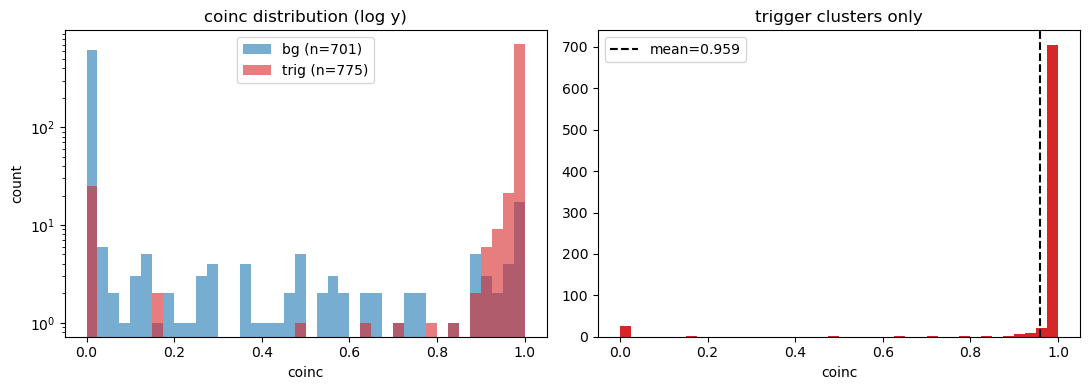

  trig coinc q01 = 0.000
  trig coinc q05 = 0.924
  trig coinc q10 = 0.981
  trig coinc q25 = 0.997
  trig coinc q50 = 0.999
  trig coinc q75 = 1.000
  trig coinc q90 = 1.000
  trig coinc q99 = 1.000
  trig with coinc < 0.1: 25  (3.2%)
  trig with coinc > 0.9: 741  (95.6%)
bad trigger clusters: 7 / 15

dt_corr_ns for bad trigger clusters:
tensor([2.5036e+05, 2.5036e+05, 2.5036e+05, 2.5022e+05, 2.5022e+05, 1.2795e+02,
        2.5012e+05], device='cuda:0')

dt_from_pos (ns) for same:
tensor([2.5036e+05, 2.5036e+05, 2.5036e+05, 2.5023e+05, 2.5022e+05, 1.2845e+02,
        2.5012e+05], device='cuda:0')

positron_time (ns) per graph:
tensor([ 3.6648e+02, -2.5000e+05,  9.6279e+01,  3.1094e+02,  2.0819e+02,
         2.5140e+02,  2.2476e+02,  4.1001e+02, -2.5000e+05, -2.5000e+05,
         3.9359e+02,  1.2665e+02], device='cuda:0')
  min, max: -250000.0 410.006591796875
  sentinel hits (|t|>400ns): 4

beta of bad clusters:
tensor([1.8386e-03, 4.5139e-04, 3.8881e-04, 3.2408e-04, 2.5054e-04, 1.000

In [9]:
# Train a Linear(10,1) on the full per-cluster feature vector (direct BCE against
# cluster trigger fraction) to see which of the 10 features carry signal.

# --- choose which features to probe ---
FEATURE_NAMES_ALL = ['sin_theta','cos_theta','sin_phi','cos_phi',
                     'cos_sep_pos','cos_sep_exit','energy_mean',
                     'coinc','beta','soft_n_hits']
USE_IDX = [4, 7]                                    # e.g. cos_sep_pos + coinc
FEATURE_NAMES = [FEATURE_NAMES_ALL[i] for i in USE_IDX]
D_FEAT = len(USE_IDX)


model.eval()
all_feats = []
all_targets = []

with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if i >= 50:
            break
        batch = batch.to(device)
        outputs = model(batch.x, batch.batch, task_weights=task_weights)

        feats_flat   = outputs.get('lyso_cluster_features')   # [Total_K, 10]
        assignments  = outputs.get('lyso_soft_assignments')
        seed_beta    = outputs.get('lyso_seed_beta')
        if feats_flat is None or assignments is None:
            continue

        K = assignments.size(1)
        is_lyso      = (batch.x[:, 7] > 0.5)
        lyso_energy  = batch.x[is_lyso, 3]
        lyso_targets = batch.is_trigger_target[is_lyso]
        lyso_batch   = batch.batch[is_lyso]
        num_graphs   = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)

        graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=lyso_batch.device)
        graph_has_lyso[lyso_batch] = True
        mapped       = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped  = mapped[lyso_batch]
        n_lyso       = graph_has_lyso.sum().item()

        # Effective weights for target computation
        eff_w = assignments
        if seed_beta is not None:
            beta_bc = seed_beta.view(-1, K)[lyso_mapped]
            eff_w = assignments * beta_bc

        w_energy  = eff_w * lyso_energy.unsqueeze(1)
        w_trigger = w_energy * lyso_targets.unsqueeze(1)
        cl_energy  = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_trigger = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_energy.index_add_(0, lyso_mapped, w_energy)
        cl_trigger.index_add_(0, lyso_mapped, w_trigger)
        cl_target = cl_trigger / cl_energy.clamp(min=1e-6)

        # Full 10-feature vector per cluster
        feats = feats_flat[:, USE_IDX].view(n_lyso, K, D_FEAT)


        valid = cl_energy > 1e-6
        all_feats.append(feats[valid].cpu())
        all_targets.append(cl_target[valid].cpu())

X = torch.cat(all_feats, dim=0)   # [N, 10]
Y = torch.cat(all_targets, dim=0) # [N]

print(f'Collected {X.size(0)} clusters')
print(f'Trigger (target > 0.5): {(Y > 0.5).sum().item()}')
print(f'Background (target <= 0.5): {(Y <= 0.5).sum().item()}')

trig = Y > 0.5
bg = ~trig
print('\nPer-feature (trigger vs background) mean ± std:')
for j, name in enumerate(FEATURE_NAMES):
    print(f'  {name:13s}  trig: {X[trig,j].mean():+.3f} ± {X[trig,j].std():.3f}   '
          f'bg: {X[bg,j].mean():+.3f} ± {X[bg,j].std():.3f}')

# Standardize so weight magnitudes are directly comparable across features
mu  = X.mean(dim=0, keepdim=True)
std = X.std(dim=0, keepdim=True).clamp(min=1e-6)
Xn  = (X - mu) / std
Yb  = (Y > 0.5).float()

#probe = nn.Linear(D_FEAT, 1)
probe = nn.Sequential(
    nn.Linear(D_FEAT, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

opt = torch.optim.Adam(probe.parameters(), lr=1e-3)

for epoch in range(400):
    opt.zero_grad()
    logits = probe(Xn).squeeze(-1)
    loss = F.binary_cross_entropy_with_logits(logits, Yb)
    loss.backward()
    opt.step()
    if epoch % 40 == 0:
        acc = ((logits > 0).float() == Yb).float().mean()
        print(f'Epoch {epoch:3d}: loss={loss.item():.4f}, acc={acc.item():.4f}')

import matplotlib.pyplot as plt

coinc_col = FEATURE_NAMES.index('coinc')  # or just 7
c_trig = X[trig, coinc_col].numpy()
c_bg   = X[bg,   coinc_col].numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(c_bg,   bins=40, range=(0, 1), alpha=0.6, label=f'bg (n={len(c_bg)})',   color='C0')
ax[0].hist(c_trig, bins=40, range=(0, 1), alpha=0.6, label=f'trig (n={len(c_trig)})', color='C3')
ax[0].set_xlabel('coinc')
ax[0].set_ylabel('count')
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title('coinc distribution (log y)')

# Zoom on trigger clusters to see the low-coinc tail
ax[1].hist(c_trig, bins=40, range=(0, 1), color='C3')
ax[1].axvline(c_trig.mean(), color='k', ls='--', label=f'mean={c_trig.mean():.3f}')
ax[1].set_xlabel('coinc')
ax[1].set_title('trigger clusters only')
ax[1].legend()

plt.tight_layout(); plt.show()

# quantiles to make the tail concrete
import numpy as np
for q in [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]:
    print(f'  trig coinc q{int(q*100):02d} = {np.quantile(c_trig, q):.3f}')
print(f'  trig with coinc < 0.1: {(c_trig < 0.1).sum()}  ({(c_trig < 0.1).mean()*100:.1f}%)')
print(f'  trig with coinc > 0.9: {(c_trig > 0.9).sum()}  ({(c_trig > 0.9).mean()*100:.1f}%)')

with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=task_weights)

coinc       = out['lyso_coinc_feat']                    # [Total_K]
dt_corr_ns  = out['lyso_dt_corr_ns'].view(-1)           # [Total_K]
dt_from_pos = out['lyso_dt_from_pos'].view(-1) * 500    # ns
pt          = out['positron_time_per_graph'] * 500      # ns per graph
assignments = out['lyso_soft_assignments']
seed_beta   = out['lyso_seed_beta']

# rebuild cl_target as in the probe
...  # same block you already have
valid = cl_energy > 1e-6
target_flat = cl_target[valid]

# Focus on TRIGGER clusters with coinc < 0.5
bad = (target_flat > 0.5) & (coinc[valid.view(-1)] < 0.5)
print(f'bad trigger clusters: {bad.sum().item()} / {(target_flat > 0.5).sum().item()}')

print('\ndt_corr_ns for bad trigger clusters:')
print(dt_corr_ns[valid.view(-1)][bad][:20])
print('\ndt_from_pos (ns) for same:')
print(dt_from_pos[valid.view(-1)][bad][:20])
print('\npositron_time (ns) per graph:')
print(pt)
print('  min, max:', pt.min().item(), pt.max().item())
print('  sentinel hits (|t|>400ns):', (pt.abs() > 400).sum().item())
print('\nbeta of bad clusters:')
print(seed_beta[valid.view(-1)][bad][:20])

# pt is [B]; has_lyso selects the n_lyso graphs; cl_* are [n_lyso, K]
# Build graph_idx per cluster in the [n_lyso, K] layout, then mask with `valid`
pt_lyso = pt[graph_has_lyso]                                  # [n_lyso] ns
graph_idx_kl = torch.arange(n_lyso, device=pt.device).unsqueeze(1).expand(n_lyso, K)  # [n_lyso, K]

pt_valid_kl = pt_lyso.abs() < 400                              # [n_lyso]
event_ok_kl = pt_valid_kl[graph_idx_kl]                        # [n_lyso, K]
event_ok    = event_ok_kl[valid]                               # [num_valid_clusters]

beta_kl     = seed_beta.view(n_lyso, K)                        # [n_lyso, K]
beta_ok     = (beta_kl[valid] > 0.1)                           # [num_valid_clusters]

bad_clean = bad & event_ok & beta_ok
print(f'bad trigger clusters after filters: {bad_clean.sum().item()} / {(target_flat > 0.5).sum().item()}')

'''
w = probe.weight.detach().cpu().numpy().ravel()
b = probe.bias.item()
print('\nStandardized weights (|w| ranks feature importance):')
order = sorted(range(D_FEAT), key=lambda j: -abs(w[j]))
for j in order:
    print(f'  {FEATURE_NAMES[j]:13s}  w = {w[j]:+.3f}')
print(f'  bias                  = {b:+.3f}')
'''

preds = (probe(Xn).squeeze(-1) > 0).float()
tp = ((preds == 1) & (Yb == 1)).sum().item()
fp = ((preds == 1) & (Yb == 0)).sum().item()
fn = ((preds == 0) & (Yb == 1)).sum().item()
tn = ((preds == 0) & (Yb == 0)).sum().item()
print(f'\nTP={tp}, FP={fp}, FN={fn}, TN={tn}')
print(f'Precision={tp/max(tp+fp,1):.3f}, Recall={tp/max(tp+fn,1):.3f}')

# Optional: per-feature solo accuracy (which feature is useful ALONE)
print('\nSolo-feature probe accuracy (each feature in isolation):')
for j, name in enumerate(FEATURE_NAMES):
    p1 = nn.Linear(1, 1)
    o1 = torch.optim.Adam(p1.parameters(), lr=1e-2)
    xj = Xn[:, j:j+1]
    for _ in range(200):
        o1.zero_grad()
        l = F.binary_cross_entropy_with_logits(p1(xj).squeeze(-1), Yb)
        l.backward(); o1.step()
    acc = ((p1(xj).squeeze(-1) > 0).float() == Yb).float().mean().item()
    print(f'  {name:13s}  acc = {acc:.3f}')


In [25]:
# ============================================================================
# Bad trigger cluster root-cause diagnostic
# Splits failures into:
#   A) sentinel pt  -> ATAR gate produced nothing; find which head vetoed
#   B) valid pt but wrong hit -> gate locked onto wrong ATAR hit; find it
# ============================================================================
import torch

NORM_T = 500.0
SIGMA_NS = 2.0
TOF_NS = 0.5
PURITY_CUT = 0.5
DT_OK_NS = 5.0  # "good" trigger clusters are within this of pt

model.eval()
tw = {'w_atar_trigger_slice': 1.0, 'w_pion_kinematics': 1.0,
      'w_event_builder': 1.0, 'w_positron_angle': 1.0}
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=tw)

lyso_assign  = out['lyso_soft_assignments']            # [N_lyso, K]
seed_beta    = out['lyso_seed_beta']                   # flat [G_lyso * K]
pt_vec       = out['positron_time_per_graph']          # [G]  (normalized)
trig_p_hit   = out['atar_hit_trigger_prob']            # [N_atar]
mip_p_hit    = out['atar_hit_mip_prob']                # [N_atar]

out_dt = out['lyso_dt_corr_ns'].view(-1)         # model's value [Total_K] ns
# per-graph cluster index: has_lyso=True graphs × K_LYSO each
# Pick g=0 k=0 (index depends on layout — use model output directly)
#for flat_idx in range(out_dt.shape[0]):
#    print(f"flat_k={flat_idx}  model_dt_corr={out_dt[flat_idx].item():+.2f} ns")


# modality masks (adjust column indices if different in your schema)
is_lyso = batch.x[:, 7] > 0.5
is_atar = ~is_lyso

t_raw    = batch.x[:, 4] * NORM_T                     # ns
trg_tgt  = batch.is_trigger_target.float()

lyso_hit_t   = t_raw[is_lyso]
lyso_hit_g   = batch.batch[is_lyso]
lyso_hit_tgt = trg_tgt[is_lyso]

# reshape assignments to flat [N_lyso, K] if padded
if lyso_assign.dim() == 3:
    G, Kmax, _ = lyso_assign.shape
    # recover flat view via batch.batch — simpler: use max purity per cluster
    raise RuntimeError("Adapt unpacking: lyso_assign is padded; use your existing flatten")

N_lyso, K = lyso_assign.shape

# ---- per-cluster (graph, k) summary ----
# purity = Σ_i w_ik * trg_i / Σ_i w_ik
w = lyso_assign
w_sum = w.sum(dim=0).clamp(min=1e-6)  # NOT what we want — need per-graph
# Build per-graph per-k by indexing
G = int(batch.batch.max().item()) + 1
has_lyso = (batch.batch.bincount(minlength=G) > 0)  # approximate, adjust if needed
clusters = []   # list of (g, k, purity, dt_corr_ns, gate_count, pt_ns)
for g in range(G):
    hit_mask_g = (lyso_hit_g == g)
    if hit_mask_g.sum() == 0:
        continue
    w_g = w[hit_mask_g]                    # [n_g_lyso, K]
    t_g = lyso_hit_t[hit_mask_g]
    tgt_g = lyso_hit_tgt[hit_mask_g]
    denom = w_g.sum(dim=0).clamp(min=1e-6) # [K]
    purity = (w_g * tgt_g.unsqueeze(1)).sum(dim=0) / denom  # [K]
    # weighted cluster time
    t_clu = (w_g * t_g.unsqueeze(1)).sum(dim=0) / denom     # [K]
    pt = pt_vec[g].item() * NORM_T
    dt_corr = t_clu - pt - TOF_NS
    # gate count in this graph
    atar_mask_g = (batch.batch == g) & is_atar
    trig_g = trig_p_hit[atar_mask_g[is_atar]] if trig_p_hit.shape[0] == is_atar.sum() else trig_p_hit[batch.batch[is_atar] == g]
    mip_g  = mip_p_hit [atar_mask_g[is_atar]] if mip_p_hit .shape[0] == is_atar.sum() else mip_p_hit [batch.batch[is_atar] == g]
    gate_pass = (trig_g > 0.5) & (mip_g > 0.5)
    for k in range(K):
        clusters.append(dict(
            g=g, k=k,
            purity=purity[k].item(),
            dt_corr_ns=dt_corr[k].item(),
            t_clu_ns=t_clu[k].item(),
            pt_ns=pt,
            gate_count=int(gate_pass.sum().item()),
            trig_g=trig_g, mip_g=mip_g,
            atar_t_ns=t_raw[(batch.batch == g) & is_atar],
        ))

bad = [c for c in clusters
       if c['purity'] > PURITY_CUT and abs(c['dt_corr_ns']) > DT_OK_NS]

print(f"Bad trigger clusters (purity>{PURITY_CUT}, |dt|>{DT_OK_NS}ns): {len(bad)}\n")

for c in bad:
    g = c['g']; k = c['k']
    print(f"=== g={g} k={k} ===  pt={c['pt_ns']:.1f}ns  t_clu={c['t_clu_ns']:.1f}ns  dt={c['dt_corr_ns']:.1f}ns")

    # LYSO hits for this graph (order matches lyso_soft_assignments rows for this graph)
    lyso_mask_g = (batch.batch == g) & is_lyso
    lyso_x_g = batch.x[lyso_mask_g]
    t_ns_g   = lyso_x_g[:, 4] * 500.0
    E_g      = lyso_x_g[:, 3]
    slice_g  = lyso_x_g[:, 8].long()

    # Rows of w corresponding to this graph's LYSO hits
    lyso_rows_g = (batch.batch[is_lyso] == g)
    w_g = w[lyso_rows_g]          # [n_g, K]
    w_gk = w_g[:, k]

    order = torch.argsort(w_gk, descending=True)[:12]
    print(f"  {'w':>6}  {'t(ns)':>8}  {'E':>8}  slice")
    for i in order.tolist():
        print(f"  {w_gk[i].item():>6.3f}  {t_ns_g[i].item():>8.1f}  {E_g[i].item():>8.4f}  {slice_g[i].item()}")
    print(f"  unique slice_ids in cluster (w>0.05): "
          f"{slice_g[w_gk > 0.05].unique().tolist()}")




Bad trigger clusters (purity>0.5, |dt|>5.0ns): 0



In [40]:
import torch
from tqdm import tqdm

model.eval()
N_BATCHES = 50   # tune

n_events_total       = 0
n_has_trig_positron  = 0
n_sentinel           = 0
n_sentinel_with_trig = 0   # sentinel events that DO have a trigger positron

# Failure-mode breakdown on sentinel+hastrig events:
#   hist buckets = counts of hits satisfying different (trig_p, mip_p) thresholds
n_trig_only_pass = 0    # trig_p>0.5 but mip_p<=0.5   → MIP head is the veto
n_mip_only_pass  = 0    # mip_p>0.5 but trig_p<=0.5   → trigger head is the veto
n_neither_pass   = 0    # both <0.5 everywhere         → both heads missed

# Record max trig_p and max mip_p per sentinel event
max_trig_list = []
max_mip_list  = []

with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, total=N_BATCHES)):
        if i >= N_BATCHES: break
        batch = batch.to(device)
        out = model(batch.x, batch.batch, task_weights=tw)

        pt_vec   = out['positron_time_per_graph']          # [G]
        trig_p   = out['atar_hit_trigger_prob']            # [N_atar]
        mip_p    = out['atar_hit_mip_prob']                # [N_atar]
        is_atar  = batch.x[:, 7] < 0.5
        atar_g   = batch.batch[is_atar]

        has_pos  = batch.has_trigger_positron.bool() if hasattr(batch, 'has_trigger_positron') \
                   else torch.ones_like(pt_vec, dtype=torch.bool)   # fallback: assume all

        G = pt_vec.numel()
        sentinel = pt_vec < -0.9

        n_events_total      += G
        n_has_trig_positron += has_pos.sum().item()
        n_sentinel          += sentinel.sum().item()
        bad = sentinel & has_pos
        n_sentinel_with_trig += bad.sum().item()

        for g in bad.nonzero().squeeze(-1).tolist():
            m = (atar_g == g)
            tp = trig_p[m]; mp = mip_p[m]
            max_trig_list.append(tp.max().item())
            max_mip_list.append(mp.max().item())
            n_trig_only_pass += ((tp > 0.5) & (mp <= 0.5)).sum().item()
            n_mip_only_pass  += ((tp <= 0.5) & (mp > 0.5)).sum().item()
            n_neither_pass   += ((tp <= 0.5) & (mp <= 0.5)).sum().item()

print(f"\n--- Rate (1) ---")
print(f"events scanned:                     {n_events_total}")
print(f"events w/ true trigger positron:    {n_has_trig_positron}")
print(f"sentinel events:                    {n_sentinel}  "
      f"({100*n_sentinel/n_events_total:.2f}%)")
print(f"sentinel AND has_trigger_positron:  {n_sentinel_with_trig}  "
      f"({100*n_sentinel_with_trig/max(1,n_has_trig_positron):.2f}% of trig events)")

print(f"\n--- Failure mode (2): over {n_sentinel_with_trig} sentinel trig events ---")
print(f"  hits with trig_p>0.5 only (MIP veto):     {n_trig_only_pass}")
print(f"  hits with mip_p>0.5 only (trigger veto):  {n_mip_only_pass}")
print(f"  hits with neither (both heads missed):    {n_neither_pass}")

import numpy as np
mt = np.array(max_trig_list); mm = np.array(max_mip_list)
if len(mt):
    print(f"\nper-event max trig_p: mean={mt.mean():.3f}  median={np.median(mt):.3f}  "
          f"# with max<0.5: {(mt<0.5).sum()}")
    print(f"per-event max mip_p : mean={mm.mean():.3f}  median={np.median(mm):.3f}  "
          f"# with max<0.5: {(mm<0.5).sum()}")


100%|██████████| 50/50 [00:07<00:00,  6.59it/s]


--- Rate (1) ---
events scanned:                     600
events w/ true trigger positron:    506
sentinel events:                    90  (15.00%)
sentinel AND has_trigger_positron:  1  (0.20% of trig events)

--- Failure mode (2): over 1 sentinel trig events ---
  hits with trig_p>0.5 only (MIP veto):     36
  hits with mip_p>0.5 only (trigger veto):  113
  hits with neither (both heads missed):    0

per-event max trig_p: mean=1.000  median=1.000  # with max<0.5: 0
per-event max mip_p : mean=1.000  median=1.000  # with max<0.5: 0


In [38]:
import torch
NORM_T = 500.0

model.eval()
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=tw)

is_lyso = batch.x[:, 7] > 0.5
w       = out['lyso_soft_assignments']          # [N_lyso, K]
coinc   = out['lyso_coinc_feat'].view(-1)       # [Total_K]
pt_vec  = out['positron_time_per_graph']        # [G]
trg_tgt = batch.is_trigger_target.float()

lyso_hit_g   = batch.batch[is_lyso]
lyso_hit_tgt = trg_tgt[is_lyso]

# Per-graph per-k: purity = Σ w·tgt / Σ w
G = int(batch.batch.max().item()) + 1
K = w.shape[1]
purity_list, graph_list = [], []
for g in range(G):
    m = (lyso_hit_g == g)
    if m.sum() == 0:
        purity_list.append(torch.zeros(K, device=w.device))
    else:
        w_g   = w[m]
        tgt_g = lyso_hit_tgt[m]
        denom = w_g.sum(0).clamp(min=1e-6)
        purity_list.append((w_g * tgt_g.unsqueeze(1)).sum(0) / denom)
    graph_list.append(torch.full((K,), g, device=w.device))

purity_flat        = torch.cat(purity_list)                # [G*K]
cluster_graph_idx  = torch.cat(graph_list).long()          # [G*K]

# Coinc may only cover has_lyso graphs — align lengths
n = min(purity_flat.numel(), coinc.numel())
purity_flat       = purity_flat[:n]
coinc             = coinc[:n]
cluster_graph_idx = cluster_graph_idx[:n]

zero_coinc_mask = (coinc < 0.01) & (purity_flat > 0.5)
print(f"zero-coinc trigger clusters: {zero_coinc_mask.sum().item()}")
print("pt (normalized) for their graphs:",
      pt_vec[cluster_graph_idx[zero_coinc_mask]].unique())


zero-coinc trigger clusters: 3
pt (normalized) for their graphs: tensor([-500.], device='cuda:0')


In [19]:
g = 3
lyso_g = batch.x[(batch.batch==g) & is_lyso]   # [n, 10]
t_ns   = lyso_g[:, 4] * 500
slice_id = lyso_g[:, 8].long()
E = lyso_g[:, 3]
w = out['lyso_soft_assignments']  # flat [N_lyso, K]
# figure out which rows of w correspond to this graph's LYSO hits (order matches batch[is_lyso])
# then: w_k1 per hit, print t_ns/slice_id/E/w sorted by w desc


In [15]:
model.eval()
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    outputs = model(batch.x, batch.batch, task_weights=task_weights)

# rebuild ALL state from this forward
is_lyso = batch.x[:, 7] > 0.5
is_atar = ~is_lyso

x_lyso  = batch.x[is_lyso]
lyso_batch  = batch.batch[is_lyso]
lyso_trig   = batch.is_trigger_target[is_lyso]

assignments = outputs['lyso_soft_assignments']           # [N_lyso, K]
seed_beta   = outputs['lyso_seed_beta']                  # [n_lyso * K] flat
coinc       = outputs['lyso_coinc_feat']                 # [n_lyso * K] flat
dt_corr_ns  = outputs['lyso_dt_corr_ns'].view(-1)
pt          = outputs['positron_time_per_graph'] * 500   # ns per graph
K           = assignments.size(1)

num_graphs = batch.batch.max().item() + 1
graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=batch.x.device)
graph_has_lyso[lyso_batch] = True
mapped = torch.cumsum(graph_has_lyso.long(), 0) - 1
lyso_mapped = mapped[lyso_batch]
n_lyso = graph_has_lyso.sum().item()

# rebuild cl_target and valid
eff_w = assignments * seed_beta.view(n_lyso, K)[lyso_mapped]
w_energy  = eff_w * x_lyso[:, 3].unsqueeze(1)
w_trigger = w_energy * lyso_trig.unsqueeze(1)
cl_energy  = torch.zeros(n_lyso, K, device=batch.x.device)
cl_trigger = torch.zeros(n_lyso, K, device=batch.x.device)
cl_energy.index_add_(0, lyso_mapped, w_energy)
cl_trigger.index_add_(0, lyso_mapped, w_trigger)
cl_target = cl_trigger / cl_energy.clamp(min=1e-6)

valid = cl_energy > 1e-6                                 # [n_lyso, K]
coinc_kl = coinc.view(n_lyso, K)
beta_kl  = seed_beta.view(n_lyso, K)
pt_ok_kl = (pt[graph_has_lyso].abs() < 400).unsqueeze(1).expand(n_lyso, K)

bad_kl = valid & (cl_target > 0.5) & (coinc_kl < 0.5) & (beta_kl > 0.1) & pt_ok_kl
print(f'bad trigger clusters (filtered): {bad_kl.sum().item()}')

# dump hits for bad clusters
for n_idx, k_idx in bad_kl.nonzero().tolist():
    g = graph_has_lyso.nonzero().squeeze(-1)[n_idx].item()
    hit_in_g = (lyso_batch == g)
    hit_rows = hit_in_g.nonzero().squeeze(-1)
    hit_t = x_lyso[hit_rows, 4].cpu().numpy() * 500
    hit_e = x_lyso[hit_rows, 3].cpu().numpy()
    hit_w = assignments[hit_rows, k_idx].cpu().numpy()
    hit_tf = lyso_trig[hit_rows].cpu().numpy()
    print(f'\nGraph {g}, cluster k={k_idx}   pt={pt[g].item():+.1f} ns   '
          f'β={beta_kl[n_idx,k_idx]:.3f}   coinc={coinc_kl[n_idx,k_idx]:.3f}   '
          f'dt_corr={dt_corr_ns.view(n_lyso,K)[n_idx,k_idx]:+.1f} ns')
    rows = sorted(zip(hit_t, hit_e, hit_w, hit_tf), key=lambda r: -r[2])[:10]
    print('  top-w hits (t_ns, E, w, trig):')
    for t, e, w, tf in rows:
        print(f'    t={t:+7.1f}  E={e:.3f}  w={w:.3f}  trig={int(tf)}')


bad trigger clusters (filtered): 1

Graph 2, cluster k=0   pt=+27.2 ns   β=1.000   coinc=0.048   dt_corr=+4.9 ns
  top-w hits (t_ns, E, w, trig):
    t=  +28.9  E=0.078  w=0.995  trig=1
    t=  +29.7  E=0.006  w=0.959  trig=1
    t= +137.4  E=0.007  w=0.092  trig=0
    t= +148.1  E=0.008  w=0.058  trig=0
    t=  +70.5  E=0.007  w=0.036  trig=0
    t= +186.1  E=0.007  w=0.033  trig=0
    t=  +11.0  E=0.010  w=0.031  trig=0
    t= +213.8  E=0.011  w=0.029  trig=0
    t=  +22.6  E=0.011  w=0.028  trig=0
    t=  +43.8  E=0.009  w=0.027  trig=0


In [35]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=task_weights)

is_atar = (batch.x[:, 7] < 0.5)
atar_batch = batch.batch[is_atar]
B = batch.batch.max().item() + 1

# Reconstruct both probs
# MIP prob: node PDG column 2
mip_prob = torch.sigmoid(out['atar_node_pdg'][:, 2])    # [N_atar]

# Slice trigger prob per atar hit — need to map slice → hit
# Easiest path: export hit_trigger_prob_t from the model. If not exported,
# compute the product we actually care about: conjunction gate strength.
# Quickest: look at mip_prob alone first.

# Per-event max MIP prob
max_mip_per_ev = torch.full((B,), -1.0, device=batch.x.device)
max_mip_per_ev = max_mip_per_ev.scatter_reduce(0, atar_batch, mip_prob, reduce='amax', include_self=True)
print('per-event max MIP prob distribution:')
print('  min', max_mip_per_ev.min().item(), 'median', max_mip_per_ev.median().item(),
      'max', max_mip_per_ev.max().item())
print('  events with max_mip < 0.5:', (max_mip_per_ev < 0.5).sum().item(), '/', B)

# Also check which events got sentinel pt
pt = out['positron_time_per_graph']
sentinel = pt.abs() > 400 / 500
print(f'sentinel events: {sentinel.sum().item()} / {B}')
print(f'sentinel events with max_mip > 0.5:', (sentinel & (max_mip_per_ev > 0.5)).sum().item(),
      '← these are cases where MIP head fired but trigger-slice head did NOT')


per-event max MIP prob distribution:
  min 0.00023554936342407018 median 0.999997615814209 max 0.9999992847442627
  events with max_mip < 0.5: 2 / 12
sentinel events: 5 / 12
sentinel events with max_mip > 0.5: 3 ← these are cases where MIP head fired but trigger-slice head did NOT


In [8]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=task_weights)

is_atar   = (batch.x[:, 7] < 0.5)
atar_bat  = batch.batch[is_atar]
B         = batch.batch.max().item() + 1

# reconstruct the two per-hit probs the same way the model does
# (grab them from the model internals or recompute)
mip_p   = torch.sigmoid(out['atar_node_pdg'][:, 2]).detach()      # [N_atar]
# hit_trigger_prob_t is internal — easiest: export it from models.py,
# OR recompute here if you can mirror the slice_idx mapping.
# Assume you add: output['atar_hit_trigger_prob'] = hit_trigger_prob_t
hit_trig_p = out['atar_hit_trigger_prob']                          # [N_atar]

pt = out['positron_time_per_graph']
sentinel_events = (pt.abs() > 400/500).nonzero().squeeze(-1).tolist()

for g in sentinel_events:
    m = (atar_bat == g)
    trg = hit_trig_p[m]
    mip = mip_p[m]
    print(f'\nevent {g}  (sentinel)')
    print(f'  hits in event: {m.sum().item()}')
    print(f'  hits with trigger_prob > 0.5:     {(trg > 0.5).sum().item()}')
    print(f'  hits with mip_prob > 0.5:          {(mip > 0.5).sum().item()}')
    print(f'  hits with BOTH > 0.5 (gate pass):  {((trg > 0.5) & (mip > 0.5)).sum().item()}')
    print(f'  max(trig*mip) on any hit:          {(trg*mip).max().item():.3f}')
    atar_mask = is_atar & (batch.batch == g)
    is_lyso   = (batch.x[:, 7] > 0.5)
    lyso_mask = is_lyso & (batch.batch == g)

    n_atar        = atar_mask.sum().item()
    n_lyso        = lyso_mask.sum().item()
    n_trig_lyso   = batch.is_trigger_target[lyso_mask].sum().item()
    # if your batch also has ATAR-level positron/MIP ground truth, print it too:
    # n_mip_true_atar = batch.atar_pdg_target[atar_mask, 2].sum().item()
    print(f'event {g}: n_atar={n_atar}  n_lyso={n_lyso}  '
          f'n_trig_in_lyso={int(n_trig_lyso)}')




event 1  (sentinel)
  hits in event: 52
  hits with trigger_prob > 0.5:     52
  hits with mip_prob > 0.5:          20
  hits with BOTH > 0.5 (gate pass):  20
  max(trig*mip) on any hit:          1.000
event 1: n_atar=52  n_lyso=28  n_trig_in_lyso=7

event 10  (sentinel)
  hits in event: 89
  hits with trigger_prob > 0.5:     36
  hits with mip_prob > 0.5:          17
  hits with BOTH > 0.5 (gate pass):  0
  max(trig*mip) on any hit:          0.135
event 10: n_atar=89  n_lyso=20  n_trig_in_lyso=0


In [9]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=task_weights)

is_atar   = (batch.x[:, 7] < 0.5)
atar_bat  = batch.batch[is_atar]
B         = batch.batch.max().item() + 1

trg = out['atar_hit_trigger_prob']                     # [N_atar]
mip = out['atar_hit_mip_prob']                         # [N_atar]
t   = batch.x[is_atar, 4]                              # [N_atar] normalized time
pt_model = out['positron_time_per_graph']              # [B] what the model produced

# Recompute the same way the model should:
mask = ((trg > 0.5) & (mip > 0.5)).float()
t_num = torch.zeros(B, device=batch.x.device)
t_den = torch.zeros(B, device=batch.x.device)
t_num.index_add_(0, atar_bat, t * mask)
t_den.index_add_(0, atar_bat, mask)
pt_recomp = torch.where(
    t_den > 0.5,
    t_num / t_den.clamp(min=1.0),
    torch.full_like(t_num, -500.0),
)

# Compare
for g in range(B):
    diff = (pt_model[g] - pt_recomp[g]).abs().item()
    flag = '  <-- MISMATCH' if diff > 1e-4 else ''
    print(f'event {g}: pt_model={pt_model[g].item():+.3f}  '
          f'pt_recomp={pt_recomp[g].item():+.3f}  '
          f'gate_count={int(t_den[g].item())}{flag}')


event 0: pt_model=+0.254  pt_recomp=+0.254  gate_count=11
event 1: pt_model=-500.000  pt_recomp=-500.000  gate_count=0
event 2: pt_model=+0.416  pt_recomp=+0.416  gate_count=16
event 3: pt_model=+0.827  pt_recomp=+0.827  gate_count=45
event 4: pt_model=+0.865  pt_recomp=+0.865  gate_count=38
event 5: pt_model=+0.856  pt_recomp=+0.856  gate_count=36
event 6: pt_model=+0.364  pt_recomp=+0.364  gate_count=66
event 7: pt_model=-500.000  pt_recomp=-500.000  gate_count=0
event 8: pt_model=+0.209  pt_recomp=+0.209  gate_count=69
event 9: pt_model=+0.996  pt_recomp=+0.996  gate_count=32
event 10: pt_model=+0.837  pt_recomp=+0.837  gate_count=39
event 11: pt_model=+0.521  pt_recomp=+0.521  gate_count=16


In [11]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    out = model(batch.x, batch.batch, task_weights=task_weights)

is_atar   = (batch.x[:, 7] < 0.5)
atar_bat  = batch.batch[is_atar]
B         = batch.batch.max().item() + 1

trg = out['atar_hit_trigger_prob']
mip = out['atar_hit_mip_prob']
pt  = out['positron_time_per_graph']

# gate-pass count per event
mask = ((trg > 0.5) & (mip > 0.5)).float()
gate_count = torch.zeros(B, device=batch.x.device)
gate_count.index_add_(0, atar_bat, mask)

sentinel = pt < -0.9   # only flags true NO_POSITRON_TIME = -500 normalized
lyso_trig = torch.zeros(B, device=batch.x.device)
lyso_mask = (batch.x[:, 7] > 0.5)
lyso_trig.index_add_(0, batch.batch[lyso_mask], batch.is_trigger_target[lyso_mask].float())

for g in range(B):
    flag = ''
    if sentinel[g] and gate_count[g] > 0:
        flag = '  ← BUG: sentinel despite gate passes'
    if sentinel[g] and lyso_trig[g] > 0:
        flag += '  ← contradiction: sentinel but LYSO has trigger hits'
    print(f'g={g:2d}  gate_count={int(gate_count[g]):3d}  '
          f'pt={pt[g].item():+8.3f}  n_trig_lyso={int(lyso_trig[g])}{flag}')


g= 0  gate_count= 32  pt=  +0.312  n_trig_lyso=0
g= 1  gate_count= 20  pt=  +0.124  n_trig_lyso=5
g= 2  gate_count= 18  pt=  +0.715  n_trig_lyso=4
g= 3  gate_count=  0  pt=-500.000  n_trig_lyso=0
g= 4  gate_count= 27  pt=  +0.057  n_trig_lyso=7
g= 5  gate_count= 33  pt=  +0.015  n_trig_lyso=2
g= 6  gate_count= 28  pt=  +0.622  n_trig_lyso=4
g= 7  gate_count= 35  pt=  +0.993  n_trig_lyso=0
g= 8  gate_count= 28  pt=  +0.286  n_trig_lyso=5
g= 9  gate_count= 46  pt=  +0.867  n_trig_lyso=4
g=10  gate_count= 28  pt=  +0.056  n_trig_lyso=2
g=11  gate_count=  1  pt=  +0.466  n_trig_lyso=5


In [11]:
model.eval()
all_targets = []
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if i >= 20:
            break
        batch = batch.to(device)
        outputs = model(batch.x, batch.batch, task_weights=task_weights)
        
        assignments = outputs.get('lyso_soft_assignments')
        seed_beta = outputs.get('lyso_seed_beta')
        if assignments is None:
            continue
        K = assignments.size(1)
        is_lyso = (batch.x[:, 7] > 0.5)
        lyso_energy = batch.x[is_lyso, 3]
        lyso_targets = batch.is_trigger_target[is_lyso]
        lyso_batch = batch.batch[is_lyso]
        num_graphs = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
        
        graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=batch.x.device)
        graph_has_lyso[lyso_batch] = True
        mapped = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped = mapped[lyso_batch]
        n_lyso = graph_has_lyso.sum().item()
        
        eff_w = assignments
        if seed_beta is not None:
            eff_w = assignments * seed_beta.view(-1, K)[lyso_mapped]
        
        w_energy = eff_w * lyso_energy.unsqueeze(1)
        w_trigger = w_energy * lyso_targets.unsqueeze(1)
        cl_energy = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_trigger = torch.zeros(n_lyso, K, device=batch.x.device)
        cl_energy.index_add_(0, lyso_mapped, w_energy)
        cl_trigger.index_add_(0, lyso_mapped, w_trigger)
        cl_target = cl_trigger / cl_energy.clamp(min=1e-6)
        valid = cl_energy > 1e-6
        all_targets.append(cl_target[valid].cpu())

T = torch.cat(all_targets)
print(f"Total clusters: {len(T)}")
print(f"Target = 0.0 (pure bg):      {(T < 0.01).sum().item()}")
print(f"Target 0.01-0.49 (mostly bg): {((T >= 0.01) & (T < 0.5)).sum().item()}")
print(f"Target 0.50-0.99 (mostly trig): {((T >= 0.5) & (T < 0.99)).sum().item()}")
print(f"Target > 0.99 (pure trigger):  {(T >= 0.99).sum().item()}")
print(f"\nHistogram:")
for lo in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    hi = lo + 0.1
    count = ((T >= lo) & (T < hi)).sum().item()
    print(f"  [{lo:.1f}, {hi:.1f}): {count}")


Total clusters: 909
Target = 0.0 (pure bg):      359
Target 0.01-0.49 (mostly bg): 186
Target 0.50-0.99 (mostly trig): 163
Target > 0.99 (pure trigger):  201

Histogram:
  [0.0, 0.1): 479
  [0.1, 0.2): 22
  [0.2, 0.3): 17
  [0.3, 0.4): 16
  [0.4, 0.5): 11
  [0.5, 0.6): 9
  [0.6, 0.7): 10
  [0.7, 0.8): 15
  [0.8, 0.9): 18
  [0.9, 1.0): 312


In [40]:
model.eval()
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    outputs = model(batch.x, batch.batch, task_weights=task_weights)
    
    # Check the magnitude of transformer output vs physics features
    n_atar = outputs.get('unified_num_atar_tokens', 0)
    logits = outputs['unified_event_logits'].squeeze(-1)
    lyso_logits = logits[n_atar:]
    
    w = model.event_head.weight.data[0]
    print(f"event_head weight magnitudes:")
    print(f"  transformer dims (0-31): mean={w[:32].abs().mean():.4f}, max={w[:32].abs().max():.4f}")
    print(f"  coinc_feat (32):         {w[32].item():.4f}")
    print(f"  cos_sep (33):            {w[33].item():.4f}")
    print(f"  bias:                    {model.event_head.bias.data[0].item():.4f}")
    print(f"\nLYSO logit range: [{lyso_logits.min():.3f}, {lyso_logits.max():.3f}], mean={lyso_logits.mean():.3f}")

# Hook to capture the input to event_head
model.eval()
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    outputs = model(batch.x, batch.batch, task_weights=task_weights)
    
    # Reconstruct what event_head sees
    n_atar = outputs.get('unified_num_atar_tokens', 0)
    # Re-run the classifier path to get the concatenated input
    # (we need the flat_transformed before it goes into event_head)
    
    skip_in = outputs.get('lyso_coinc_skip_input')  # [Total_K, 2]
    if skip_in is not None:
        print(f"Physics features going into event_head:")
        print(f"  coinc_feat:  mean={skip_in[:,0].mean():.3f}, std={skip_in[:,0].std():.3f}")
        print(f"  cos_sep:     mean={skip_in[:,1].mean():.3f}, std={skip_in[:,1].std():.3f}")
    
    # Check the transformer output magnitude by looking at logits
    # logit = W @ [transformer_out; phys_feat] + b
    # If transformer_out has magnitude >> phys_feat, it dominates
    logits = outputs['unified_event_logits'].squeeze(-1)[n_atar:]
    print(f"\nLYSO logits: mean={logits.mean():.3f}, std={logits.std():.3f}")
    print(f"  range: [{logits.min():.3f}, {logits.max():.3f}]")



event_head weight magnitudes:
  transformer dims (0-31): mean=0.1480, max=0.4788
  coinc_feat (32):         1.1327
  cos_sep (33):            0.6582
  bias:                    -0.1146

LYSO logit range: [-4.665, 5.037], mean=0.115
Physics features going into event_head:
  coinc_feat:  mean=0.488, std=0.485
  cos_sep:     mean=0.481, std=0.581

LYSO logits: mean=0.454, std=3.381
  range: [-4.738, 4.983]


In [19]:
def plot_event_builder_confusion(loader, model_obj, event_idx=0, trigger_threshold=0.5):
    """
    LYSO event display colored by TP/FP/TN/FN for event builder trigger classification.
    Uses assignment-weighted mixture probability per hit (matching the loss function).

    Takes the real training/eval `loader` and uses `_find_event_batch` to locate
    the event INSIDE its real multi-event batch, so indexing matches
    classifier_deep_dive and the model sees its normal batched context.
    """
    model_obj.eval()
    device = next(model_obj.parameters()).device

    batch, local_idx = _find_event_batch(loader, event_idx, device)

    with torch.no_grad():
        outputs = model_obj(
            batch.x, batch.batch,
            task_weights={'w_lyso_condensation': 1.0, 'w_event_builder': 1.0})

    # --- Filter LYSO hits for THIS event only ---
    event_hit_mask = (batch.batch == local_idx)
    is_lyso_all = (batch.x[:, 7] > 0.5)
    hits = (event_hit_mask & is_lyso_all).cpu()
    if not hits.any():
        print(f"No LYSO hits in event {event_idx}")
        return

    x_orig = batch.x[hits, 0].cpu().numpy() * 100.0
    y_orig = batch.x[hits, 1].cpu().numpy() * 100.0
    z_orig = batch.x[hits, 2].cpu().numpy() * 100.0
    energy = batch.x[hits, 3].cpu().numpy() * 70.0
    times  = batch.x[hits, 4].cpu().numpy() * 500.0

    r = np.sqrt(x_orig**2 + y_orig**2 + z_orig**2)
    theta = np.arccos(np.clip(z_orig / r, -1.0, 1.0))
    phi = np.arctan2(y_orig, x_orig)
    proj_x = theta * np.sin(phi)
    proj_y = theta * np.cos(phi)
    marker_sizes = np.maximum(energy * 50.0, 5.0)

    targets = batch.is_trigger_target[hits].cpu().numpy()

    n_lyso = int(hits.sum())
    n_trig = int((targets > 0.5).sum())
    print(f"n_lyso={n_lyso}, n_trigger_labeled={n_trig}")
    print(f"E range: {energy.min():.2f} - {energy.max():.2f} MeV, total E = {energy.sum():.2f}")
    print(f"t range: {times.min():.2f} - {times.max():.2f} ns")

    has_trig_pos = getattr(batch, 'has_trigger_positron', None)
    if has_trig_pos is not None:
        print(f"has_trigger_positron: {has_trig_pos[local_idx].item()}")

    big = energy > 3.0   # energy is already in MeV after the *70 rescale
    print(f"'big' hits (E>3 MeV): n={big.sum()}, targets={targets[big].tolist()}")


    # --- Predicted p_hit via assignment-weighted mixture (per-event slice) ---
    lyso_assignments = outputs.get('lyso_soft_assignments')   # [N_lyso_batch, K]
    event_logits     = outputs.get('unified_event_logits')
    num_atar_tokens  = outputs.get('unified_num_atar_tokens', 0)
    if lyso_assignments is None or event_logits is None:
        print("Model did not produce LYSO event builder outputs")
        return

    K = lyso_assignments.size(1)

    # Slice assignments to THIS event's LYSO hits.
    # lyso_assignments is aligned with batch.x[is_lyso_all] in original order.
    lyso_in_this_event = event_hit_mask[is_lyso_all]                 # [N_lyso_batch] bool
    event_assignments  = lyso_assignments[lyso_in_this_event].cpu()  # [n_hits_event, K]

    # LYSO tokens in event_logits are ordered by sorted unique LYSO-graph indices
    # (valid_b_indices = nonzero(has_lyso).squeeze() in the model).
    lyso_batch_idx_all = batch.batch[is_lyso_all]
    unique_lyso_graphs = torch.unique(lyso_batch_idx_all).sort().values
    match = (unique_lyso_graphs == local_idx).nonzero(as_tuple=False)
    if match.numel() == 0:
        print(f"Event {event_idx} has no LYSO graph in transformer output")
        return
    lyso_graph_idx = int(match.item())

    lyso_logits_all = event_logits.squeeze(-1).cpu()[num_atar_tokens:].view(-1, K)
    logits_k = lyso_logits_all[lyso_graph_idx]       # [K] logits for this event
    p_k      = torch.sigmoid(logits_k)               # [K] trigger prob per cluster

    effective_weights = event_assignments.clone()
    lyso_seed_beta = outputs.get('lyso_seed_beta')
    if lyso_seed_beta is not None:
        beta_matrix = lyso_seed_beta.cpu().view(-1, K)
        beta_k = beta_matrix[lyso_graph_idx]         # [K]
        effective_weights = effective_weights * beta_k.unsqueeze(0)
    else:
        beta_k = torch.zeros(K)

    w_sum = effective_weights.sum(dim=1).clamp(min=1e-6)
    p_hit = ((effective_weights * p_k.unsqueeze(0)).sum(dim=1) / w_sum).numpy()

    # After the model forward pass
    pt = outputs.get('positron_time_per_graph')
    if pt is not None:
        pt_val = pt[local_idx].item() * 500.0  # denormalize
        print(f"Positron time (from ATAR): {pt_val:.1f} ns")

    coinc = outputs.get('lyso_coinc_feat')
    dt_ns = outputs.get('lyso_dt_corr_ns')
    if coinc is not None:
        K = 5
        num_atar = outputs.get('unified_num_atar_tokens', 0)
        # Find which LYSO graph index this event maps to
        is_lyso_all = (batch.x[:, 7] > 0.5)
        lyso_batch = batch.batch[is_lyso_all]
        graph_has_lyso = torch.zeros(batch.batch.max().item()+1, dtype=torch.bool, device=batch.x.device)
        graph_has_lyso[lyso_batch] = True
        g_idx = torch.cumsum(graph_has_lyso.long(), dim=0)[local_idx] - 1
        
        c_k = coinc.view(-1, K)[g_idx].cpu().numpy()
        d_k = dt_ns.view(-1, K)[g_idx].cpu().numpy()
        print(f"Per-cluster coincidence window:")
        for k in range(K):
            print(f"  k={k}  coinc={c_k[k]:.4f}  dt_corr={d_k[k]:.1f}ns")


    # ============================================================
    # DIAGNOSTIC PRINTOUT
    # ============================================================
    print(f"\n========== Event {event_idx} (local {local_idx} in batch) ==========")

    assignments_np = event_assignments.numpy()
    print(f"\nPer-cluster summary (event {event_idx}):")
    print(f"{'k':>3} {'beta':>7} {'logit':>8} {'p_k':>7} "
          f"{'n_hits(w>0.1)':>14} {'n_trig_in_cluster':>18} {'trig_purity':>12}")
    for k in range(K):
        w_k = assignments_np[:, k]
        n_assigned = int((w_k > 0.1).sum())
        if w_k.sum() > 1e-6:
            trig_purity = float((w_k * targets).sum()) / float(w_k.sum())
        else:
            trig_purity = 0.0
        n_trig_assigned = int(((w_k > 0.1) & (targets == 1)).sum())
        print(f"{k:>3d} {beta_k[k].item():>7.3f} {logits_k[k].item():>+8.3f} "
              f"{p_k[k].item():>7.3f} {n_assigned:>14d} "
              f"{n_trig_assigned:>18d} {trig_purity:>12.3f}")

    purities = []
    for k in range(K):
        w_k = assignments_np[:, k]
        purities.append(float((w_k * targets).sum()) / float(w_k.sum()) if w_k.sum() > 1e-6 else 0.0)
    true_trig_cluster = int(np.argmax(purities))
    print(f"\nMost-trigger-aligned cluster: k={true_trig_cluster} "
          f"(purity={purities[true_trig_cluster]:.2f}, "
          f"logit={logits_k[true_trig_cluster].item():+.2f}, "
          f"p_k={p_k[true_trig_cluster].item():.3f})")

    trig_hit_mask = targets == 1
    if trig_hit_mask.any():
        w_trig = assignments_np[trig_hit_mask]
        print(f"\nTrue trigger hits ({trig_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={w_trig.max(axis=1).mean():.3f}  "
              f"min={w_trig.max(axis=1).min():.3f}  max={w_trig.max(axis=1).max():.3f}")
        print(f"  n clusters active (w>0.05):  mean={(w_trig > 0.05).sum(axis=1).mean():.2f}  "
              f"max={int((w_trig > 0.05).sum(axis=1).max())}")
        print(f"  total w_sum (1 - dustbin): mean={w_trig.sum(axis=1).mean():.3f}")
        print(f"  p_hit on trigger hits: mean={p_hit[trig_hit_mask].mean():.3f}  "
              f"max={p_hit[trig_hit_mask].max():.3f}")

    bg_hit_mask = targets == 0
    if bg_hit_mask.any():
        w_bg = assignments_np[bg_hit_mask]
        print(f"\nBackground hits ({bg_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={w_bg.max(axis=1).mean():.3f}")
        print(f"  n clusters active (w>0.05):  mean={(w_bg > 0.05).sum(axis=1).mean():.2f}")
        print(f"  total w_sum: mean={w_bg.sum(axis=1).mean():.3f}")
        print(f"  p_hit on bg hits: mean={p_hit[bg_hit_mask].mean():.3f}  "
              f"max={p_hit[bg_hit_mask].max():.3f}")

    print("=" * 50 + "\n")

    real_clusters = [k for k in range(K) if beta_k[k].item() > 0.5]
    if len(real_clusters) >= 2:
        print("\nReal cluster centers (energy-weighted):")
        for k in real_clusters:
            w_k = assignments_np[:, k]
            if w_k.sum() > 1e-6:
                cx = (w_k * energy * proj_x).sum() / (w_k * energy).sum()
                cy = (w_k * energy * proj_y).sum() / (w_k * energy).sum()
                ct = (w_k * energy * times).sum() / (w_k * energy).sum()
                ce = (w_k * energy).sum()
                print(f"  k={k}  pos=({cx:+.3f}, {cy:+.3f})  t={ct:.1f}ns  E_sum={ce:.1f}")
        for i, ki in enumerate(real_clusters):
            for kj in real_clusters[i+1:]:
                wi, wj = assignments_np[:, ki], assignments_np[:, kj]
                cxi = (wi * energy * proj_x).sum() / (wi * energy).sum()
                cyi = (wi * energy * proj_y).sum() / (wi * energy).sum()
                cxj = (wj * energy * proj_x).sum() / (wj * energy).sum()
                cyj = (wj * energy * proj_y).sum() / (wj * energy).sum()
                d = np.sqrt((cxi - cxj)**2 + (cyi - cyj)**2)
                print(f"  Δ(k{ki}, k{kj}) = {d:.3f} rad in projection")

    pred_trigger = (p_hit >= trigger_threshold).astype(int)

    # --- Classify TP/FP/TN/FN ---
    categories = np.full(len(targets), -1, dtype=int)
    categories[(targets == 1) & (pred_trigger == 1)] = 0  # TP
    categories[(targets == 0) & (pred_trigger == 1)] = 1  # FP
    categories[(targets == 0) & (pred_trigger == 0)] = 2  # TN
    categories[(targets == 1) & (pred_trigger == 0)] = 3  # FN

    cat_colors = {0: '#2ca02c', 1: '#d62728', 2: '#1f77b4', 3: '#ff7f0e'}
    cat_labels = {0: 'TP (trigger, correct)', 1: 'FP (bg called trigger)',
                  2: 'TN (bg, correct)', 3: 'FN (trigger, missed)'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    handles, labels = [], []
    for cat_id in [0, 1, 2, 3]:
        mask = categories == cat_id
        if not mask.any():
            continue
        ax.scatter(proj_x[mask], proj_y[mask], s=marker_sizes[mask],
                   color=cat_colors[cat_id], alpha=0.7, edgecolors='black', linewidth=0.5)
        dummy = plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=cat_colors[cat_id],
                           markeredgecolor='black', markersize=8, alpha=0.7)
        handles.append(dummy)
        labels.append(f'{cat_labels[cat_id]} ({mask.sum()})')

    ax.set_title(f'Event Builder Confusion (Event {event_idx})')
    ax.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-np.pi, np.pi)
    ax.grid(alpha=0.3)
    ax.legend(handles, labels, loc='best', fontsize='small', frameon=True)

    ax2 = axes[1]
    sc = ax2.scatter(proj_x, proj_y, s=marker_sizes, c=p_hit, cmap='RdYlGn',
                     vmin=0, vmax=1, alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(sc, ax=ax2, shrink=0.8)
    cbar.set_label('p(trigger)')

    trig_mask = targets == 1
    if trig_mask.any():
        ax2.scatter(proj_x[trig_mask], proj_y[trig_mask],
                    s=marker_sizes[trig_mask] * 1.5,
                    facecolors='none', edgecolors='magenta', linewidth=1.5,
                    label='True trigger')
        ax2.legend(loc='best', fontsize='small', frameon=True)

    ax2.set_title(f'p(trigger) with True Trigger Ring (Event {event_idx})')
    ax2.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax2.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax2.set_xlim(-np.pi, np.pi); ax2.set_ylim(-np.pi, np.pi)
    ax2.grid(alpha=0.3)

    tp = (categories == 0).sum()
    fp = (categories == 1).sum()
    tn = (categories == 2).sum()
    fn = (categories == 3).sum()
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    fig.suptitle(f'Precision={precision:.2f}  Recall={recall:.2f}  '
                 f'(TP={tp} FP={fp} TN={tn} FN={fn})', fontsize=11, y=1.02)

    plt.tight_layout()
    plt.show()


n_lyso=25, n_trigger_labeled=5
E range: 0.13 - 48.22 MeV, total E = 140.12
t range: -299.99 - 432.70 ns
has_trigger_positron: 1.0
'big' hits (E>3 MeV): n=6, targets=[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]
Positron time (from ATAR): 149.3 ns
Per-cluster coincidence window:
  k=0  coinc=0.9955  dt_corr=0.2ns
  k=1  coinc=0.0028  dt_corr=-6.9ns
  k=2  coinc=0.0000  dt_corr=-68.9ns
  k=3  coinc=0.0000  dt_corr=-409.4ns
  k=4  coinc=0.0028  dt_corr=-6.9ns

========== Event 17 (local 5 in batch) ==========

Per-cluster summary (event 17):
  k    beta    logit     p_k  n_hits(w>0.1)  n_trig_in_cluster  trig_purity
  0   1.000   +2.175   0.898              4                  0        0.000
  1   1.000   -1.683   0.157              5                  5        1.000
  2   0.006   -7.275   0.001              1                  0        0.000
  3   0.000   -7.274   0.001              0                  0        0.000
  4   0.000   -1.697   0.155              0                  0        1.000

Most-trigger-

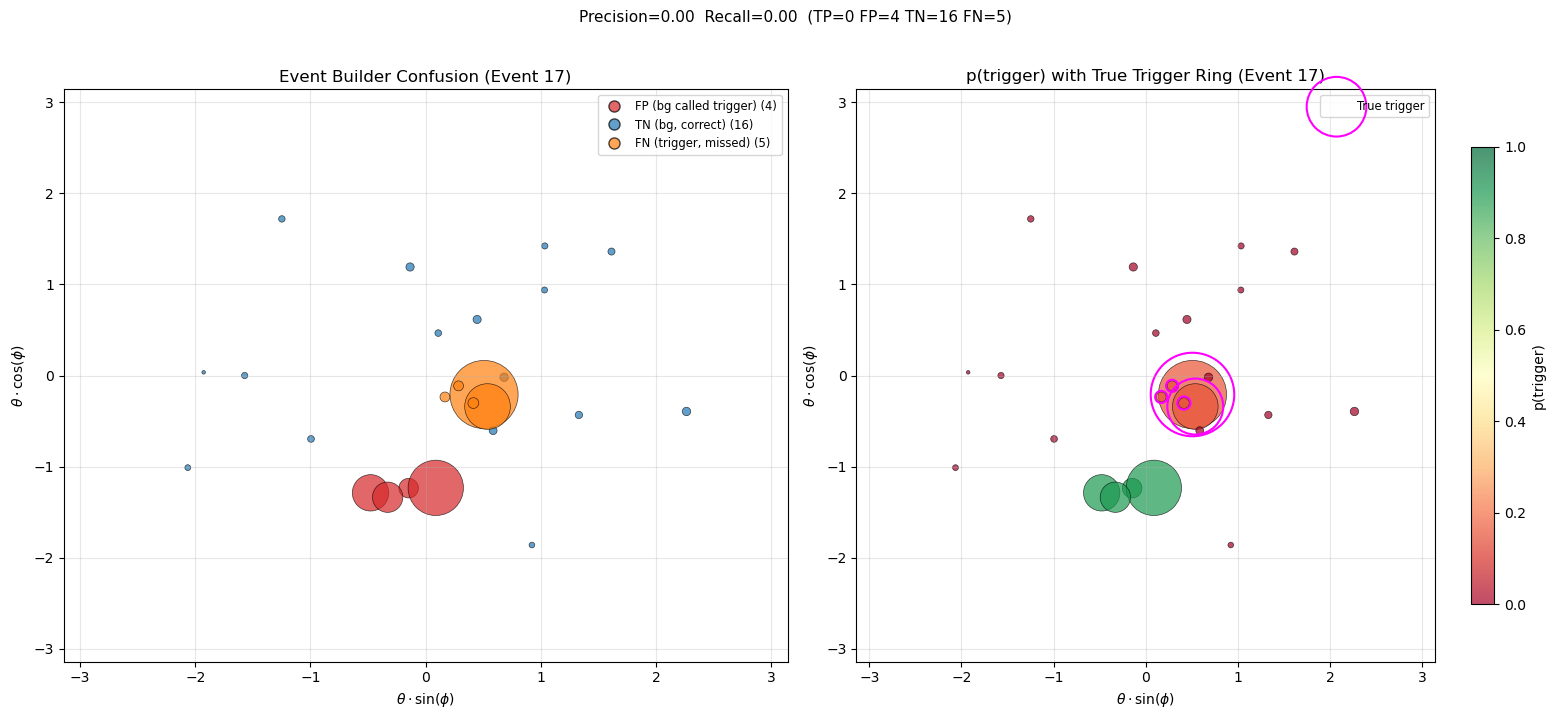

In [38]:
plot_event_builder_confusion(dataloader, model, event_idx=17)


In [21]:
FEATURE_NAMES = [
    'sin_theta', 'cos_theta', 'sin_phi', 'cos_phi',
    'inv_r', 'cos_sep_pos', 'cos_sep_exit',
    'cluster_E', 'dt_from_pos', 'beta',
    'soft_n_hits', 'max_hit_E',
]


def _find_event_batch(loader, event_id, device):
    """Iterate loader until event_id lands inside a batch; return (batch, local_idx)."""
    seen = 0
    for batch in loader:
        n = batch.num_graphs
        if seen + n > event_id:
            return batch.to(device), event_id - seen
        seen += n
    raise ValueError(f'Event {event_id} not in loader (saw {seen} events)')


def classifier_deep_dive(model, loader, device, event_id, task_weights=None,
                          show_taylor=True):
    """Introspect the event classifier for one event.

    Prints per cluster:
      - Ground-truth purity (hard argmax + soft weighted)
      - 12-d angular_feat_full input to lyso_angular_proj
      - dt_from_pos input to lyso_time_proj (normalized and in ns)
      - Logit, p_k
      - d(logit_k)/d(feat) local sensitivity
      - Taylor contribution (grad * feat) — additive decomposition of logit_k
      - Top-3 drivers per cluster
    """
    if task_weights is None:
        task_weights = {
            'w_lyso_condensation': 1.0, 'w_event_builder': 1.0,
            'w_positron_angle': 1.0, 'w_atar_trigger': 1.0,
            'w_atar_pdg': 1.0, 'w_atar_pion_stop': 1.0,
        }

    batch, local_idx = _find_event_batch(loader, event_id, device)
    model.eval()
    captured = {}

    def angular_pre_hook(module, inp):
        feat = inp[0].detach().clone().requires_grad_(True)
        captured['angular_feat'] = feat
        return (feat,)

    def time_pre_hook(module, inp):
        dt = inp[0].detach().clone().requires_grad_(True)
        captured['dt_feat'] = dt
        return (dt,)

    h1 = model.lyso_angular_proj.register_forward_pre_hook(angular_pre_hook)
    h2 = model.lyso_time_proj.register_forward_pre_hook(time_pre_hook)

    try:
        with torch.enable_grad():
            outputs = model(batch.x, batch.batch, task_weights)
    finally:
        h1.remove(); h2.remove()

    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    num_graphs = outputs.get('num_graphs_in_batch', batch.num_graphs)
    is_lyso = (batch.x[:, 7] > 0.5)
    graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=device)
    graph_has_lyso[batch.batch[is_lyso]] = True
    valid_ids = graph_has_lyso.nonzero().squeeze(-1).tolist()
    if local_idx not in valid_ids:
        print(f'Event {event_id} has no LYSO clusters'); return None
    lyso_graph_idx = valid_ids.index(local_idx)

    K = outputs['lyso_soft_assignments'].size(1)
    event_logits_all = outputs['unified_event_logits'].squeeze(-1)
    lyso_logits_matrix = event_logits_all[num_atar_tokens:].view(-1, K)
    event_logits = lyso_logits_matrix[lyso_graph_idx]
    event_probs = torch.sigmoid(event_logits)

    feat_matrix = captured['angular_feat'].view(-1, K, 12)
    dt_matrix = captured['dt_feat'].view(-1, K, 1)
    event_feat = feat_matrix[lyso_graph_idx]
    event_dt = dt_matrix[lyso_graph_idx]

    # Ground truth
    assignments = outputs['lyso_soft_assignments']
    lyso_hit_graph = batch.batch[is_lyso]
    event_mask = lyso_hit_graph == local_idx
    event_assign = assignments[event_mask]
    event_targets = batch.is_trigger_target[(batch.batch == local_idx) & is_lyso].float()

    soft_n_hits = event_assign.sum(dim=0)
    soft_n_trig = (event_assign * event_targets.unsqueeze(-1)).sum(dim=0)
    soft_purity = soft_n_trig / soft_n_hits.clamp(min=1e-6)
    hard_assign = event_assign.argmax(dim=1)
    hard_purity = torch.zeros(K, device=device)
    hard_n_hits = torch.zeros(K, device=device)
    for k in range(K):
        m = hard_assign == k
        if m.any():
            hard_n_hits[k] = m.sum()
            hard_purity[k] = event_targets[m].mean()

    # Gradient attribution
    grads = torch.zeros(K, 12, device=device)
    grads_dt = torch.zeros(K, device=device)
    for k in range(K):
        tgt = lyso_logits_matrix[lyso_graph_idx, k]
        if not tgt.isfinite(): continue
        g = torch.autograd.grad(
            tgt, [captured['angular_feat'], captured['dt_feat']],
            retain_graph=(k < K - 1), allow_unused=True)
        if g[0] is not None:
            grads[k] = g[0].view(-1, K, 12)[lyso_graph_idx, k]
        if g[1] is not None:
            grads_dt[k] = g[1].view(-1, K, 1)[lyso_graph_idx, k, 0]
    taylor = grads * event_feat.detach()
    taylor_dt = grads_dt * event_dt.detach().squeeze(-1)

    # Print
    print('=' * 120)
    print(f'CLASSIFIER INTROSPECTION — event {event_id} (local {local_idx}), K={K}')
    print('=' * 120)

    print('\n[Ground truth]')
    print(f"  {'k':>3} {'hard_pur':>9} {'hard_n':>7} {'soft_pur':>9} {'soft_n':>8}")
    for k in range(K):
        print(f"  {k:>3} {hard_purity[k].item():>9.3f} {int(hard_n_hits[k].item()):>7}"
              f" {soft_purity[k].item():>9.3f} {soft_n_hits[k].item():>8.3f}")

    print('\n[Classifier output]')
    print(f"  {'k':>3} {'logit':>9} {'p_k':>8}")
    for k in range(K):
        print(f"  {k:>3} {event_logits[k].item():>+9.3f} {event_probs[k].item():>8.4f}")

    def _header():
        s = f"  {'k':>3}"
        for n in FEATURE_NAMES: s += f' {n:>11}'
        return s

    print('\n[Input features -> lyso_angular_proj]')
    print(_header())
    for k in range(K):
        row = f"  {k:>3}"
        for i in range(12): row += f' {event_feat[k, i].item():>+11.4f}'
        print(row)

    print('\n[d(logit_k)/d(feat_i) local sensitivity]')
    print(_header())
    for k in range(K):
        row = f"  {k:>3}"
        for i in range(12): row += f' {grads[k, i].item():>+11.4f}'
        print(row)

    if show_taylor:
        print('\n[Taylor contribution grad*feat — additive decomposition of logit_k]')
        print(_header() + f' {"SUM":>11}')
        for k in range(K):
            row = f"  {k:>3}"
            for i in range(12): row += f' {taylor[k, i].item():>+11.4f}'
            row += f' {taylor[k].sum().item():>+11.4f}'
            print(row)

    print('\n[dt_from_pos (separate path -> lyso_time_proj)]')
    print(f"  {'k':>3} {'dt_norm':>10} {'dt_ns':>10} {'d_logit/d_dt':>14} {'taylor':>11}")
    for k in range(K):
        dt_n = event_dt[k, 0].item()
        print(f"  {k:>3} {dt_n:>10.4f} {dt_n * 500:>10.2f}"
              f" {grads_dt[k].item():>+14.4f} {taylor_dt[k].item():>+11.4f}")

    print('\n[Top 3 drivers per cluster (|taylor|)]')
    for k in range(K):
        top = taylor[k].abs().argsort(descending=True)[:3].tolist()
        parts = [f'{FEATURE_NAMES[i]}={taylor[k, i].item():+.3f}' for i in top]
        print(f'  k={k} p={event_probs[k].item():.3f} logit={event_logits[k].item():+.2f}'
              f' | angular: {", ".join(parts)} | dt_taylor={taylor_dt[k].item():+.3f}')
    print('=' * 120)

    return {
        'event_logits': event_logits.detach().cpu(),
        'event_probs': event_probs.detach().cpu(),
        'event_feat': event_feat.detach().cpu(),
        'event_dt': event_dt.detach().cpu(),
        'grads': grads.detach().cpu(),
        'grads_dt': grads_dt.detach().cpu(),
        'taylor': taylor.detach().cpu(),
        'taylor_dt': taylor_dt.detach().cpu(),
        'hard_purity': hard_purity.detach().cpu(),
        'soft_purity': soft_purity.detach().cpu(),
        'outputs': outputs,
    }


def classifier_failure_survey(model, loader, device, n_events=200, task_weights=None):
    """Scan up to n_events and aggregate stats on classifier failures (events
    where argmax p_k != argmax soft_purity_k). Reports which features drove
    the wrong pick vs the right pick, so systematic biases are visible.
    """
    if task_weights is None:
        task_weights = {
            'w_lyso_condensation': 1.0, 'w_event_builder': 1.0,
            'w_positron_angle': 1.0, 'w_atar_trigger': 1.0,
            'w_atar_pdg': 1.0, 'w_atar_pion_stop': 1.0,
        }
    model.eval()

    n_seen = 0; n_fail = 0
    wrong_t = torch.zeros(12); right_t = torch.zeros(12)
    abs_grad = torch.zeros(12)
    wrong_dt_t = 0.0; right_dt_t = 0.0
    wrong_dt_v = 0.0; right_dt_v = 0.0
    wrong_pool_taylor = 0.0
    right_pool_taylor = 0.0


    for batch in loader:
        if n_seen >= n_events:
            break
        batch = batch.to(device)
        captured = {}

        def a_hook(m, inp):
            f = inp[0].detach().clone().requires_grad_(True)
            captured['f'] = f
            return (f,)

        def t_hook(m, inp):
            d = inp[0].detach().clone().requires_grad_(True)
            captured['d'] = d
            return (d,)

        def p_hook(m, inp):
            p = inp[0].detach().clone().requires_grad_(True)
            captured['p'] = p
            return (p,)

        h1 = model.lyso_angular_proj.register_forward_pre_hook(a_hook)
        h2 = model.lyso_time_proj.register_forward_pre_hook(t_hook)
        h3 = model.lyso_pool_event_proj.register_forward_pre_hook(p_hook)

        try:
            with torch.enable_grad():
                outputs = model(batch.x, batch.batch, task_weights)
        finally:
            h1.remove(); h2.remove(); h3.remove()


        num_atar = outputs.get('unified_num_atar_tokens', 0)
        num_graphs = outputs.get('num_graphs_in_batch', batch.num_graphs)
        is_lyso = (batch.x[:, 7] > 0.5)
        graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=device)
        graph_has_lyso[batch.batch[is_lyso]] = True
        valid_ids = graph_has_lyso.nonzero().squeeze(-1).tolist()
        K = outputs['lyso_soft_assignments'].size(1)
        lyso_logits_matrix = outputs['unified_event_logits'].squeeze(-1)[num_atar:].view(-1, K)
        assignments = outputs['lyso_soft_assignments']
        lyso_hit_graph = batch.batch[is_lyso]

        for g_local in valid_ids:
            n_seen += 1
            if n_seen > n_events: break
            lyso_idx = valid_ids.index(g_local)
            ev_mask = lyso_hit_graph == g_local
            ev_assign = assignments[ev_mask]
            ev_tgt = batch.is_trigger_target[(batch.batch == g_local) & is_lyso].float()
            if ev_tgt.sum() < 0.5: continue
            soft_n = ev_assign.sum(dim=0)
            soft_trig = (ev_assign * ev_tgt.unsqueeze(-1)).sum(dim=0)
            purity = soft_trig / soft_n.clamp(min=1e-6)
            right_k = int(purity.argmax().item())
            probs = torch.sigmoid(lyso_logits_matrix[lyso_idx])
            picked_k = int(probs.argmax().item())
            if picked_k == right_k: continue
            n_fail += 1

            grads = torch.zeros(K, 12, device=device)
            grads_dt = torch.zeros(K, device=device)
            for k in (picked_k, right_k):
                tgt = lyso_logits_matrix[lyso_idx, k]
                if not tgt.isfinite(): continue
                g = torch.autograd.grad(
                    tgt, [captured['f'], captured['d']],
                    retain_graph=True, allow_unused=True)
                if g[0] is not None:
                    grads[k] = g[0].view(-1, K, 12)[lyso_idx, k]
                if g[1] is not None:
                    grads_dt[k] = g[1].view(-1, K, 1)[lyso_idx, k, 0]

            fm = captured['f'].view(-1, K, 12)[lyso_idx].detach()
            dm = captured['d'].view(-1, K, 1)[lyso_idx].detach().squeeze(-1)

            wrong_t += (grads[picked_k] * fm[picked_k]).cpu()
            right_t += (grads[right_k] * fm[right_k]).cpu()
            abs_grad += grads[picked_k].abs().cpu()
            wrong_dt_t += (grads_dt[picked_k] * dm[picked_k]).item()
            right_dt_t += (grads_dt[right_k] * dm[right_k]).item()
            wrong_dt_v += dm[picked_k].item()
            right_dt_v += dm[right_k].item()

    for k in (picked_k, right_k):
        tgt = lyso_logits_matrix[lyso_idx, k]
        if not tgt.isfinite():
            continue
        g = torch.autograd.grad(
            tgt, [captured['f'], captured['d'], captured['p']],
            retain_graph=True, allow_unused=True)
        if g[0] is not None:
            grads[k] = g[0].view(-1, K, 12)[lyso_idx, k]
        if g[1] is not None:
            grads_dt[k] = g[1].view(-1, K, 1)[lyso_idx, k, 0]
        if g[2] is not None:
            pool_dim = g[2].size(-1)
            pool_g = g[2].view(-1, K, pool_dim)[lyso_idx, k]
            pool_f = captured['p'].view(-1, K, pool_dim)[lyso_idx, k].detach()
            contrib = (pool_g * pool_f).sum().item()
            if k == picked_k:
                wrong_pool_taylor += contrib
            else:
                right_pool_taylor += contrib



    if n_fail == 0:
        print(f'No failures in {n_seen} events.'); return

    print('=' * 100)
    print(f'FAILURE SURVEY: {n_fail}/{n_seen} ({100*n_fail/n_seen:.1f}%)')
    print('=' * 100)
    print('\n[Mean |grad_picked| per feature] — classifier sensitivity on wrong picks')
    for i, n in enumerate(FEATURE_NAMES):
        print(f'  {n:>14}  {abs_grad[i].item()/n_fail:>8.4f}')
    print('\n[Mean Taylor wrong vs right] — positive Δ means feature drove wrong pick')
    diff = (wrong_t - right_t) / n_fail
    ordered = sorted(enumerate(FEATURE_NAMES), key=lambda x: -abs(diff[x[0]].item()))
    for i, n in ordered:
        print(f'  {n:>14}  wrong={wrong_t[i].item()/n_fail:>+7.3f}  '
              f'right={right_t[i].item()/n_fail:>+7.3f}  Δ={diff[i].item():>+7.3f}')
    print(f'\n  {"dt_from_pos":>14}  wrong={wrong_dt_t/n_fail:>+7.3f}  '
          f'right={right_dt_t/n_fail:>+7.3f}  Δ={(wrong_dt_t-right_dt_t)/n_fail:>+7.3f}')
    print(f'  {"pool_proj (sum)":>14}  wrong={wrong_pool_taylor/n_fail:>+7.3f}  '
      f'right={right_pool_taylor/n_fail:>+7.3f}  '
      f'delta={(wrong_pool_taylor-right_pool_taylor)/n_fail:>+7.3f}')

    print(f'  {"(dt_norm val)":>14}  wrong={wrong_dt_v/n_fail:>+7.3f}  '
          f'right={right_dt_v/n_fail:>+7.3f}')
    print('=' * 100)

In [45]:
result = classifier_deep_dive(model, dataloader, device, event_id=0)

CLASSIFIER INTROSPECTION — event 0 (local 0), K=5

[Ground truth]
    k  hard_pur  hard_n  soft_pur   soft_n
    0     0.000       7     0.000    6.126
    1     0.000      11     0.000    0.785
    2     0.000       0     0.000    0.298
    3     0.000       0     0.000    0.236
    4     0.000       0     0.000    0.233

[Classifier output]
    k     logit      p_k
    0    -4.923   0.0072
    1    -5.109   0.0060
    2    -4.963   0.0069
    3    -4.936   0.0071
    4    -4.931   0.0072

[Input features -> lyso_angular_proj]
    k   sin_theta   cos_theta     sin_phi     cos_phi       inv_r cos_sep_pos cos_sep_exit   cluster_E dt_from_pos        beta soft_n_hits   max_hit_E
    0     +0.8848     -0.4660     -0.0273     -0.9996     +0.7406     -0.0812     -0.7278     +1.1389     +0.0000     +1.0000     +6.1256     +0.5103
    1     +0.7716     -0.6361     +0.9957     +0.0930     +0.5602     +0.2457     -0.3606     +0.0063     +0.0000     +0.1541     +0.7846     +0.0063
    2     +0.77

In [22]:
classifier_failure_survey(model, dataloader, device, n_events=200)

FAILURE SURVEY: 39/201 (19.4%)

[Mean |grad_picked| per feature] — classifier sensitivity on wrong picks
       sin_theta    0.2264
       cos_theta    0.1359
         sin_phi    0.1266
         cos_phi    0.0711
           inv_r    0.7637
     cos_sep_pos    3.4316
    cos_sep_exit    0.1455
       cluster_E    0.9581
     dt_from_pos    0.6717
            beta    0.7723
     soft_n_hits    0.0903
       max_hit_E    0.1316

[Mean Taylor wrong vs right] — positive Δ means feature drove wrong pick
     cos_sep_pos  wrong= +3.124  right= +4.633  Δ= -1.509
            beta  wrong= -0.760  right= -0.034  Δ= -0.726
       sin_theta  wrong= -0.155  right= -0.827  Δ= +0.671
           inv_r  wrong= +0.539  right= +1.087  Δ= -0.549
       cluster_E  wrong= -0.485  right= -0.040  Δ= -0.446
       cos_theta  wrong= +0.068  right= +0.345  Δ= -0.276
    cos_sep_exit  wrong= +0.119  right= +0.310  Δ= -0.191
     soft_n_hits  wrong= -0.005  right= +0.156  Δ= -0.161
     dt_from_pos  wrong= +0.307  

In [ ]:
# DIAGNOSTIC: Run this in a cell to trace the event builder data flow
model.train()
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    outputs = model(batch.x, batch.batch, task_weights=task_weights)

    event_logits = outputs.get('unified_event_logits')
    if event_logits is not None:
        p_tokens = torch.sigmoid(event_logits.squeeze(-1))
        n_atar = outputs.get('unified_num_atar_tokens', 0)
        print(f"Total tokens: {len(p_tokens)}, ATAR: {n_atar}, LYSO: {len(p_tokens) - n_atar}")
        print(f"ATAR p range: {p_tokens[:n_atar].min():.4f} - {p_tokens[:n_atar].max():.4f}, mean: {p_tokens[:n_atar].mean():.4f}")
        if len(p_tokens) > n_atar:
            p_lyso = p_tokens[n_atar:]
            print(f"LYSO p range: {p_lyso.min():.4f} - {p_lyso.max():.4f}, mean: {p_lyso.mean():.4f}")
            print(f"LYSO logit range: {event_logits[n_atar:].min():.4f} - {event_logits[n_atar:].max():.4f}")
        
        # Check assignments
        lyso_assign = outputs.get('lyso_soft_assignments')
        if lyso_assign is not None:
            print(f"\nAssignments shape: {lyso_assign.shape}")
            print(f"Assignment row sums: min={lyso_assign.sum(1).min():.4f}, max={lyso_assign.sum(1).max():.4f}, mean={lyso_assign.sum(1).mean():.4f}")
        
        lyso_beta = outputs.get('lyso_seed_beta')
        if lyso_beta is not None:
            K = lyso_assign.size(1) if lyso_assign is not None else 5
            beta_mat = lyso_beta.view(-1, K)
            print(f"\nSeed beta per cluster: {beta_mat.mean(0).cpu().numpy()}")
            print(f"Seed beta range: {lyso_beta.min():.4f} - {lyso_beta.max():.4f}")
        
        # Check targets
        is_lyso = (batch.x[:, 7] > 0.5)
        lyso_targets = batch.is_trigger_target[is_lyso]
        print(f"\nLYSO targets: {lyso_targets.sum():.0f} trigger / {len(lyso_targets)} total ({100*lyso_targets.mean():.1f}%)")
        
        # Check effective mixture p_hit
        if lyso_assign is not None and lyso_beta is not None:
            K = lyso_assign.size(1)
            p_lyso_mat = p_lyso.view(-1, K)
            lyso_batch_ids = batch.batch[is_lyso]
            num_g = batch.batch.max().item() + 1
            g_has_lyso = torch.zeros(num_g, dtype=torch.bool, device=device)
            g_has_lyso[lyso_batch_ids] = True
            mapped = torch.cumsum(g_has_lyso.long(), dim=0) - 1
            lyso_mapped = mapped[lyso_batch_ids]
            
            p_broad = p_lyso_mat[lyso_mapped]
            beta_broad = beta_mat[lyso_mapped]
            eff_w = lyso_assign * beta_broad
            w_sum = eff_w.sum(1).clamp(min=1e-6)
            p_hit = (eff_w * p_broad).sum(1) / w_sum
            
            print(f"\np_hit range: {p_hit.min():.4f} - {p_hit.max():.4f}, mean: {p_hit.mean():.4f}")
            print(f"p_hit for trigger hits: mean={p_hit[lyso_targets > 0.5].mean():.4f}" if (lyso_targets > 0.5).any() else "No trigger hits")
            print(f"p_hit for bg hits: mean={p_hit[lyso_targets < 0.5].mean():.4f}")
            
            # The key question: are all clusters getting the same logit?
            print(f"\nPer-cluster logit means: {event_logits[n_atar:].view(-1, K).mean(0).cpu().numpy()}")
            print(f"Per-cluster logit stds:  {event_logits[n_atar:].view(-1, K).std(0).cpu().numpy()}")
    else:
        print("No unified_event_logits in output!")


Total tokens: 97, ATAR: 37, LYSO: 60
ATAR p range: 0.0003 - 0.9999, mean: 0.9451
LYSO p range: 0.0003 - 0.8223, mean: 0.1423
LYSO logit range: -8.2395 - 1.5318

Assignments shape: torch.Size([224, 5])
Assignment row sums: min=0.0000, max=0.9674, mean=0.3421

Seed beta per cluster: [0.83098686 0.29226768 0.03008688 0.01608816 0.01044212]
Seed beta range: 0.0001 - 1.0000

LYSO targets: 38 trigger / 224 total (17.0%)

p_hit range: 0.0000 - 0.8213, mean: 0.2121
p_hit for trigger hits: mean=0.7556
p_hit for bg hits: mean=0.1010

Per-cluster logit means: [-0.7623009 -5.7364645 -7.5440383 -7.5968757 -7.345107 ]
Per-cluster logit stds:  [3.405031   3.9059086  0.88513976 0.75727224 0.8378261 ]


In [ ]:
@torch.no_grad()
def positron_dir_diagnostic(model, dataloader, device, task_weights, n_batches=3):
    """Check whether the reconstructed positron direction points at the true
    trigger LYSO cluster.

    Steps:
      1. From is_trigger_target on LYSO hits, compute the E-weighted centroid
         of the TRUE trigger cluster per graph (in /100mm physical space).
      2. True direction = normalize(centroid) — origin-centered, matching the
         forward pass convention (pion-stop removal was dropped).
      3. Compare cos(atar_positron_dir, true_dir).
      4. Also report cos_sep_positron (the feature the model actually uses)
         per K cluster, split by per-cluster trigger purity. A well-aligned
         positron_dir produces cos_sep_positron ≈ 1 on TRIG clusters and
         ≈ random on BG clusters.
    """
    import torch.nn.functional as F
    model.eval()
    all_cos_pred_true = []
    all_cos_feat_trig = []
    all_cos_feat_bg = []
    batches_done = 0

    for batch in dataloader:
        batch = batch.to(device)
        outputs = model(batch.x, batch.batch, task_weights=task_weights)

        positron_dir = outputs.get('atar_positron_dir')
        seed_coords = outputs.get('lyso_seed_coords')           # [B, K, 3]
        has_lyso = outputs.get('lyso_seed_has_lyso')            # [B] bool
        lyso_assignments = outputs.get('lyso_soft_assignments') # [N_lyso, K]
        if positron_dir is None or seed_coords is None or lyso_assignments is None:
            print('[pos_dir diag] missing outputs; skipping batch')
            continue

        is_lyso = (batch.x[:, 7] > 0.5)
        lyso_pos = batch.x[is_lyso, :3]                   # [N_lyso, 3] /100mm
        lyso_E = batch.x[is_lyso, 3]                      # normalized
        lyso_target = batch.is_trigger_target[is_lyso]
        lyso_batch = batch.batch[is_lyso]
        num_graphs = batch.batch.max().item() + 1

        # --- 1. True trigger centroid per graph (E-weighted) ---
        w = (lyso_E * (lyso_target > 0.5).float()).unsqueeze(-1)
        num = torch.zeros(num_graphs, 3, device=batch.x.device)
        den = torch.zeros(num_graphs, 1, device=batch.x.device)
        num.index_add_(0, lyso_batch, lyso_pos * w)
        den.index_add_(0, lyso_batch, w)
        has_true = (den.squeeze(-1) > 1e-6)
        if not has_true.any():
            continue
        true_centroid = num / den.clamp(min=1e-9)
        true_dir = F.normalize(true_centroid, p=2, dim=-1)

        # --- 2. cos(predicted, true) ---
        cos_pred_true = (F.normalize(positron_dir, dim=-1) * true_dir).sum(dim=-1)
        cos_pred_true = cos_pred_true[has_true]
        all_cos_pred_true.append(cos_pred_true.cpu())

        # --- 3. cos_sep_positron feature per cluster, split by purity ---
        cluster_dir = F.normalize(seed_coords, p=2, dim=-1)     # [B, K, 3]
        pos_dir_b = F.normalize(positron_dir, dim=-1).unsqueeze(1)  # [B, 1, 3]
        cos_sep = (cluster_dir * pos_dir_b).sum(dim=-1)         # [B, K]

        graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=batch.x.device)
        graph_has_lyso[lyso_batch] = True
        mapped_idx = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped = mapped_idx[lyso_batch]
        K = lyso_assignments.size(1)
        n_lyso_graphs = int(graph_has_lyso.sum().item())

        trig_mass = torch.zeros(n_lyso_graphs * K, device=batch.x.device)
        total_mass = torch.zeros(n_lyso_graphs * K, device=batch.x.device)
        flat_cluster_id = (lyso_mapped.unsqueeze(-1) * K +
                           torch.arange(K, device=batch.x.device).unsqueeze(0))
        trig_mass.index_add_(0, flat_cluster_id.reshape(-1),
            (lyso_assignments * (lyso_target > 0.5).float().unsqueeze(-1)).reshape(-1))
        total_mass.index_add_(0, flat_cluster_id.reshape(-1),
            lyso_assignments.reshape(-1))
        cluster_purity = (trig_mass / total_mass.clamp(min=1e-6)).view(n_lyso_graphs, K)
        total_mass_2d = total_mass.view(n_lyso_graphs, K)

        cos_sep_valid = cos_sep[has_lyso] if has_lyso is not None else cos_sep
        if cos_sep_valid.shape != cluster_purity.shape:
            print(f'[pos_dir diag] shape mismatch {cos_sep_valid.shape} vs {cluster_purity.shape}; skipping batch')
            continue

        trig_cluster_mask = (cluster_purity > 0.5) & (total_mass_2d > 1e-3)
        bg_cluster_mask = (cluster_purity <= 0.5) & (total_mass_2d > 1e-3)
        if trig_cluster_mask.any():
            all_cos_feat_trig.append(cos_sep_valid[trig_cluster_mask].cpu())
        if bg_cluster_mask.any():
            all_cos_feat_bg.append(cos_sep_valid[bg_cluster_mask].cpu())

        batches_done += 1
        if batches_done >= n_batches:
            break

    if not all_cos_pred_true:
        print('[pos_dir diag] no graphs with trigger LYSO hits encountered')
        return

    cos_pt = torch.cat(all_cos_pred_true)
    print('=' * 60)
    print(f'[pos_dir diag] cos(atar_positron_dir, true_trigger_centroid)')
    print(f'  n={cos_pt.numel()}')
    print(f'  mean={cos_pt.mean():.3f}  median={cos_pt.median():.3f}  std={cos_pt.std():.3f}')
    print(f'  frac > 0.9  : {(cos_pt > 0.9).float().mean():.3f}  (perfectly pointing)')
    print(f'  frac > 0.5  : {(cos_pt > 0.5).float().mean():.3f}  (roughly pointing)')
    print(f'  frac > 0    : {(cos_pt > 0.0).float().mean():.3f}  (same hemisphere)')
    print(f'  frac < -0.5 : {(cos_pt < -0.5).float().mean():.3f}  (pointing AWAY)')

    if all_cos_feat_trig:
        ct = torch.cat(all_cos_feat_trig)
        print(f'\n[pos_dir diag] feature cos_sep_positron | TRIG cluster (purity>0.5)')
        print(f'  n={ct.numel()}  mean={ct.mean():.3f}  median={ct.median():.3f}  std={ct.std():.3f}')
    if all_cos_feat_bg:
        cb = torch.cat(all_cos_feat_bg)
        print(f'\n[pos_dir diag] feature cos_sep_positron | BG cluster (purity<=0.5)')
        print(f'  n={cb.numel()}  mean={cb.mean():.3f}  median={cb.median():.3f}  std={cb.std():.3f}')
    if all_cos_feat_trig and all_cos_feat_bg:
        sep = torch.cat(all_cos_feat_trig).mean() - torch.cat(all_cos_feat_bg).mean()
        print(f'\n[pos_dir diag] TRIG − BG mean(cos_sep_positron) = {sep:.3f}')
        print('  (positive = feature is discriminative; ~0 = feature is useless)')
    print('=' * 60)


# Example usage (uncomment to run after model/dataloader are defined):
# positron_dir_diagnostic(model, dataloader, device, task_weights, n_batches=3)


In [ ]:
positron_dir_diagnostic(model, dataloader, device, task_weights, n_batches=3)

[pos_dir diag] cos(atar_positron_dir, true_trigger_centroid)
  n=28
  mean=0.986  median=0.991  std=0.018
  frac > 0.9  : 1.000  (perfectly pointing)
  frac > 0.5  : 1.000  (roughly pointing)
  frac > 0    : 1.000  (same hemisphere)
  frac < -0.5 : 0.000  (pointing AWAY)

[pos_dir diag] feature cos_sep_positron | TRIG cluster (purity>0.5)
  n=38  mean=0.889  median=0.984  std=0.248

[pos_dir diag] feature cos_sep_positron | BG cluster (purity<=0.5)
  n=142  mean=-0.128  median=-0.240  std=0.617

[pos_dir diag] TRIG − BG mean(cos_sep_positron) = 1.017
  (positive = feature is discriminative; ~0 = feature is useless)


In [ ]:
def find_failed_atar_matches(dataset_obj, model_obj, n_events=100, threshold=0.5):
    """Scan events using Phase 9 trigger classifier (atar_trigger_logits)."""
    model_obj.train()
    failed = []
    
    for idx in range(min(n_events, len(dataset_obj))):
        data = dataset_obj[idx]
        with torch.no_grad():
            loader = DataLoader([data], batch_size=1)
            batch = next(iter(loader)).to(device)
            outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_trigger_slice': 1.0})
        
        trigger_logits = outputs.get('atar_trigger_logits')
        if trigger_logits is None:
            continue
        
        pred_trigger = (torch.sigmoid(trigger_logits) > threshold).cpu()
        
        # Ground truth: per-slice trigger target
        true_trigger = batch.atar_slice_trigger_target.cpu().bool()
        
        # atar_trigger_logits only covers valid slices — align with valid slice targets
        valid_mask = outputs['valid_slice_mask'].cpu()
        num_slices_max = outputs['num_slices_max']
        
        # Reconstruct which slices are valid and get their truth
        # atar_slice_trigger_target is per-valid-slice from dataset
        n = min(len(pred_trigger), len(true_trigger))
        if n == 0:
            continue
        
        if (pred_trigger[:n] != true_trigger[:n]).any():
            n_wrong = (pred_trigger[:n] != true_trigger[:n]).sum().item()
            failed.append({'idx': idx, 'n_wrong': n_wrong, 'n_slices': n,
                           'pred': pred_trigger[:n].tolist(), 'truth': true_trigger[:n].tolist()})
    
    print(f"Scanned {min(n_events, len(dataset_obj))} events, found {len(failed)} with mismatches")
    for f in failed[:20]:
        print(f"  Event {f['idx']}: {f['n_wrong']}/{f['n_slices']} slices wrong")
    return failed


# Usage:
# failed = find_failed_atar_matches(test_ds, model, n_events=200)

In [ ]:
def plot_event_builder_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """Plot ATAR hits colored by TP (green), TN (gray), FP (orange), FN (red)."""
    model_obj.train()
    data = dataset_obj[event_idx]
    
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_trigger_slice': 1.0})
    
    event_logits = outputs.get('atar_trigger_logits')
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    if event_logits is None or num_atar_tokens == 0:
        print(f"Event {event_idx}: no ATAR event builder output")
        return
    
    # Per-slice predictions
    p_atar = torch.sigmoid(event_logits.squeeze(-1))[:num_atar_tokens].cpu()
    pred_trigger_slice = (p_atar > threshold)
    
    # Map slices back to hits
    is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
    valid_slice_mask = outputs['valid_slice_mask'].cpu()
    num_slices_max = outputs['num_slices_max']
    global_slice_ids = (batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 8].long()).cpu()
    
    hit_is_valid = valid_slice_mask[global_slice_ids]
    mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
    
    # Per-hit truth and prediction
    hit_truth = batch.is_trigger_target[is_atar].cpu().bool()
    hit_pred = torch.zeros_like(hit_truth)
    valid_idx = mapped_slice_indices[global_slice_ids[hit_is_valid]]
    hit_pred[hit_is_valid] = pred_trigger_slice[valid_idx]
    
    # Classify: TP, TN, FP, FN
    tp = hit_pred & hit_truth
    tn = ~hit_pred & ~hit_truth
    fp = hit_pred & ~hit_truth
    fn = ~hit_pred & hit_truth
    
    colors = np.full(len(hit_truth), 'gray', dtype=object)  # TN = gray
    colors[tp.numpy()] = 'green'   # TP
    colors[fp.numpy()] = 'orange'  # FP
    colors[fn.numpy()] = 'red'     # FN
    
    # Geometry from dataframe
    row = dataset_obj.df.iloc[event_idx]
    atar_x = np.array(row['atar_x'])
    atar_y = np.array(row['atar_y'])
    atar_z = np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    
    # Stats
    n_tp, n_tn, n_fp, n_fn = tp.sum().item(), tn.sum().item(), fp.sum().item(), fn.sum().item()
    accuracy = (n_tp + n_tn) / max(n_tp + n_tn + n_fp + n_fn, 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} — ATAR Event Builder  '
                 f'(TP:{n_tp} TN:{n_tn} FP:{n_fp} FN:{n_fn}  Acc:{accuracy:.1%})', fontsize=14)
    
    # XZ
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz],
                c=colors[mask_xz], s=atar_s[mask_xz], alpha=0.8, edgecolors='k', linewidths=0.3)
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-13.5, 13.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_title("X-Z Projection")
    
    # YZ
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz],
                c=colors[mask_yz], s=atar_s[mask_yz], alpha=0.8, edgecolors='k', linewidths=0.3)
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-13.5, 13.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_title("Y-Z Projection")
    
    handles = [
        mpatches.Patch(color='green', label=f'TP ({n_tp})'),
        mpatches.Patch(color='gray', label=f'TN ({n_tn})'),
        mpatches.Patch(color='orange', label=f'FP ({n_fp})'),
        mpatches.Patch(color='red', label=f'FN ({n_fn})')
    ]
    ax1.legend(handles=handles, loc='upper left')
    ax2.legend(handles=handles, loc='upper left')
    
    # Per-slice probability bar chart
    fig2, ax3 = plt.subplots(figsize=(max(8, num_atar_tokens * 0.5), 4))
    slice_probs = p_atar.numpy()
    
    # Per-slice ground truth
    slice_trigger_sum = torch.zeros(valid_slice_mask.size(0))
    slice_count = torch.zeros(valid_slice_mask.size(0))
    slice_trigger_sum.index_add_(0, global_slice_ids, hit_truth.float())
    slice_count.index_add_(0, global_slice_ids, torch.ones(global_slice_ids.size(0)))
    slice_gt = ((slice_trigger_sum / slice_count.clamp(min=1)) > 0.5)[valid_slice_mask].numpy()
    
    bar_colors = ['green' if gt else 'gray' for gt in slice_gt[:len(slice_probs)]]
    ax3.bar(range(len(slice_probs)), slice_probs, color=bar_colors, edgecolor='k', linewidth=0.5)
    ax3.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    ax3.set_xlabel('Slice Index'); ax3.set_ylabel('Trigger Probability')
    ax3.set_title(f'Event {event_idx} — Per-Slice Trigger Probability (bar color = ground truth)')
    ax3.legend()
    ax3.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

# Usage:
# plot_event_builder_debug(test_ds, model, event_idx=failed[0]['idx'])


In [ ]:
failed = find_failed_atar_matches(dataset, model, n_events=1000)

Scanned 1000 events, found 18 with mismatches
  Event 42: 2/8 slices wrong
  Event 110: 2/6 slices wrong
  Event 122: 1/3 slices wrong
  Event 167: 1/5 slices wrong
  Event 203: 1/7 slices wrong
  Event 207: 1/7 slices wrong
  Event 228: 3/8 slices wrong
  Event 352: 2/4 slices wrong
  Event 387: 3/6 slices wrong
  Event 419: 1/4 slices wrong
  Event 500: 1/3 slices wrong
  Event 529: 1/7 slices wrong
  Event 593: 1/3 slices wrong
  Event 721: 1/3 slices wrong
  Event 741: 1/3 slices wrong
  Event 826: 1/6 slices wrong
  Event 871: 1/5 slices wrong
  Event 948: 1/7 slices wrong


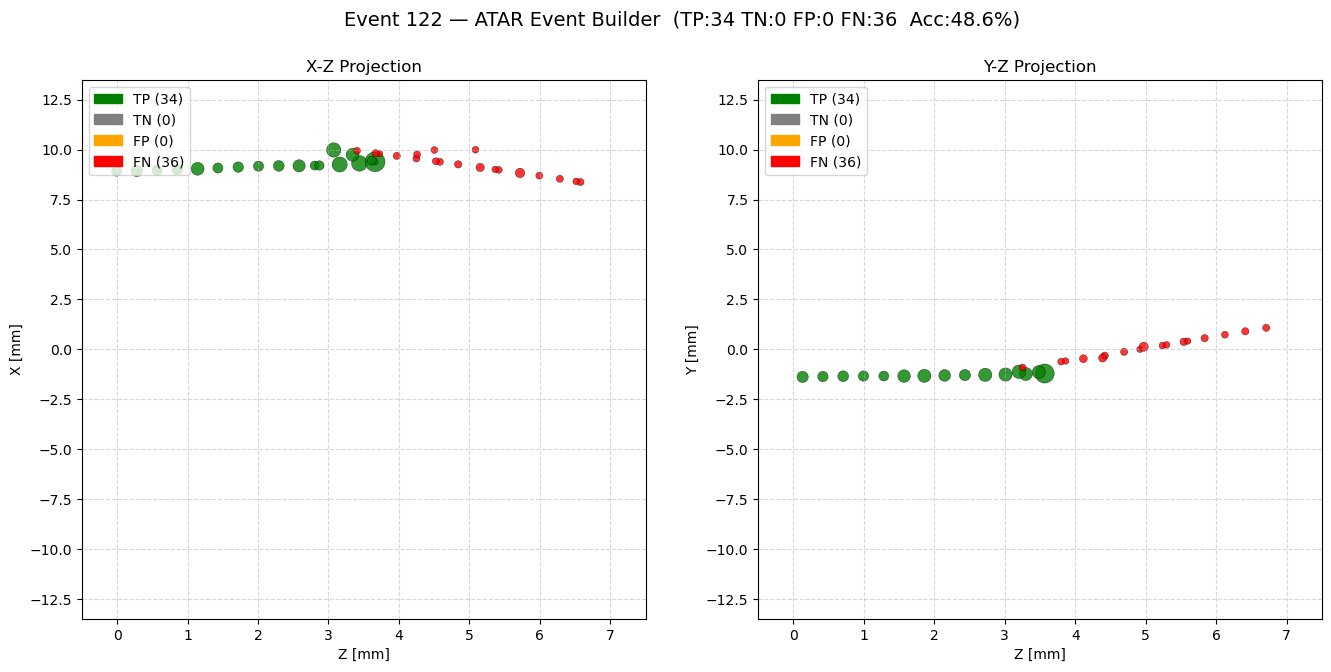

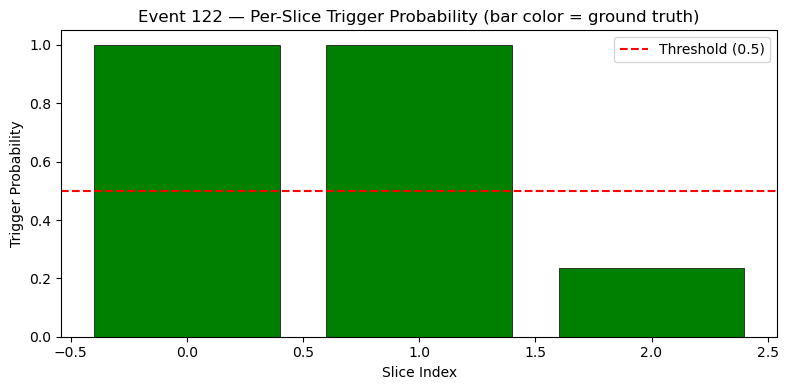

In [ ]:
#plot_event_builder_debug(dataset, model, event_idx=failed[7]['idx'])
plot_event_builder_debug(dataset, model, event_idx=122)

In [36]:
def plot_trigger_distributions_by_pdg(dataset_obj, model_obj, n_events=200, threshold=0.5):
    """Plot per-slice trigger probability distributions split by PDG class."""
    model_obj.train()
    
    # Collect per-slice: (prob, is_trigger, pdg_class)
    pdg_names = {0: 'Pion', 1: 'Muon', 2: 'MIP'}
    trig_probs = {0: [], 1: [], 2: []}
    bkg_probs = {0: [], 1: [], 2: []}
    
    for idx in range(min(n_events, len(dataset_obj))):
        data = dataset_obj[idx]
        with torch.no_grad():
            loader = DataLoader([data], batch_size=1)
            batch = next(iter(loader)).to(device)
            outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_trigger_slice': 1.0, 'w_slice_pdg': 1.0})
        
        logits = outputs.get('atar_trigger_logits')
        if logits is None or logits.numel() == 0:
            continue
        
        probs = torch.sigmoid(logits).cpu()
        truth = batch.atar_slice_trigger_target.cpu().bool()
        
        # Slice PDG: predicted dominant class per slice
        slice_pdg = torch.argmax(outputs['atar_slice_pdg'], dim=1).cpu()
        
        n = min(len(probs), len(truth), len(slice_pdg))
        
        for i in range(n):
            cls = slice_pdg[i].item()
            if cls not in pdg_names:
                continue
            if truth[i]:
                trig_probs[cls].append(probs[i].item())
            else:
                bkg_probs[cls].append(probs[i].item())
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    for row, cls in enumerate([0, 1, 2]):
        ax_hist, ax_bar = axes[row]
        tp = trig_probs[cls]
        bp = bkg_probs[cls]
        name = pdg_names[cls]
        
        # Left: overlaid log-scale histogram
        bins = np.linspace(0, 1, 31)
        if tp:
            ax_hist.hist(tp, bins=bins, color='green', alpha=0.6, edgecolor='k', label=f'Trigger ({len(tp)})')
        if bp:
            ax_hist.hist(bp, bins=bins, color='red', alpha=0.6, edgecolor='k', label=f'Background ({len(bp)})')
        ax_hist.axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold})')
        ax_hist.set_yscale('log')
        ax_hist.set_xlabel('P(trigger)')
        ax_hist.set_ylabel('Slices')
        ax_hist.set_title(f'{name} Slices — Trigger Probability')
        ax_hist.legend()
        ax_hist.set_ylim(bottom=0.5)
        
        # Right: class balance
        ax_bar.bar(['Trigger', 'Background'], [len(tp), len(bp)], color=['green', 'red'], edgecolor='k')
        ax_bar.set_ylabel('Slices')
        ax_bar.set_title(f'{name} Slices — Class Balance')
        
        # Print stats
        if tp:
            tp_arr = np.array(tp)
            print(f"{name} Trigger:    mean P={tp_arr.mean():.3f}, correct (>0.5): {(tp_arr > 0.5).sum()}/{len(tp)} ({(tp_arr > 0.5).mean()*100:.1f}%)")
        if bp:
            bp_arr = np.array(bp)
            print(f"{name} Background: mean P={bp_arr.mean():.3f}, correct (<0.5): {(bp_arr < 0.5).sum()}/{len(bp)} ({(bp_arr < 0.5).mean()*100:.1f}%)")
    
    total = sum(len(v) for v in trig_probs.values()) + sum(len(v) for v in bkg_probs.values())
    fig.suptitle(f'Trigger Classifier by PDG — {total} slices from {n_events} events', fontsize=16)
    plt.tight_layout()
    plt.show()

# Usage:
# plot_trigger_distributions_by_pdg(test_ds, model, n_events=500)


In [31]:
def plot_event_builder_confusion(dataset_obj, model_obj, event_idx=0, trigger_threshold=0.5):
    """
    LYSO event display colored by TP/FP/TN/FN for event builder trigger classification.
    Uses assignment-weighted mixture probability per hit (matching the loss function).
    """
    model_obj.eval()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]

    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_lyso_condensation': 1.0, 'w_event_builder': 1.0})

    # --- Filter LYSO hits ---
    is_lyso = (batch.x[:, 7] > 0.5).cpu()
    if not is_lyso.any():
        print(f"No LYSO hits in event {event_idx}")
        return

    x_orig = batch.x[is_lyso, 0].cpu().numpy() * 100.0
    y_orig = batch.x[is_lyso, 1].cpu().numpy() * 100.0
    z_orig = batch.x[is_lyso, 2].cpu().numpy() * 100.0
    energy = batch.x[is_lyso, 3].cpu().numpy() * 70.0
    times  = batch.x[is_lyso, 4].cpu().numpy() * 500.0

    r = np.sqrt(x_orig**2 + y_orig**2 + z_orig**2)
    theta = np.arccos(np.clip(z_orig / r, -1.0, 1.0))
    phi = np.arctan2(y_orig, x_orig)
    proj_x = theta * np.sin(phi)
    proj_y = theta * np.cos(phi)
    marker_sizes = np.maximum(energy * 50.0, 5.0)

    # --- Ground truth ---
    targets = batch.is_trigger_target[is_lyso].cpu().numpy()  # per-hit binary

    # --- Predicted p_hit via assignment-weighted mixture ---
    lyso_assignments = outputs.get('lyso_soft_assignments')  # [N_lyso_hits, K]
    event_logits = outputs.get('unified_event_logits')
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)

    if lyso_assignments is None or event_logits is None:
        print("Model did not produce LYSO event builder outputs")
        return

    p_tokens = torch.sigmoid(event_logits.squeeze(-1)).cpu()
    p_lyso = p_tokens[num_atar_tokens:]
    K = lyso_assignments.size(1)
    p_lyso_matrix = p_lyso.view(-1, K)  # [num_lyso_graphs, K]

    # For single-event batch, lyso_mapped_batch is all zeros
    n_lyso_hits = lyso_assignments.size(0)
    lyso_mapped_batch = torch.zeros(n_lyso_hits, dtype=torch.long)

    effective_weights = lyso_assignments.cpu()
    lyso_seed_beta = outputs.get('lyso_seed_beta')
    if lyso_seed_beta is not None:
        beta_matrix = lyso_seed_beta.cpu().view(-1, K)
        beta_broadcast = beta_matrix[lyso_mapped_batch]
        effective_weights = effective_weights * beta_broadcast

    w_sum = effective_weights.sum(dim=1).clamp(min=1e-6)
    p_hit = ((effective_weights * p_lyso_matrix[lyso_mapped_batch]).sum(dim=1) / w_sum).numpy()

    # ============================================================
    # DIAGNOSTIC PRINTOUT — per-cluster + per-hit fragmentation
    # ============================================================
    print(f"\n========== Event {event_idx} diagnostic ==========")

    # --- Per-cluster table ---
    lyso_logits = event_logits.squeeze(-1).cpu()[num_atar_tokens:].view(-1, K)[0]  # [K] for this single event
    beta_k = lyso_seed_beta.cpu().view(-1, K)[0] if lyso_seed_beta is not None else torch.zeros(K)
    p_k = p_lyso_matrix[0]  # [K]
    assignments_np = lyso_assignments.cpu().numpy()  # [N_hits, K]
    targets_t = torch.from_numpy(targets)

    print(f"\nPer-cluster summary (event {event_idx}):")
    print(f"{'k':>3} {'beta':>7} {'logit':>8} {'p_k':>7} {'n_hits(w>0.1)':>14} {'n_trig_in_cluster':>18} {'trig_purity':>12}")
    for k in range(K):
        w_k = assignments_np[:, k]
        n_assigned = int((w_k > 0.1).sum())
        # "Trigger purity": of hits weighted toward this cluster, what fraction are true trigger?
        if w_k.sum() > 1e-6:
            trig_weight = float((w_k * targets).sum())
            total_weight = float(w_k.sum())
            trig_purity = trig_weight / total_weight
        else:
            trig_purity = 0.0
        n_trig_assigned = int(((w_k > 0.1) & (targets == 1)).sum())
        print(f"{k:>3d} {beta_k[k].item():>7.3f} {lyso_logits[k].item():>+8.3f} "
            f"{p_k[k].item():>7.3f} {n_assigned:>14d} {n_trig_assigned:>18d} {trig_purity:>12.3f}")

    # --- Identify the "true trigger cluster" (cluster with highest trigger purity weighted by total weight) ---
    purities = []
    for k in range(K):
        w_k = assignments_np[:, k]
        if w_k.sum() > 1e-6:
            purities.append(float((w_k * targets).sum()) / float(w_k.sum()))
        else:
            purities.append(0.0)
    true_trig_cluster = int(np.argmax(purities))
    print(f"\nMost-trigger-aligned cluster: k={true_trig_cluster} "
        f"(purity={purities[true_trig_cluster]:.2f}, "
        f"logit={lyso_logits[true_trig_cluster].item():+.2f}, "
        f"p_k={p_k[true_trig_cluster].item():.3f})")

    # --- OC fragmentation diagnostic for true-trigger hits ---
    trig_hit_mask = targets == 1
    if trig_hit_mask.any():
        w_trig = assignments_np[trig_hit_mask]  # [n_trig, K]
        max_w_per_hit = w_trig.max(axis=1)
        n_clusters_active = (w_trig > 0.05).sum(axis=1)
        sum_w_per_hit = w_trig.sum(axis=1)
        print(f"\nTrue trigger hits ({trig_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={max_w_per_hit.mean():.3f}  "
            f"min={max_w_per_hit.min():.3f}  max={max_w_per_hit.max():.3f}")
        print(f"  n clusters active (w>0.05):  mean={n_clusters_active.mean():.2f}  "
            f"max={int(n_clusters_active.max())}")
        print(f"  total w_sum (1 - dustbin): mean={sum_w_per_hit.mean():.3f}")
        print(f"  p_hit on trigger hits: mean={p_hit[trig_hit_mask].mean():.3f}  "
            f"max={p_hit[trig_hit_mask].max():.3f}")

    # --- Same diagnostic for background hits ---
    bg_hit_mask = targets == 0
    if bg_hit_mask.any():
        w_bg = assignments_np[bg_hit_mask]
        max_w_per_hit_bg = w_bg.max(axis=1)
        n_clusters_active_bg = (w_bg > 0.05).sum(axis=1)
        sum_w_per_hit_bg = w_bg.sum(axis=1)
        print(f"\nBackground hits ({bg_hit_mask.sum()}):")
        print(f"  max w_norm per hit:   mean={max_w_per_hit_bg.mean():.3f}")
        print(f"  n clusters active (w>0.05):  mean={n_clusters_active_bg.mean():.2f}")
        print(f"  total w_sum: mean={sum_w_per_hit_bg.mean():.3f}")
        print(f"  p_hit on bg hits: mean={p_hit[bg_hit_mask].mean():.3f}  "
            f"max={p_hit[bg_hit_mask].max():.3f}")

    print("=" * 50 + "\n")

    # Are the two real clusters near each other?
    real_clusters = [k for k in range(K) if beta_k[k].item() > 0.5]
    if len(real_clusters) >= 2:
        # Energy-weighted centers in projected space
        print("\nReal cluster centers (energy-weighted):")
        for k in real_clusters:
            w_k = assignments_np[:, k]
            if w_k.sum() > 1e-6:
                cx = (w_k * energy * proj_x).sum() / (w_k * energy).sum()
                cy = (w_k * energy * proj_y).sum() / (w_k * energy).sum()
                ct = (w_k * energy * times).sum() / (w_k * energy).sum()
                ce = (w_k * energy).sum()
                print(f"  k={k}  pos=({cx:+.3f}, {cy:+.3f})  t={ct:.1f}ns  E_sum={ce:.1f}")
        # Pairwise distances
        for i, ki in enumerate(real_clusters):
            for kj in real_clusters[i+1:]:
                wi, wj = assignments_np[:, ki], assignments_np[:, kj]
                cxi = (wi * energy * proj_x).sum() / (wi * energy).sum()
                cyi = (wi * energy * proj_y).sum() / (wi * energy).sum()
                cxj = (wj * energy * proj_x).sum() / (wj * energy).sum()
                cyj = (wj * energy * proj_y).sum() / (wj * energy).sum()
                d = np.sqrt((cxi - cxj)**2 + (cyi - cyj)**2)
                print(f"  Δ(k{ki}, k{kj}) = {d:.3f} rad in projection")



    pred_trigger = (p_hit >= trigger_threshold).astype(int)

    # --- Classify TP/FP/TN/FN ---
    categories = np.full(len(targets), -1, dtype=int)
    categories[(targets == 1) & (pred_trigger == 1)] = 0  # TP
    categories[(targets == 0) & (pred_trigger == 1)] = 1  # FP
    categories[(targets == 0) & (pred_trigger == 0)] = 2  # TN
    categories[(targets == 1) & (pred_trigger == 0)] = 3  # FN

    cat_colors = {0: '#2ca02c', 1: '#d62728', 2: '#1f77b4', 3: '#ff7f0e'}  # green, red, blue, orange
    cat_labels = {0: 'TP (trigger, correct)', 1: 'FP (bg called trigger)',
                  2: 'TN (bg, correct)', 3: 'FN (trigger, missed)'}

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left panel: confusion display
    ax = axes[0]
    handles, labels = [], []
    for cat_id in [0, 1, 2, 3]:
        mask = categories == cat_id
        if not mask.any():
            continue
        ax.scatter(proj_x[mask], proj_y[mask], s=marker_sizes[mask],
                   color=cat_colors[cat_id], alpha=0.7, edgecolors='black', linewidth=0.5)
        dummy = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cat_colors[cat_id],
                           markeredgecolor='black', markersize=8, alpha=0.7)
        handles.append(dummy)
        n = mask.sum()
        labels.append(f'{cat_labels[cat_id]} ({n})')

    ax.set_title(f'Event Builder Confusion (Event {event_idx})')
    ax.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.grid(alpha=0.3)
    ax.legend(handles, labels, loc='best', fontsize='small', frameon=True)

    # Right panel: p_hit continuous colormap
    ax2 = axes[1]
    sc = ax2.scatter(proj_x, proj_y, s=marker_sizes, c=p_hit, cmap='RdYlGn',
                     vmin=0, vmax=1, alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(sc, ax=ax2, shrink=0.8)
    cbar.set_label('p(trigger)')

    # Outline true trigger hits with a ring
    trig_mask = targets == 1
    if trig_mask.any():
        ax2.scatter(proj_x[trig_mask], proj_y[trig_mask], s=marker_sizes[trig_mask] * 1.5,
                    facecolors='none', edgecolors='magenta', linewidth=1.5, label='True trigger')
        ax2.legend(loc='best', fontsize='small', frameon=True)

    ax2.set_title(f'p(trigger) with True Trigger Ring (Event {event_idx})')
    ax2.set_xlabel(r'$\theta \cdot \sin(\phi)$')
    ax2.set_ylabel(r'$\theta \cdot \cos(\phi)$')
    ax2.set_xlim(-np.pi, np.pi)
    ax2.set_ylim(-np.pi, np.pi)
    ax2.grid(alpha=0.3)

    # Summary stats
    tp = (categories == 0).sum()
    fp = (categories == 1).sum()
    tn = (categories == 2).sum()
    fn = (categories == 3).sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    fig.suptitle(f'Precision={precision:.2f}  Recall={recall:.2f}  '
                 f'(TP={tp} FP={fp} TN={tn} FN={fn})', fontsize=11, y=1.02)

    plt.tight_layout()
    plt.show()


In [32]:
def plot_lyso_latent_space(dataset_obj, model_obj, event_idx=0):
    """
    3D scatter of LYSO hits in OC latent space.
    Left panel: colored by truth label (trigger / background).
    Right panel: colored by hard cluster assignment (with dustbin in gray).
    Seed positions shown as gold stars.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

    model_obj.train()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]

    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(
            batch.x, batch.batch,
            task_weights={'w_lyso_condensation': 1.0, 'w_event_builder': 1.0},
        )

    is_lyso = (batch.x[:, 7] > 0.5).cpu()
    if not is_lyso.any():
        print(f"No LYSO hits in event {event_idx}")
        return

    # --- Latent coordinates (already filtered to LYSO hits) ---
    lyso_coords = outputs['lyso_cluster_coords'].cpu().numpy()       # [N_lyso, 3]
    lyso_beta_per_hit = outputs['lyso_beta'].squeeze(-1).cpu().numpy()  # [N_lyso]

    targets = batch.is_trigger_target[is_lyso].cpu().numpy()
    energy = batch.x[is_lyso, 3].cpu().numpy() * 70.0
    times = batch.x[is_lyso, 4].cpu().numpy() * 500.0

    assignments = outputs['lyso_soft_assignments'].cpu().numpy()      # [N_lyso, K]
    K = assignments.shape[1]
    hard_assign = assignments.argmax(axis=1)
    max_w = assignments.max(axis=1)
    in_dustbin = max_w < 0.05

    # --- Seed positions in latent space ---
    seed_coords = outputs['lyso_seed_coords'][0].cpu().numpy()        # [K, 3]  (single-event batch)
    seed_beta = outputs['lyso_seed_beta'].cpu().numpy()               # [K]

    marker_sizes = np.maximum(energy * 8.0, 8.0)

    fig = plt.figure(figsize=(16, 7))

    # ===== LEFT: colored by truth label =====
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    bg_mask = targets == 0
    trig_mask = targets == 1

    if bg_mask.any():
        ax1.scatter(
            lyso_coords[bg_mask, 0], lyso_coords[bg_mask, 1], lyso_coords[bg_mask, 2],
            s=marker_sizes[bg_mask], c='steelblue', alpha=0.5,
            edgecolors='black', linewidth=0.3,
            label=f'background ({bg_mask.sum()})',
        )
    if trig_mask.any():
        ax1.scatter(
            lyso_coords[trig_mask, 0], lyso_coords[trig_mask, 1], lyso_coords[trig_mask, 2],
            s=marker_sizes[trig_mask], c='crimson', alpha=0.85,
            edgecolors='black', linewidth=0.5,
            label=f'trigger ({trig_mask.sum()})',
        )

    # Real seeds (β > 0.5) as gold stars
    real_seed_mask = seed_beta > 0.5
    if real_seed_mask.any():
        ax1.scatter(
            seed_coords[real_seed_mask, 0],
            seed_coords[real_seed_mask, 1],
            seed_coords[real_seed_mask, 2],
            s=50, c='gold', marker='*',
            edgecolors='black', linewidth=1.5,
            label='seeds (β>0.5)', zorder=10,
        )
        for k in range(K):
            if real_seed_mask[k]:
                ax1.text(seed_coords[k, 0], seed_coords[k, 1], seed_coords[k, 2],
                         f'  k={k}\n  β={seed_beta[k]:.2f}', fontsize=8)

    ax1.set_xlabel('z_lat[0]')
    ax1.set_ylabel('z_lat[1]')
    ax1.set_zlabel('z_lat[2]')
    ax1.set_title(f'Event {event_idx}: latent space (truth labels)')
    ax1.legend(loc='upper right', fontsize='small')

    # ===== RIGHT: colored by hard cluster assignment =====
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    cluster_colors = plt.cm.tab10(np.linspace(0, 1, max(K, 10)))

    # Dustbin first (so it sits behind real clusters visually)
    if in_dustbin.any():
        ax2.scatter(
            lyso_coords[in_dustbin, 0], lyso_coords[in_dustbin, 1], lyso_coords[in_dustbin, 2],
            s=marker_sizes[in_dustbin], c='lightgray', alpha=0.35,
            edgecolors='black', linewidth=0.2,
            label=f'dustbin ({in_dustbin.sum()})',
        )

    for k in range(K):
        mask = (hard_assign == k) & (~in_dustbin)
        if mask.any():
            ax2.scatter(
                lyso_coords[mask, 0], lyso_coords[mask, 1], lyso_coords[mask, 2],
                s=marker_sizes[mask], c=[cluster_colors[k]], alpha=0.75,
                edgecolors='black', linewidth=0.3,
                label=f'k={k} (β={seed_beta[k]:.2f})',
            )

    if real_seed_mask.any():
        ax2.scatter(
            seed_coords[real_seed_mask, 0],
            seed_coords[real_seed_mask, 1],
            seed_coords[real_seed_mask, 2],
            s=50, c='gold', marker='*',
            edgecolors='black', linewidth=1.5, zorder=10,
        )
        for k in range(K):
            if real_seed_mask[k]:
                ax2.text(seed_coords[k, 0], seed_coords[k, 1], seed_coords[k, 2],
                         f'  k={k}', fontsize=8)

    ax2.set_xlabel('z_lat[0]')
    ax2.set_ylabel('z_lat[1]')
    ax2.set_zlabel('z_lat[2]')
    ax2.set_title(f'Event {event_idx}: latent space (cluster assignment)')
    ax2.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

    print(f"\nLatent space usage (Event {event_idx}):")
    print(f"  z_lat[0]: range [{lyso_coords[:,0].min():+.2f}, {lyso_coords[:,0].max():+.2f}]  std={lyso_coords[:,0].std():.2f}")
    print(f"  z_lat[1]: range [{lyso_coords[:,1].min():+.2f}, {lyso_coords[:,1].max():+.2f}]  std={lyso_coords[:,1].std():.2f}")
    print(f"  z_lat[2]: range [{lyso_coords[:,2].min():+.2f}, {lyso_coords[:,2].max():+.2f}]  std={lyso_coords[:,2].std():.2f}")

    # PCA to find the effective dimensionality
    from numpy.linalg import svd
    centered = lyso_coords - lyso_coords.mean(axis=0)
    _, s, _ = svd(centered, full_matrices=False)
    print(f"  Singular values: {s.round(2)}  (ratio s1/s2={s[0]/max(s[1],1e-6):.1f}, s1/s3={s[0]/max(s[2],1e-6):.1f})")
    print(f"  Effective rank (variance ratio s_i²/s_max²): {(s**2 / s[0]**2).round(3)}")


    # ===== Numerical summary =====
    norms = np.linalg.norm(lyso_coords, axis=1)
    print(f"\nLatent space summary (Event {event_idx}):")
    print(f"  Hit latent norms: min={norms.min():.2f}  max={norms.max():.2f}  "
          f"mean={norms.mean():.2f}  std={norms.std():.2f}")

    real_idx = np.where(real_seed_mask)[0]
    if len(real_idx) >= 2:
        print(f"  Seed-seed latent distances:")
        for i in range(len(real_idx)):
            for j in range(i + 1, len(real_idx)):
                d = np.linalg.norm(seed_coords[real_idx[i]] - seed_coords[real_idx[j]])
                print(f"    k{real_idx[i]} ↔ k{real_idx[j]}: {d:.3f}")

    # Per-trigger-hit latent distances to all real seeds
    if trig_mask.any() and real_seed_mask.any():
        print(f"  Trigger-hit → seed latent distances:")
        for hit_i in np.where(trig_mask)[0]:
            dists = [(k, np.linalg.norm(lyso_coords[hit_i] - seed_coords[k]))
                     for k in real_idx]
            dist_str = "  ".join(f"k{k}={d:.2f}" for k, d in dists)
            print(f"    hit {hit_i}: {dist_str}")



========== Event 2 diagnostic ==========

Per-cluster summary (event 2):
  k    beta    logit     p_k  n_hits(w>0.1)  n_trig_in_cluster  trig_purity
  0   1.000   -2.050   0.114              9                  2        0.270
  1   1.000   -4.064   0.017              8                  4        0.600
  2   0.885   -4.358   0.013              2                  0        0.003
  3   0.329   -4.823   0.008              1                  0        0.045
  4   0.005   -3.608   0.026              0                  0        0.493

Most-trigger-aligned cluster: k=1 (purity=0.60, logit=-4.06, p_k=0.017)

True trigger hits (6):
  max w_norm per hit:   mean=0.914  min=0.822  max=0.980
  n clusters active (w>0.05):  mean=1.33  max=2
  total w_sum (1 - dustbin): mean=0.961
  p_hit on trigger hits: mean=0.048  max=0.107

Background hits (22):
  max w_norm per hit:   mean=0.379
  n clusters active (w>0.05):  mean=0.86
  total w_sum: mean=0.439
  p_hit on bg hits: mean=0.036  max=0.113


Real cluster

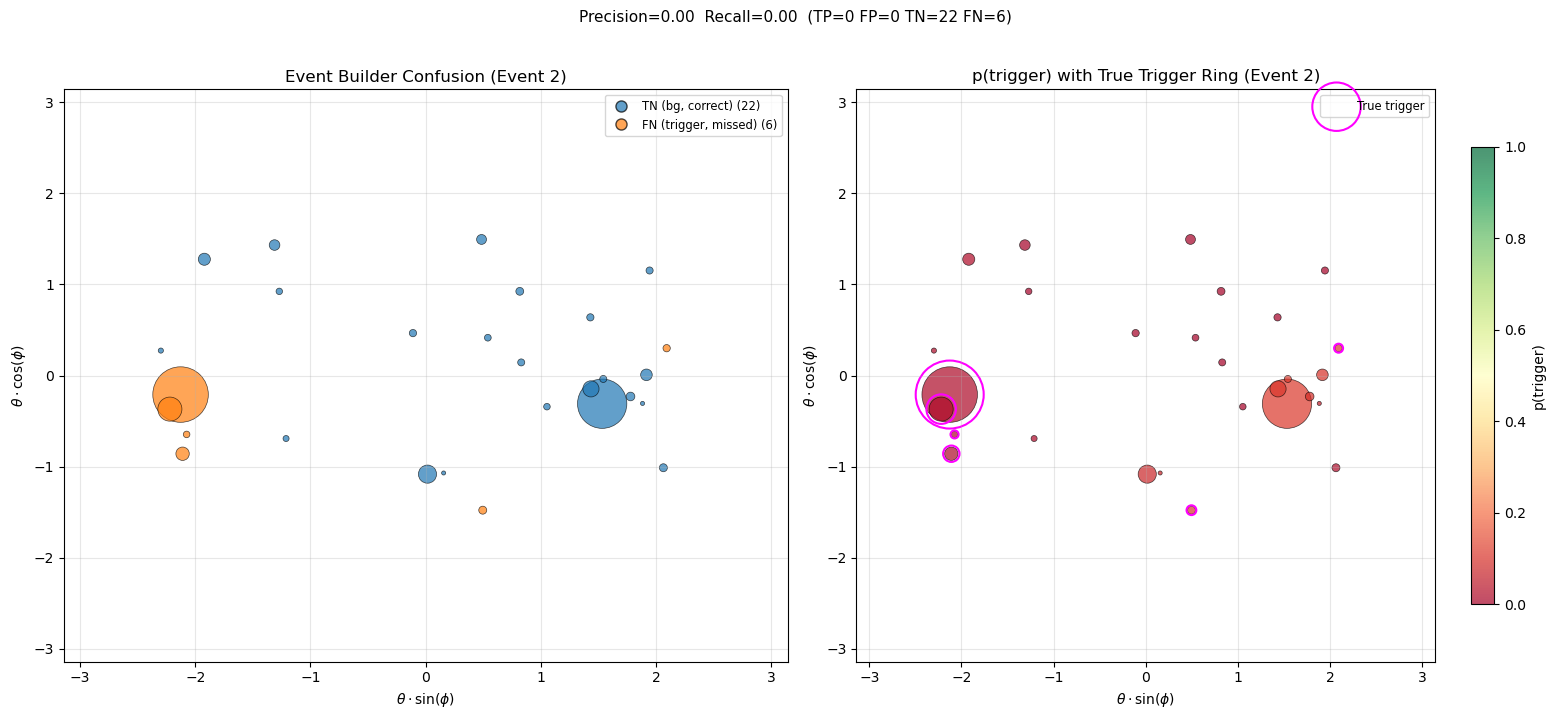

In [40]:
plot_event_builder_confusion(dataset, model, event_idx=2)

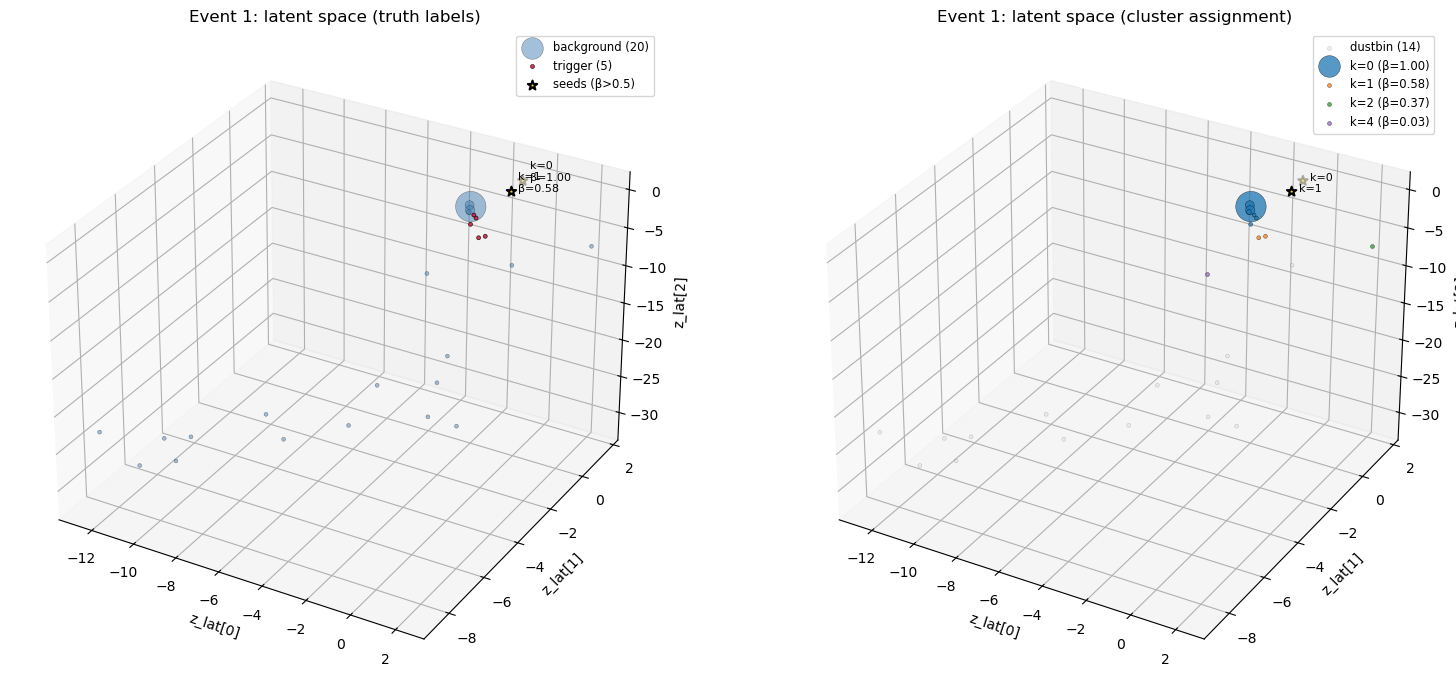


Latent space usage (Event 1):
  z_lat[0]: range [-12.51, +2.18]  std=3.94
  z_lat[1]: range [-8.65, +1.56]  std=2.84
  z_lat[2]: range [-31.56, +0.01]  std=12.17
  Singular values: [63.   17.49  3.96]  (ratio s1/s2=3.6, s1/s3=15.9)
  Effective rank (variance ratio s_i²/s_max²): [1.    0.077 0.004]

Latent space summary (Event 1):
  Hit latent norms: min=1.63  max=32.16  mean=15.53  std=12.19
  Seed-seed latent distances:
    k0 ↔ k1: 1.066
  Trigger-hit → seed latent distances:
    hit 0: k0=3.60  k1=3.53
    hit 1: k0=3.72  k1=3.62
    hit 2: k0=2.61  k1=2.54
    hit 3: k0=2.71  k1=2.65
    hit 4: k0=3.12  k1=3.03


In [19]:
plot_lyso_latent_space(dataset, model, event_idx=1)


Pion Trigger:    mean P=0.994, correct (>0.5): 992/997 (99.5%)
Pion Background: mean P=0.047, correct (<0.5): 128/134 (95.5%)
Muon Trigger:    mean P=0.990, correct (>0.5): 958/966 (99.2%)
Muon Background: mean P=0.048, correct (<0.5): 116/122 (95.1%)
MIP Trigger:    mean P=0.977, correct (>0.5): 820/823 (99.6%)
MIP Background: mean P=0.100, correct (<0.5): 135/150 (90.0%)


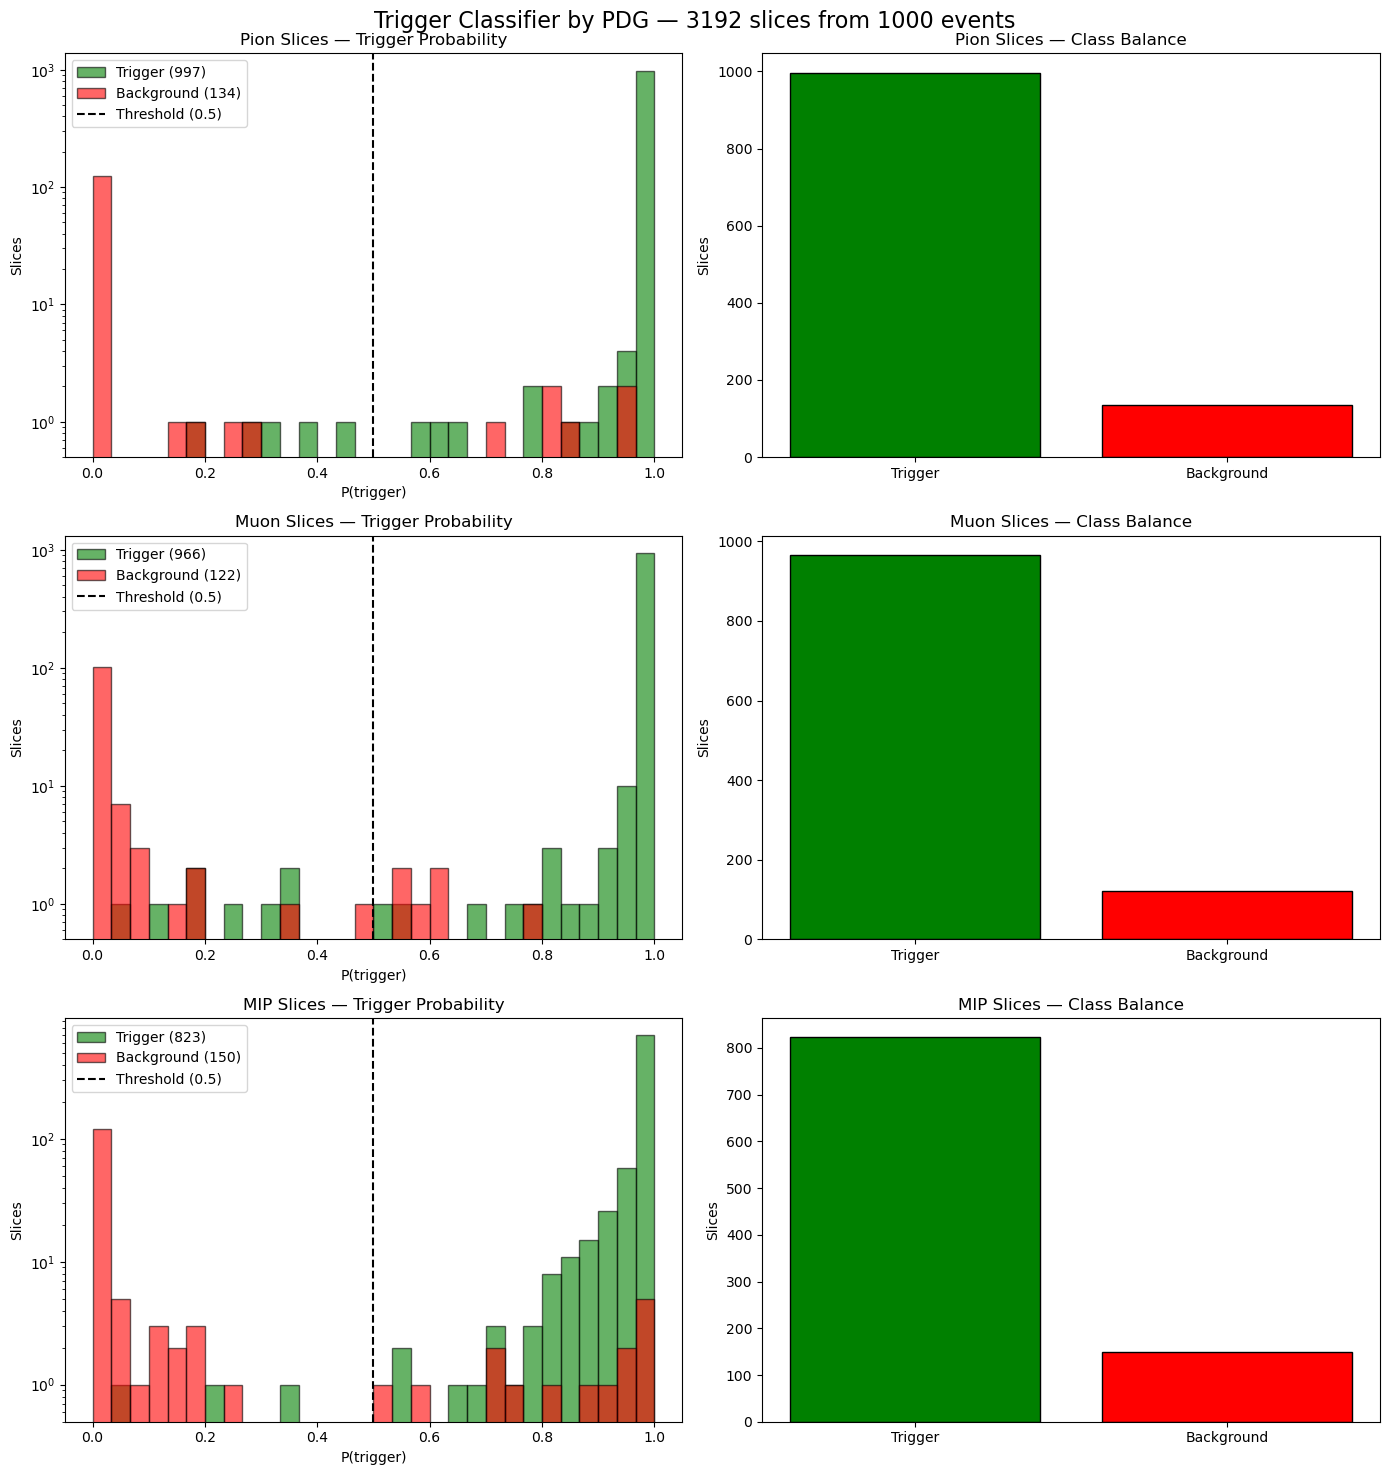

In [37]:
plot_trigger_distributions_by_pdg(dataset, model, n_events=1000)

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

def plot_theta_error(dataset, model, device='cuda', batch_size=12):
    model.train()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    diffs = []
    tw = {'w_atar_trigger_slice': 1.0, 'w_pion_kinematics': 1.0, 'w_positron_angle': 1.0}
    
    i = 0
    with torch.no_grad():
        for batch in loader:
            i+=1
            if i > 100:
                continue
            batch = batch.to(device)
            outputs = model(batch.x, batch.batch, task_weights=tw)
            
            if 'atar_positron_dir' not in outputs:
                continue
            
            has_pos = batch.has_trigger_positron.bool()
            if not has_pos.any():
                continue
            
            pred_dirs = outputs['atar_positron_dir'][has_pos]
            tar_dirs = format_targets_from_batch(batch)['tar_angle_vec_per_graph'][has_pos]
            
            # Theta from z-component (all on GPU until .cpu())
            pred_theta = torch.acos(pred_dirs[:, 2].div(pred_dirs.norm(dim=1).clamp(min=1e-9)).clamp(-1, 1))
            truth_theta = torch.acos(tar_dirs[:, 2].clamp(-1, 1))
            
            diff_deg = (truth_theta - pred_theta).rad2deg().cpu().numpy()
            diffs.append(diff_deg)
    
    diffs = np.concatenate(diffs)
    rms = np.sqrt(np.mean(diffs**2))
    mean = np.mean(diffs)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(diffs, bins=np.arange(-120, 120, 2), color='steelblue',
            label=f'RMS: {rms:.2f} deg\nMean: {mean:.2f} deg')
    ax.set_yscale('log')
    ax.set_xlabel('Truth - Prediction Theta [deg]')
    ax.set_ylabel('Counts')
    ax.set_title('Histogram of Theta Differences (Truth - Predicted)')
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Events plotted: {len(diffs)}")



/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


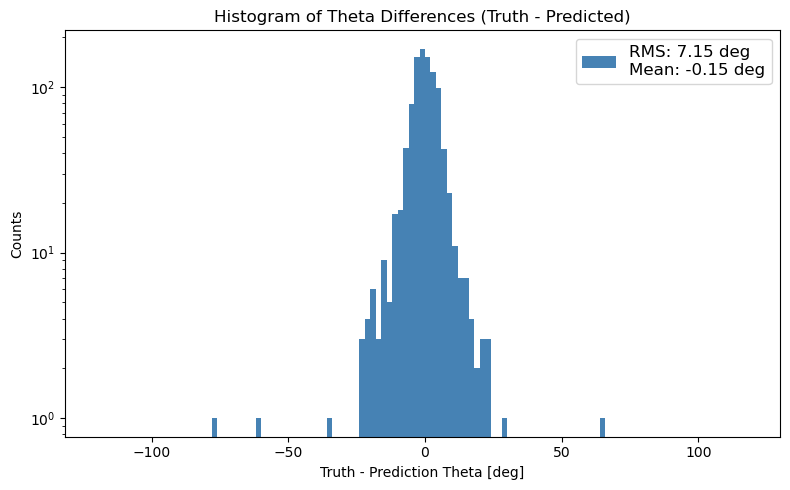

Events plotted: 988


In [42]:
plot_theta_error(dataset, model)

In [ ]:
from torch_geometric.data import Batch

def debug_event_builder(model, dataset, n_events=50):
    """
    Visualize event builder performance for both ATAR slices and LYSO clusters.

    ATAR: each valid slice gets one probability token. Hit-level targets are majority-voted per slice.
    LYSO: each graph gets K cluster tokens. Hit effective probability = sum_k(assignment_k * p_k).
          True label = is_trigger_target for LYSO hits (positrons fire LYSO, so trigger=1 for signal).
    """
    model.eval()

    # ATAR slice collections
    all_p_atar_trigger = []
    all_p_atar_bg = []
    all_atar_trigger_counts = []
    all_atar_bg_counts = []

    # LYSO hit-level collections (effective probability via soft assignment)
    all_p_lyso_trigger = []
    all_p_lyso_bg = []

    with torch.no_grad():
        for i in range(n_events):
            data = dataset[i].to(device)
            batch = Batch.from_data_list([data])
            outputs = model(batch.x, batch.batch, task_weights={
                'w_node_pdg': 1.0, 'w_endpoints': 1.0,
                'w_lyso_condensation': 0.25, 'w_event_builder': 1.0
            })

            if 'unified_event_logits' not in outputs:
                continue

            p = torch.sigmoid(outputs['unified_event_logits'].squeeze(-1))
            trigger_targets = batch.is_trigger_target  # [N_total_hits]

            is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
            is_lyso = (batch.x[:, 7] > 0.5)

            num_atar_tokens = outputs['unified_num_atar_tokens']
            p_atar = p[:num_atar_tokens]
            p_lyso_flat = p[num_atar_tokens:]  # [num_lyso_graphs * K]

            # -------------------------------------------------------
            # ATAR: map hit-level targets -> slice-level via majority vote
            # -------------------------------------------------------
            num_slices_max = outputs['num_slices_max']
            valid_mask = outputs['valid_slice_mask']
            atar_targets = trigger_targets[is_atar]

            global_ids = batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 8].long()
            mapped = (torch.cumsum(valid_mask.long(), 0) - 1)[global_ids]
            hit_valid = valid_mask[global_ids]

            n_valid = valid_mask.sum().item()
            slice_target_sum = torch.zeros(n_valid, device=device)
            slice_target_cnt = torch.zeros(n_valid, device=device)
            slice_target_sum.index_add_(0, mapped[hit_valid], atar_targets[hit_valid].float())
            slice_target_cnt.index_add_(0, mapped[hit_valid], torch.ones(hit_valid.sum(), device=device))
            slice_is_trigger = (slice_target_sum / slice_target_cnt.clamp(min=1)) > 0.5

            p_atar_np = p_atar.cpu().numpy()
            trig_np = slice_is_trigger.cpu().numpy()

            all_p_atar_trigger.extend(p_atar_np[trig_np].tolist())
            all_p_atar_bg.extend(p_atar_np[~trig_np].tolist())
            all_atar_trigger_counts.append(trig_np.sum())
            all_atar_bg_counts.append((~trig_np).sum())

            # -------------------------------------------------------
            # LYSO: effective hit probability via soft assignment
            # -------------------------------------------------------
            lyso_assignments = outputs.get('lyso_soft_assignments')  # [N_lyso_hits, K]
            if lyso_assignments is not None and is_lyso.any() and p_lyso_flat.numel() > 0:
                K = lyso_assignments.size(1)
                p_lyso_matrix = p_lyso_flat.view(-1, K)  # [num_lyso_graphs, K]

                lyso_batch = batch.batch[is_lyso]
                num_graphs = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
                graph_has_lyso = torch.zeros(num_graphs, dtype=torch.bool, device=lyso_batch.device)
                graph_has_lyso[lyso_batch] = True
                mapped_g = (torch.cumsum(graph_has_lyso.long(), 0) - 1)[lyso_batch]

                # Effective p per LYSO hit: weighted average over K clusters
                p_lyso_per_hit = (lyso_assignments * p_lyso_matrix[mapped_g]).sum(dim=1)
                lyso_true = trigger_targets[is_lyso]

                p_lyso_np = p_lyso_per_hit.cpu().numpy()
                lt_np = lyso_true.cpu().numpy().astype(bool)

                all_p_lyso_trigger.extend(p_lyso_np[lt_np].tolist())
                all_p_lyso_bg.extend(p_lyso_np[~lt_np].tolist())

    # -------------------------------------------------------
    # Print summary
    # -------------------------------------------------------
    print("=== ATAR Slices ===")
    if all_p_atar_trigger:
        print(f"  Trigger tokens   : {len(all_p_atar_trigger):4d}  mean p = {np.mean(all_p_atar_trigger):.3f}")
    else:
        print("  Trigger tokens   :    0")
    if all_p_atar_bg:
        print(f"  Background tokens: {len(all_p_atar_bg):4d}  mean p = {np.mean(all_p_atar_bg):.3f}")
    else:
        print("  Background tokens:    0")
    print(f"  Avg trigger slices/event : {np.mean(all_atar_trigger_counts):.1f}")
    print(f"  Avg bg slices/event      : {np.mean(all_atar_bg_counts):.1f}")
    print()
    print("=== LYSO Clusters (hit-level effective p) ===")
    if all_p_lyso_trigger:
        print(f"  Trigger hits   : {len(all_p_lyso_trigger):4d}  mean p = {np.mean(all_p_lyso_trigger):.3f}")
    else:
        print("  Trigger hits   :    0  (no pileup in sample?)")
    if all_p_lyso_bg:
        print(f"  Background hits: {len(all_p_lyso_bg):4d}  mean p = {np.mean(all_p_lyso_bg):.3f}")
    else:
        print("  Background hits:    0")

    # -------------------------------------------------------
    # Plot
    # -------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Event Builder Debug', fontsize=14)

    # ATAR distributions
    axes[0, 0].hist(all_p_atar_trigger, bins=20, alpha=0.7, label='Trigger', color='green')
    axes[0, 0].hist(all_p_atar_bg,      bins=20, alpha=0.7, label='Background', color='red')
    axes[0, 0].set_xlabel('P(trigger)')
    axes[0, 0].set_title('ATAR Slice Probabilities')
    axes[0, 0].legend()

    axes[0, 1].bar(['Trigger', 'Background'],
                   [len(all_p_atar_trigger), len(all_p_atar_bg)],
                   color=['green', 'red'], alpha=0.7)
    axes[0, 1].set_title('ATAR Class Balance')

    # LYSO distributions
    if all_p_lyso_trigger or all_p_lyso_bg:
        axes[1, 0].hist(all_p_lyso_trigger, bins=20, alpha=0.7, label='Trigger', color='green')
        axes[1, 0].hist(all_p_lyso_bg,      bins=20, alpha=0.7, label='Background', color='red')
        axes[1, 0].set_xlabel('Effective P(trigger) via soft assignment')
        axes[1, 0].set_title('LYSO Hit Probabilities')
        axes[1, 0].legend()

        axes[1, 1].bar(['Trigger', 'Background'],
                       [len(all_p_lyso_trigger), len(all_p_lyso_bg)],
                       color=['green', 'red'], alpha=0.7)
        axes[1, 1].set_title('LYSO Class Balance')
    else:
        axes[1, 0].text(0.5, 0.5, 'No LYSO data\n(no pileup events in sample)',
                        ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('LYSO Hit Probabilities')
        axes[1, 1].set_visible(False)

    plt.tight_layout()
    plt.show()


/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Trigger tokens: 141, mean p = 0.949
Background tokens: 26, mean p = 0.096
Avg trigger slices/event: 2.8
Avg bg slices/event: 0.5


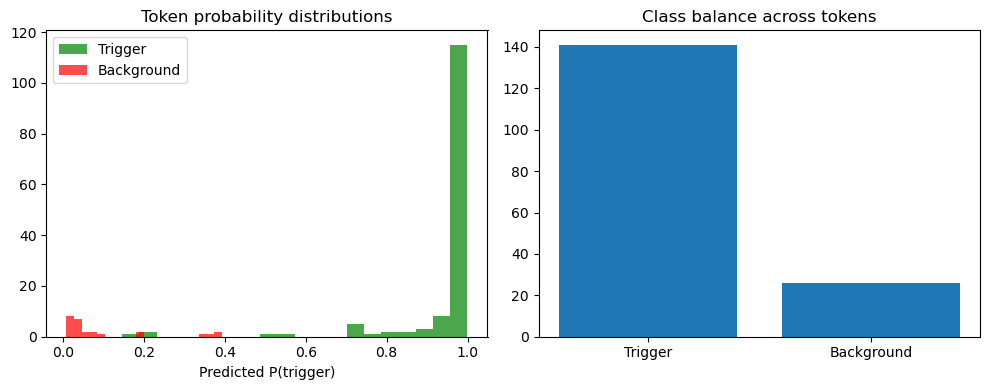

In [ ]:
debug_event_builder(model, dataset)


In [ ]:
def plot_event_builder_performance(batch, outputs, targets, g_idx=0):
    # ---------------------------
    # Extract Raw Probabilities
    # ---------------------------
    event_logits = outputs['unified_event_logits'].squeeze(-1)
    p_tokens = torch.sigmoid(event_logits)
    
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    p_atar = p_tokens[:num_atar_tokens]
    p_lyso = p_tokens[num_atar_tokens:]
    
    # ---------------------------
    # ATAR Hit-Level Probabilities
    # ---------------------------
    is_atar = (batch.x[:, 5] == 0) | (batch.x[:, 5] == 1)
    atar_mask_g = is_atar & (batch.batch == g_idx)
    
    valid_slice_mask = outputs['valid_slice_mask']
    num_slices_max = outputs['num_slices_max']
    
    global_slice_ids = batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 6].long()
    mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
    
    # Vectorized probability extraction
    hit_valid = valid_slice_mask[global_slice_ids]
    idx_in_p = mapped_slice_indices[global_slice_ids]
    
    atar_probs = torch.zeros(is_atar.sum(), device=p_tokens.device)
    atar_probs[hit_valid] = p_atar[idx_in_p[hit_valid]]
    
    # Extract specifically for graph g_idx
    local_atar_mask = (batch.batch[is_atar] == g_idx)
    g_atar_probs = atar_probs[local_atar_mask].detach().cpu().numpy()
    g_atar_true = targets['is_trigger'][is_atar][local_atar_mask].detach().cpu().numpy()
    
    g_atar_x = batch.x[atar_mask_g, 0].cpu().numpy() * 10
    g_atar_y = batch.x[atar_mask_g, 1].cpu().numpy() * 10
    g_atar_z = batch.x[atar_mask_g, 2].cpu().numpy() * 10 
    g_atar_e = batch.x[atar_mask_g, 3].cpu().numpy()
    g_atar_view = batch.x[atar_mask_g, 5].cpu().numpy() # 0=XZ, 1=YZ
    
    # ---------------------------
    # LYSO Hit-Level Probabilities
    # ---------------------------
    is_lyso = (batch.x[:, 5] == 2)
    lyso_mask_g = is_lyso & (batch.batch == g_idx)
    
    lyso_assignments = outputs.get('lyso_soft_assignments')
    K = lyso_assignments.size(1)
    p_lyso_matrix = p_lyso.view(-1, K)
    
    lyso_batch = batch.batch[is_lyso]
    num_graphs_in_batch = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
    graph_has_lyso = torch.zeros(num_graphs_in_batch, dtype=torch.bool, device=lyso_batch.device)
    graph_has_lyso[lyso_batch] = True
    mapped_graph_indices = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
    
    # Multiply soft assignments by target cluster probs
    hit_cluster_probs = p_lyso_matrix[mapped_graph_indices[lyso_batch]] # [N_lyso, K]
    lyso_probs = (lyso_assignments * hit_cluster_probs).sum(dim=1)      # [N_lyso]
    
    local_lyso_mask = (batch.batch[is_lyso] == g_idx)
    g_lyso_probs = lyso_probs[local_lyso_mask].detach().cpu().numpy()
    g_lyso_true = targets['is_trigger'][is_lyso][local_lyso_mask].detach().cpu().numpy()
    
    g_lyso_x = batch.x[lyso_mask_g, 0].cpu().numpy() * 100
    g_lyso_y = batch.x[lyso_mask_g, 1].cpu().numpy() * 100
    g_lyso_z = batch.x[lyso_mask_g, 2].cpu().numpy() * 100
    g_lyso_e = batch.x[lyso_mask_g, 3].cpu().numpy() * 70
    
    # ---------------------------
    # Plotting Logic
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    def get_color(prob, true_label):
        pred_label = prob > 0.5
        if pred_label and true_label: return '#2ca02c'     # Green: True Positive
        if not pred_label and not true_label: return '#7f7f7f' # Gray: True Negative
        if pred_label and not true_label: return '#d62728'      # Red: False Positive
        if not pred_label and true_label: return '#1f77b4'     # Blue: False Negative
        return 'black'
    
    # Vectorized color generation
    atar_colors = np.array([get_color(p, t) for p, t in zip(g_atar_probs, g_atar_true)])
    lyso_colors = np.array([get_color(p, t) for p, t in zip(g_lyso_probs, g_lyso_true)])
    
    # Marker sizes visually relative to energy
    base_size = 200
    atar_sizes = g_atar_e * base_size + 10
    lyso_sizes = g_lyso_e * base_size/10 + 10
    
    # 1. ATAR XZ
    ax_xz = axes[0]
    mask_xz = (g_atar_view == 0)
    ax_xz.scatter(g_atar_z[mask_xz], g_atar_x[mask_xz], c=atar_colors[mask_xz], s=atar_sizes[mask_xz], alpha=0.8, edgecolors='none')
    ax_xz.set_title(f"ATAR XZ View (Event Builder) - Graph {g_idx}", fontsize=14)
    ax_xz.set_xlabel("Z (mm)")
    ax_xz.set_ylabel("X (mm)")
    ax_xz.grid(True, alpha=0.3)
    ax_xz.set_xlim(-0.5, 7.5); ax_xz.set_ylim(-11.5, 11.5)
    
    # 2. ATAR YZ
    ax_yz = axes[1]
    mask_yz = (g_atar_view == 1)
    ax_yz.scatter(g_atar_z[mask_yz], g_atar_y[mask_yz], c=atar_colors[mask_yz], s=atar_sizes[mask_yz], alpha=0.8, edgecolors='none')
    ax_yz.set_title(f"ATAR YZ View (Event Builder) - Graph {g_idx}", fontsize=14)
    ax_yz.set_xlabel("Z (mm)")
    ax_yz.set_ylabel("Y (mm)")
    ax_yz.grid(True, alpha=0.3)
    ax_yz.set_xlim(-0.5, 7.5); ax_yz.set_ylim(-11.5, 11.5)
    
    # 3. LYSO Projection
    ax_lyso = axes[2]
    # Theta / Phi angular mapping logic
    r_lyso = np.sqrt(g_lyso_x**2 + g_lyso_y**2 + g_lyso_z**2) + 1e-6
    theta_lyso = np.arccos(g_lyso_z / r_lyso)
    phi_lyso = np.arctan2(g_lyso_y, g_lyso_x)
    
    proj_x = theta_lyso * np.cos(phi_lyso)
    proj_y = theta_lyso * np.sin(phi_lyso)
    
    ax_lyso.scatter(proj_x, proj_y, c=lyso_colors, s=lyso_sizes, alpha=0.8, edgecolors='k', linewidth=0.5)
    ax_lyso.set_title("Calorimeter Angular Projection", fontsize=14)
    ax_lyso.set_xlabel("Theta * Cos(Phi)")
    ax_lyso.set_ylabel("Theta * Sin(Phi)")
    ax_lyso.grid(True, alpha=0.3)
    ax_lyso.set_xlim(-np.pi, np.pi)
    ax_lyso.set_ylim(-np.pi, np.pi)
    
    # Confusion Matrix Semantic Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#2ca02c', markersize=10, label='True Positive (Pred=Trigger, True=Trigger)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#7f7f7f', markersize=10, label='True Negative (Pred=Bkg, True=Bkg)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#d62728', markersize=10, label='False Positive (Pred=Trigger, True=Bkg)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#1f77b4', markersize=10, label='False Negative (Pred=Bkg, True=Trigger)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=4, frameon=False, fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [ ]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    targets = format_targets_from_batch(batch)
    outputs = model(batch.x, batch.batch)
    
    # Loop through any graphs you want!
    plot_event_builder_performance(batch, outputs, targets, g_idx=0)

RuntimeError: The size of tensor a (275) must match the size of tensor b (0) at non-singleton dimension 0

In [ ]:
def plot_effective_distance_from_highest_beta(batch, outputs, targets, g_idx=0, tau=1.0):
    is_lyso = (batch.x[:, 5] == 2)
    lyso_batch = batch.batch[is_lyso]
    local_lyso_mask = (lyso_batch == g_idx)
    
    if not local_lyso_mask.any():
        print(f"No LYSO hits in graph {g_idx}")
        return
        
    latent_coords = outputs['lyso_cluster_coords'][local_lyso_mask].detach().cpu().numpy()
    g_beta = outputs['lyso_beta'].squeeze(-1)[local_lyso_mask].detach().cpu().numpy()
    
    # Identify Radioactivity using the Fraction Target trick
    lyso_fracs = targets['tar_lyso_fracs']
    is_radio = (lyso_fracs.sum(dim=1) == 0.0)
    g_is_radio = is_radio[local_lyso_mask].detach().cpu().numpy()
    
    # Primary Seed
    max_beta_idx = np.argmax(g_beta)
    seed_latent = latent_coords[max_beta_idx]
    
    # 1. Raw Latent Distance
    raw_distances = np.sqrt(np.sum((latent_coords - seed_latent)**2, axis=1))
    
    # 2. Effective Latent Distance
    # We clip `g_beta` slightly above 0 strictly to prevent np.log(0) throwing an error
    safe_beta = np.clip(g_beta, 1e-5, 1.0)
    #effective_distances = raw_distances - (tau * np.log(safe_beta))
    effective_distances = raw_distances
    
    # Split into Radioactivity vs Physics
    radio_eff = effective_distances[g_is_radio]
    physics_eff = effective_distances[~g_is_radio]
    
    plt.figure(figsize=(10, 6))
    
    # Use tightly clustered bins to catch the runaway background
    bins = np.linspace(0, max(10.0, np.max(effective_distances)), 60)
    
    plt.hist([physics_eff, radio_eff], bins=bins,range=(0,5), stacked=False, 
             color=['#ff7f0e', 'gray'], label=['Signal & Trajectory Backgrounds', 'Intrinsic Radioactivity'],
             edgecolor='k', alpha=0.8)
    
    # Show exactly where the noise floor clamps down
    # noise_floor = 0.05 implies the cutoff effective distance is approx exactly tau * ln(1/0.05) ~ 3.0
    cutoff = -tau * np.log(0.05)
    plt.axvline(x=cutoff, color='red', linestyle='--', linewidth=2, label=f'Noise Floor Cutoff (d ~ {cutoff:.2f})')
    
    plt.title(f"Effective Spatial Distance from Primary LYSO Seed (Graph {g_idx})", fontsize=14)
    plt.xlabel("Effective Distance $d_{eff} = d - \\tau \ln(\\beta)$", fontsize=12)
    plt.ylabel("Number of LYSO Hits", fontsize=12)
    plt.legend(fontsize=11)
    
    # Hard limit the x-axis so the extreme beta=0 outliers don't crush the view
    plt.xlim(-0.2, 10)
    plt.grid(alpha=0.3)
    plt.show()

def plot_beta_distributions(batch, outputs, targets, g_idx=0):
    is_lyso = (batch.x[:, 5] == 2)
    lyso_batch = batch.batch[is_lyso]
    local_lyso_mask = (lyso_batch == g_idx)
    
    if not local_lyso_mask.any():
        print(f"No LYSO hits in graph {g_idx}")
        return
        
    # Extract predicted Beta scores
    g_beta = outputs['lyso_beta'].squeeze(-1)[local_lyso_mask].detach().cpu().numpy()
    
    # Identify Radioactivity
    lyso_fracs = targets['tar_lyso_fracs']
    is_radio = (lyso_fracs.sum(dim=1) == 0.0)
    g_is_radio = is_radio[local_lyso_mask].detach().cpu().numpy()
    
    # Split distributions
    radio_beta = g_beta[g_is_radio]
    physics_beta = g_beta[~g_is_radio]
    
    plt.figure(figsize=(10, 6))
    
    # Stacked Histogram
    plt.hist([physics_beta, radio_beta], bins=np.linspace(0, 1.0, 50), stacked=False, 
             color=['#ff7f0e', 'gray'], label=['Signal & Trajectory Backgrounds', 'Intrinsic Radioactivity'],
             edgecolor='k', alpha=0.8)
    
    plt.title(f"Predicted Beta Scores for Calorimeter Hits (Graph {g_idx})", fontsize=14)
    plt.xlabel("Predicted Condensation Score ($\\beta$)", fontsize=12)
    plt.ylabel("Number of LYSO Hits", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

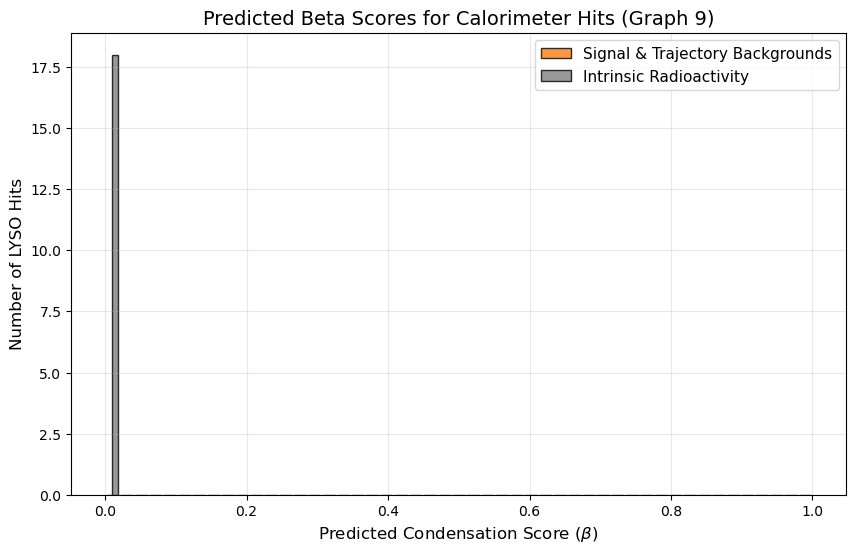

In [ ]:
plot_beta_distributions(batch, outputs, targets, g_idx=9)

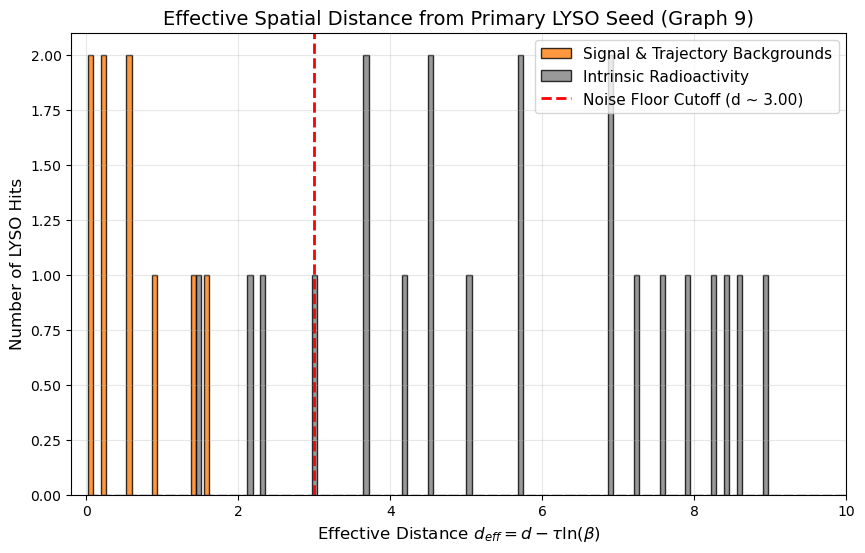

In [ ]:
plot_effective_distance_from_highest_beta(batch, outputs, targets, g_idx=9)

In [ ]:
def plot_calo_event_display(dataset_obj, model_obj, event_idx=0, threshold=0.5, dist_threshold=1.0):
    """
    Dual-panel calorimeter event display.
    Fixed: Legend marker sizes normalized. Radioactivity cannot form its own cluster.
    """
    # --- 1. Prepare Data and Model ---
    model_obj.train()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]
    row = dataset_obj.df.iloc[event_idx]
    
    # --- 2. Forward Pass ---
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_lyso_condensation': 1.0})
    # --- 3. Filter for LYSO Hits ---
    is_lyso_mask = (batch.x[:, 5] == 2).cpu().numpy()
    if not is_lyso_mask.any():
        print(f"No LYSO hits found for event {event_idx}")
        return
    x_orig = batch.x[is_lyso_mask, 0].cpu().numpy() * 100.0
    y_orig = batch.x[is_lyso_mask, 1].cpu().numpy() * 100.0
    z_orig = batch.x[is_lyso_mask, 2].cpu().numpy() * 100.0
    energy = batch.x[is_lyso_mask, 3].cpu().numpy() * 70.0
    times = batch.x[is_lyso_mask, 4].cpu().numpy() * 500.0
    
    r = np.sqrt(x_orig**2 + y_orig**2 + z_orig**2)
    theta = np.arccos(np.clip(z_orig / r, -1.0, 1.0))
    phi = np.arctan2(y_orig, x_orig)
    
    proj_x = theta * np.sin(phi)
    proj_y = theta * np.cos(phi)
    marker_sizes = np.maximum(energy * 50.0, 5.0)
    
    # Extract True Origins for radioactivity masking
    lyso_origins = np.array(row.get('lyso_origin', np.zeros(len(x_orig))))
    # --- 4. Get True Clustering ---
    if hasattr(batch, 'lyso_fracs_target'):
        y_fracs = batch.lyso_fracs_target.cpu().numpy()
        if y_fracs.max() > 0:
            true_clusters = np.argmax(y_fracs, axis=1)
            true_clusters[y_fracs.sum(axis=1) < 0.1] = -1
        else:
            true_clusters = np.full(len(x_orig), -1)
    else:
        true_clusters = np.full(len(x_orig), -1)
    # --- 5. Get Predicted Clustering ---
    pred_clusters = np.full(len(x_orig), -1)
    
    if 'lyso_beta' in outputs:
        pred_beta = outputs['lyso_beta'].detach().cpu().numpy().flatten()
        pred_coords = outputs['lyso_cluster_coords'].detach().cpu().numpy()
        
        sort_idx = np.argsort(pred_beta)[::-1]
        alphas = []
        alpha_ids = []
        cluster_id = 0
        
        for i in sort_idx:
            if pred_beta[i] > threshold:
                # NEW: Do not let radioactivity hits become cluster centers (Alphas)
                if lyso_origins[i] == -1:
                    continue
                    
                is_new_alpha = True
                for a_coord in alphas:
                    if np.linalg.norm(pred_coords[i] - a_coord) < dist_threshold:
                        is_new_alpha = False
                        break
                
                if is_new_alpha:
                    alphas.append(pred_coords[i])
                    alpha_ids.append(cluster_id)
                    cluster_id += 1
            else:
                break
                
        if len(alphas) > 0:
            dists = cdist(pred_coords, np.array(alphas)) 
            min_dist_idx = np.argmin(dists, axis=1)       
            min_dists = np.min(dists, axis=1)             
            
            valid_assignment = min_dists < dist_threshold
            pred_clusters[valid_assignment] = np.array(alpha_ids)[min_dist_idx[valid_assignment]]
    # --- 6. Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    cmap = plt.get_cmap('tab20')
    def draw_panel(ax, clusters, title):
        unique_ids = np.unique(clusters)
        handles, labels = [], []
        
        for i, cid in enumerate(unique_ids):
            mask = (clusters == cid)
            color = cmap(i % 20) if cid >= 0 else 'black'
            
            # --- New: Calculate Cluster Time ---
            if cid >= 0:
                t_avg = np.sum(times[mask] * energy[mask]) / np.sum(energy[mask])
                label = f'Cluster {cid} ({t_avg:.1f} ns)'
            else:
                label = 'Noise'
            
            # Plot the hits
            ax.scatter(proj_x[mask], proj_y[mask], s=marker_sizes[mask], 
                       color=color, alpha=0.7, edgecolors='black', linewidth=0.5)
            
            # Create legend entry
            dummy = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                               markeredgecolor='black', markersize=8, alpha=0.7)
            handles.append(dummy)
            labels.append(label)
        
        ax.set_title(title)
        ax.set_xlabel(r"$\theta \cdot \sin(\phi)$")
        ax.set_ylabel(r"$\theta \cdot \cos(\phi)$")
        ax.grid(alpha=0.3)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(-np.pi, np.pi)
        
        # Draw legend and force all markers to have the same size (e.g., 20)
        ax.legend(handles, labels, loc='best', fontsize='xx-small', frameon=True, ncol=2)
        #for handle in leg.legend_handles:
        #    handle.set_sizes([20.0])
    draw_panel(axes[0], pred_clusters, f"Predicted Clustering (Event {event_idx})")
    draw_panel(axes[1], true_clusters, f"True Clustering (Event {event_idx})")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_calo_event_display(dataset, model, event_idx=0, threshold=0.5, dist_threshold=0.75)

No LYSO hits found for event 0


In [ ]:
def plot_hit_trigger_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """
    Visualizes ATAR hits colored by hit-level Trigger Identification (Origin 0 vs Background).
    - Crimson: Correctly identified Trigger Hit (True Positive)
    - DodgerBlue: Correctly identified Background Hit (True Negative)
    - Black: Mistake (False Positive or False Negative)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from torch_geometric.loader import DataLoader
    import numpy as np
    import torch
    
    model_obj.train()
    data = dataset_obj[event_idx]
    device = next(model_obj.parameters()).device
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        # Ensure trigger weight is ON
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_hit_trigger': 1.0})
        targets = format_targets_from_batch(batch)
    if 'atar_hit_trigger' not in outputs:
        print("Model output did not contain 'atar_hit_trigger'. Check if w_atar_hit_trigger > 0.")
        return
    # 2. Extract Predictions and Targets (ATAR Hits only)
    pred_logits = outputs['atar_hit_trigger']
    pred_probs = torch.sigmoid(pred_logits).cpu().numpy()
    true_flags = targets['is_trigger'].cpu().numpy()
    
    pred_binary = (pred_probs > threshold).astype(float)
    is_correct = (pred_binary == true_flags)
    
    # 3. Geometry and Energy Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_view = np.array(row['atar_view'])
    
    # Scale sizes based on Energy
    atar_s = np.clip(5 + atar_E * 150, 5, 500)
    
    # Define colors for each ATAR hit
    hit_colors = []
    for i in range(len(atar_x)):
        # Ensure we don't index out of bounds if shapes differ
        if i >= len(is_correct):
            hit_colors.append('lightgray')
            continue
            
        correct = is_correct[i]
        is_trigger_true = true_flags[i] > 0.5
        
        if correct and is_trigger_true:
            hit_colors.append('crimson')    # TP: Trigger Hit found
        elif correct and not is_trigger_true:
            hit_colors.append('dodgerblue') # TN: Background Hit confirmed
        else:
            hit_colors.append('black')      # Error (FP/FN)
            
    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx}: Hit-Level Trigger Identification (Marker Size = Energy)', fontsize=16)
    
    # --- XZ View ---
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], 
                c=[hit_colors[i] for i, m in enumerate(mask_xz) if m], 
                s=atar_s[mask_xz], alpha=0.7)
    ax1.set_title("X-Z View"); ax1.set_xlabel("Z [mm]"); ax1.set_ylabel("X [mm]")
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5); ax1.grid(True, linestyle='--', alpha=0.4)
    
    # --- YZ View ---
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], 
                c=[hit_colors[i] for i, m in enumerate(mask_yz) if m], 
                s=atar_s[mask_yz], alpha=0.7)
    ax2.set_title("Y-Z View"); ax2.set_xlabel("Z [mm]"); ax2.set_ylabel("Y [mm]")
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5); ax2.grid(True, linestyle='--', alpha=0.4)
    
    # Legend
    handles = [
        mpatches.Patch(color='crimson', label='Correct Trigger Hit (TP)'),
        mpatches.Patch(color='dodgerblue', label='Correct Pileup/Radio Hit (TN)'),
        mpatches.Patch(color='black', label='Prediction Error (FP/FN)')
    ]
    ax1.legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()

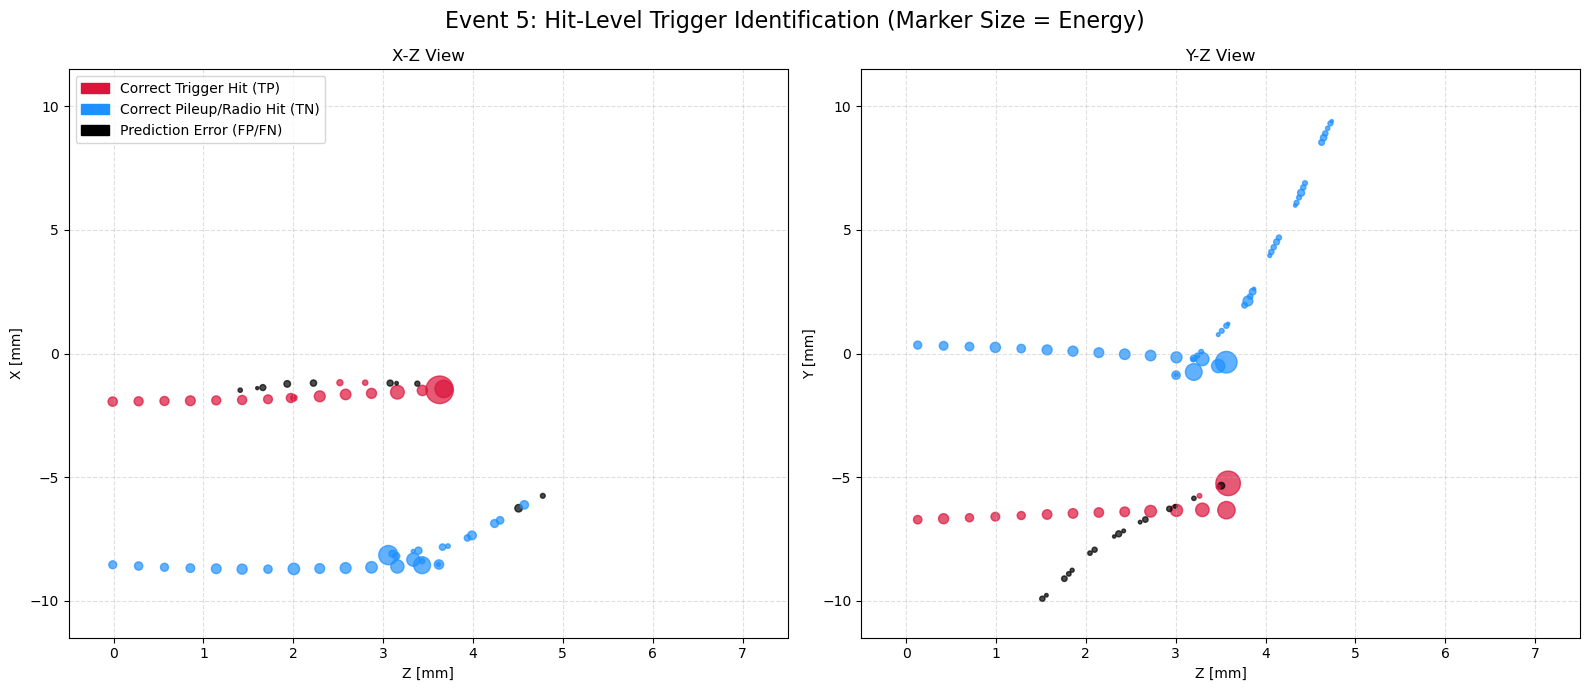

In [ ]:
plot_hit_trigger_debug(dataset, model, event_idx=5)

In [ ]:
def plot_multi_event_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """
    Visualizes ATAR hits with marker sizes scaled by energy.
    - Crimson: Correctly identified pileup (True Positive)
    - DodgerBlue: Correctly identified single-event (True Negative)
    - Black: Mistake (False Positive or False Negative)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from torch_geometric.loader import DataLoader
    import numpy as np
    import torch
    
    model_obj.train()
    data = dataset_obj[event_idx]
    device = next(model_obj.parameters()).device
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_slice_multi': 1.0})
        targets = format_targets_from_batch(batch)
    if 'atar_slice_multi' not in outputs:
        print("Model output did not contain 'atar_slice_multi'. Check if w_atar_slice_multi > 0.")
        return
    # 2. Extract Predictions and Targets
    pred_logits = outputs['atar_slice_multi']
    pred_probs = torch.sigmoid(pred_logits).cpu().numpy()
    true_flags = targets['atar_slice_multi_target'].cpu().numpy()
    
    # Align lengths if model filters slices
    if len(true_flags) > len(pred_probs):
        true_flags = true_flags[:len(pred_probs)] 
    
    pred_binary = (pred_probs > threshold).astype(float)
    is_correct = (pred_binary == true_flags)
    
    # 3. Geometry and Energy Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_view = np.array(row['atar_view'])
    atar_slice = np.array(row['atar_slice'])
    unique_slices = np.unique(atar_slice)[:len(pred_probs)]
    
    # Scale sizes based on Energy (from your original logic)
    atar_s = np.clip(5 + atar_E * 150, 5, 500)
    
    # Map slice results to hit colors
    hit_colors = []
    for s in atar_slice:
        s_matches = np.where(unique_slices == s)[0]
        if len(s_matches) == 0:
            hit_colors.append('lightgray')
            continue
        
        s_idx = s_matches[0]
        correct = is_correct[s_idx]
        is_multi = true_flags[s_idx] > 0.5
        
        if correct and is_multi:
            hit_colors.append('crimson')
        elif correct and not is_multi:
            hit_colors.append('dodgerblue')
        else:
            hit_colors.append('black')
            
    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
    fig.suptitle(f'Event {event_idx}: Multi-Event Tagger Debug (Marker Size = Energy)', fontsize=16)
    
    # --- XZ View ---
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], 
                c=[hit_colors[i] for i, m in enumerate(mask_xz) if m], 
                s=atar_s[mask_xz], alpha=0.7)
    ax1.set_title("X-Z View"); ax1.set_xlabel("Z [mm]"); ax1.set_ylabel("X [mm]")
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5); ax1.grid(True, linestyle='--', alpha=0.4)
    
    # --- YZ View ---
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], 
                c=[hit_colors[i] for i, m in enumerate(mask_yz) if m], 
                s=atar_s[mask_yz], alpha=0.7)
    ax2.set_title("Y-Z View"); ax2.set_xlabel("Z [mm]"); ax2.set_ylabel("Y [mm]")
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5); ax2.grid(True, linestyle='--', alpha=0.4)
    
    # --- Score Chart ---
    ax3.bar(range(len(pred_probs)), pred_probs, color='gray', alpha=0.3, label='Pred Probability')
    ax3.scatter(range(len(true_flags)), true_flags, color='red', marker='x', s=60, label='True Flag')
    ax3.axhline(threshold, color='black', linestyle='--', alpha=0.4, label='Threshold')
    ax3.set_title("Slice Scores"); ax3.set_xlabel("Slice Index"); ax3.set_ylabel("Prob")
    ax3.set_ylim(-0.05, 1.05); ax3.legend()
    
    # Legend
    handles = [
        mpatches.Patch(color='crimson', label='Correct Pileup (TP)'),
        mpatches.Patch(color='dodgerblue', label='Correct Signal (TN)'),
        mpatches.Patch(color='black', label='Error (FP/FN)')
    ]
    ax1.legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()
# Usage:
# plot_multi_event_debug(dataset, model, event_idx=5)

In [ ]:
failure_indices = []
threshold = 0.5
num_to_scan = 2000  # Number of events to check
model.eval()
with torch.no_grad():
    print(f"Scanning first {num_to_scan} events for failures...")
    for i in tqdm(range(min(len(dataset), num_to_scan))):
        data = dataset[i]
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        
        # Ensure the head is active
        outputs = model(batch.x, batch.batch, task_weights={'w_atar_slice_multi': 1.0})
        targets = format_targets_from_batch(batch)
        
        if 'atar_slice_multi' in outputs:
            pred_probs = torch.sigmoid(outputs['atar_slice_multi'])
            pred_binary = (pred_probs > threshold).float()
            true_flags = targets['atar_slice_multi_target']
            
            # Align lengths if the model filters slices (stereo-only mode)
            true_flags = true_flags[:pred_binary.shape[0]]
            
            # If any slice in the event is wrong, record the index
            if not torch.equal(pred_binary, true_flags):
                failure_indices.append(i)
print(f"Done. Found {len(failure_indices)} failure events.")
print("Indices to inspect:", failure_indices)

Scanning first 2000 events for failures...


  0%|          | 0/2000 [00:00<?, ?it/s]/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103814636/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 2000/2000 [01:29<00:00, 22.44it/s]

Done. Found 14 failure events.
Indices to inspect: [374, 459, 643, 825, 1001, 1014, 1090, 1147, 1163, 1364, 1402, 1415, 1685, 1958]


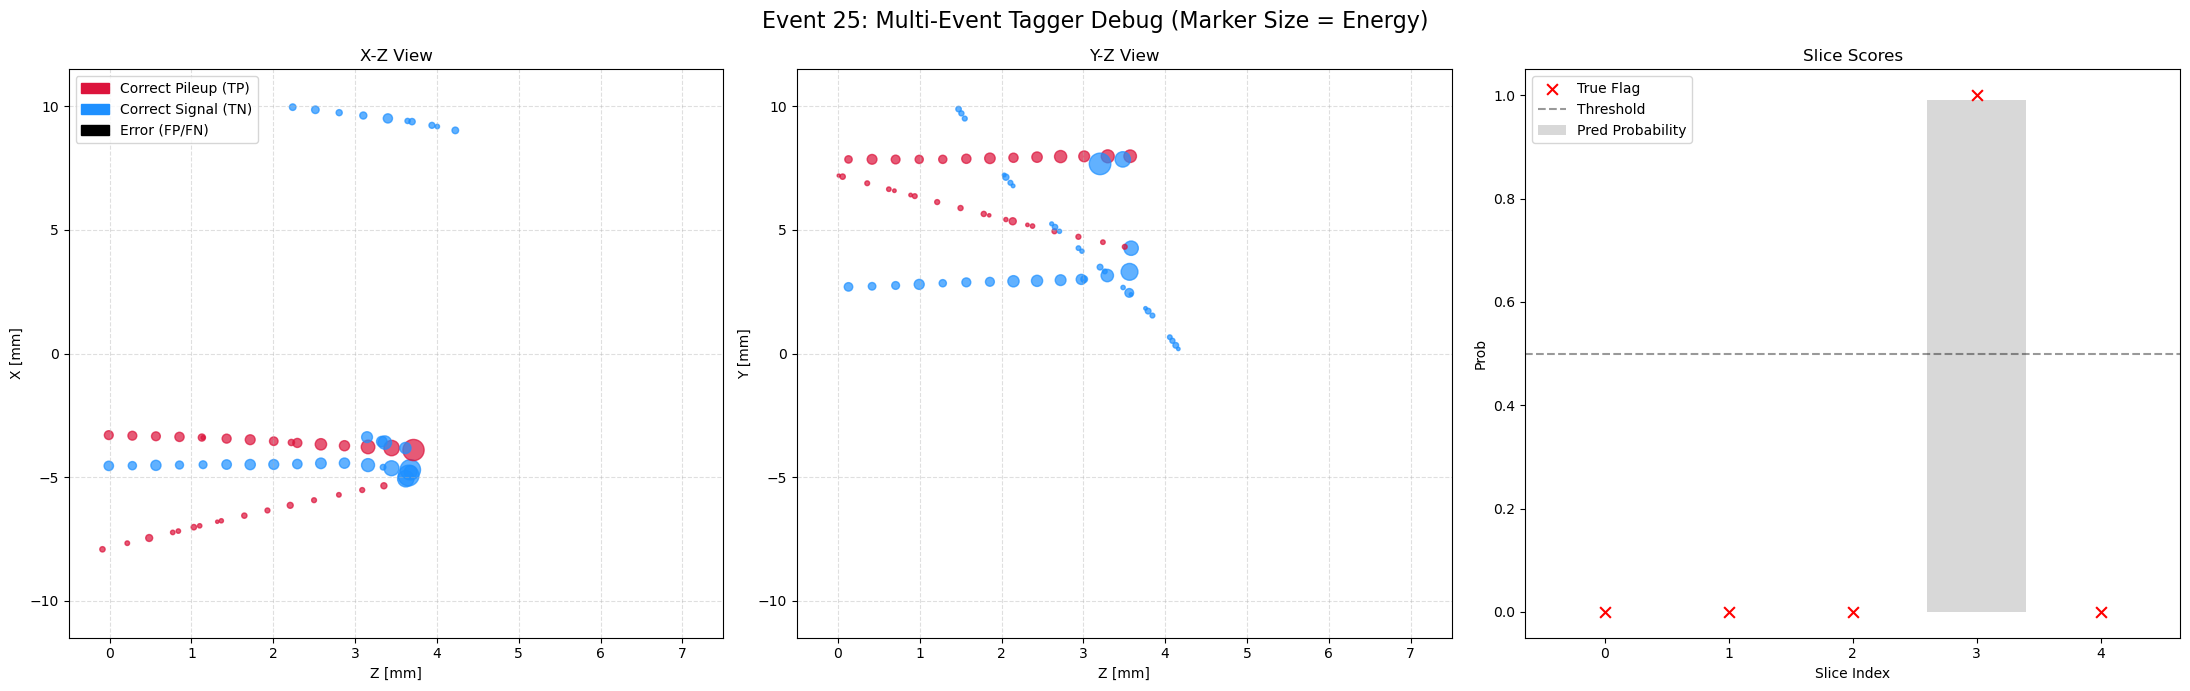

In [ ]:
plot_multi_event_debug(dataset, model, event_idx=25)

In [ ]:
def plot_endpoints_debug(dataset_obj, model_obj, event_idx=0):
    model_obj.train()
    data = dataset_obj[event_idx]
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0})
        targets = format_targets_from_batch(batch)
    
    # 2. Geometry Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    
    # 3. Validation Check
    num_slices = len(targets.get('tar_slice_start_x', []))
    if num_slices == 0:
        print("No endpoint targets generated for this event.")
        return
        
    if 'atar_endpoints' not in outputs or len(outputs['atar_endpoints']) == 0:
        print("Model failed to output any endpoints.")
        return
        
    # 4. Node Splitting Prediction (For Graph Coloring)
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    color_map = {0: 'red', 1: 'blue', 2: 'green'} # Pion=Red, Muon=Blue, MIP=Green
    hit_colors = [color_map[c] for c in pred_node_classes]
    
    handles = [
        mpatches.Patch(color='red', label='Pred Pion'),
        mpatches.Patch(color='blue', label='Pred Muon'),
        mpatches.Patch(color='green', label='Pred MIP')
    ]
    
    # 5. Plot XZ and YZ views
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} ATAR Endpoint Regression ({num_slices} Tracks)', fontsize=16)
    
    # --- XZ Projection ---
    mask_xz = (atar_view == 0)
    colors_xz = [hit_colors[i] for i, m in enumerate(mask_xz) if m]
    sizes_xz = atar_s[mask_xz]
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], c=colors_xz, s=sizes_xz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    
    # --- YZ Projection ---
    mask_yz = (atar_view == 1)
    colors_yz = [hit_colors[i] for i, m in enumerate(mask_yz) if m]
    sizes_yz = atar_s[mask_yz]
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], c=colors_yz, s=sizes_yz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    
    # --- Loop Over All Tracks ---
    for s in range(num_slices):
        true_start_x, true_start_y, true_start_z = targets['tar_slice_start_x'][s].item(), targets['tar_slice_start_y'][s].item(), targets['tar_slice_start_z'][s].item()
        true_stop_x, true_stop_y, true_stop_z = targets['tar_slice_stop_x'][s].item(), targets['tar_slice_stop_y'][s].item(), targets['tar_slice_stop_z'][s].item()
        
        pred_start_x = outputs['atar_endpoints'][s, 0, 0, 1].item() * 10.0
        pred_start_y = outputs['atar_endpoints'][s, 0, 1, 1].item() * 10.0
        pred_start_z = outputs['atar_endpoints'][s, 0, 2, 1].item() * 10.0
        
        pred_stop_x = outputs['atar_endpoints'][s, 1, 0, 1].item() * 10.0
        pred_stop_y = outputs['atar_endpoints'][s, 1, 1, 1].item() * 10.0
        pred_stop_z = outputs['atar_endpoints'][s, 1, 2, 1].item() * 10.0
        # Only label the very first slice so we don't spam the legend
        t_label_start = 'True Start' if s == 0 else None
        t_label_stop = 'True Stop' if s == 0 else None
        p_label_start = 'Pred Start' if s == 0 else None
        p_label_stop = 'Pred Stop' if s == 0 else None
        # XZ
        ax1.scatter([true_start_z*10], [true_start_x*10], c='limegreen', marker='x', s=100, label=t_label_start)
        ax1.scatter([true_stop_z*10], [true_stop_x*10], c='limegreen', marker='x', s=100, label=t_label_stop)
        ax1.scatter([pred_start_z], [pred_start_x], c='black', marker='x', s=100, linewidth=1, label=p_label_start)
        ax1.scatter([pred_stop_z], [pred_stop_x], c='black', marker='x', s=100, linewidth=1, label=p_label_stop)
        ax1.plot([true_start_z*10, true_stop_z*10], [true_start_x*10, true_stop_x*10], c='limegreen', linestyle='--', alpha=0.8)
        ax1.plot([pred_start_z, pred_stop_z], [pred_start_x, pred_stop_x], c='black', linestyle=':', alpha=0.8)
        # YZ
        ax2.scatter([true_start_z*10], [true_start_y*10], c='limegreen', marker='x', s=100, label=t_label_start)
        ax2.scatter([true_stop_z*10], [true_stop_y*10], c='limegreen', marker='x', s=100, label=t_label_stop)
        ax2.scatter([pred_start_z], [pred_start_y], c='black', marker='x', s=100, linewidth=1, label=p_label_start)
        ax2.scatter([pred_stop_z], [pred_stop_y], c='black', marker='x', s=100, linewidth=1, label=p_label_stop)
        ax2.plot([true_start_z*10, true_stop_z*10], [true_start_y*10, true_stop_y*10], c='limegreen', linestyle='--', alpha=0.8)
        ax2.plot([pred_start_z, pred_stop_z], [pred_start_y, pred_stop_y], c='black', linestyle=':', alpha=0.8)

        print(true_start_z*10, true_stop_z*10, pred_start_z, pred_stop_z)
    
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-13.5, 13.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(handles=handles + ax1.get_legend_handles_labels()[0][1:])
    ax1.set_title("X-Z Projection")
    
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-13.5, 13.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(handles=handles + ax2.get_legend_handles_labels()[0][1:])
    ax2.set_title("Y-Z Projection")

    atar_t = np.array(row['atar_t'])
    atar_slice_ids = np.array(row['atar_slice']) if 'atar_slice' in row else np.zeros_like(atar_t)
    unique_slices = np.unique(atar_slice_ids)
    
    fig2, axes2 = plt.subplots(1, len(unique_slices), figsize=(6 * len(unique_slices), 5))
    if len(unique_slices) == 1:
        axes2 = [axes2]
    
    for i, sid in enumerate(unique_slices):
        ax = axes2[i]
        mask = (atar_slice_ids == sid)
        
        # Map predicted PDG colors to these hits
        slice_colors = [hit_colors[j] for j, m in enumerate(mask) if m]
        
        ax.scatter(atar_t[mask], atar_E[mask], c=slice_colors, s=40, alpha=0.8, edgecolors='k', linewidths=0.3)
        ax.set_xlabel('Time [ns]')
        ax.set_ylabel('Energy [MeV]')
        ax.set_title(f'Slice {int(sid)}')
        ax.grid(True, linestyle='--', alpha=0.4)
    
    fig2.suptitle(f'Event {event_idx} — Per-Slice Time vs Energy (PDG Colored)', fontsize=14)
    
    
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_trigger_debug(dataset_obj, model_obj, event_idx=0):
    """
    Visualize which ATAR hits are identified as part of the triggering event
    by the label propagation trigger mask.
    
    Hit opacity/color = predicted trigger probability (1=trigger, 0=background).
    Ground truth trigger hits (atar_true_event_id == 0) outlined in gold.
    """
    model_obj.train()
    data = dataset_obj[event_idx]
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch,
                            task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0, 'w_atar_edge': 1.0})
    # ── Raw hit coordinates from dataset ──────────────────────────────────
    row      = dataset_obj.df.iloc[event_idx]
    atar_x   = np.array(row['atar_x'])
    atar_y   = np.array(row['atar_y'])
    atar_z   = np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    atar_E   = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s   = np.clip(20 + atar_E * 150, 1, 500)
    if len(atar_x) == 0:
        print("No ATAR hits in this event.")
        return
    # ── Predicted trigger probability per ATAR hit ─────────────────────────
    pred_trigger = outputs['atar_hit_trigger'].cpu().numpy()  # [N_atar]
    # ── Ground truth: event_id == 0 → triggering event ────────────────────
    has_gt = hasattr(batch, 'atar_true_event_id')
    if has_gt:
        gt_trigger = (batch.atar_true_event_id.cpu().numpy() == 0)  # [N_atar]
    # ── Separate views ─────────────────────────────────────────────────────
    mask_xz = (atar_view == 0)
    mask_yz = (atar_view == 1)
    # hit_colors for PDG node classes (same as plot_endpoints_debug)
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    color_map = {0: 'red', 1: 'blue', 2: 'green'}
    hit_colors = np.array([color_map[c] for c in pred_node_classes])
    # ── Figure ─────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx}  —  ATAR Trigger Identification', fontsize=16)
    def draw_view(ax, z_vals, coord_vals, view_mask, xlabel, ylabel, title):
        z_v    = z_vals[view_mask]
        c_v    = coord_vals[view_mask]
        s_v    = atar_s[view_mask]
        tr_v   = pred_trigger[view_mask]
        col_v  = hit_colors[view_mask]
        # 1. All hits — size and PDG color preserved, alpha = trigger probability
        for i in range(len(z_v)):
            ax.scatter(z_v[i], c_v[i], s=s_v[i],
                       color=col_v[i], alpha=float(tr_v[i]) * 0.85 + 0.1,
                       edgecolors='none', zorder=2)
        # 2. Ground-truth trigger hits — gold outline ring
        if has_gt:
            gt_v = gt_trigger[view_mask]
            ax.scatter(z_v[gt_v], c_v[gt_v], s=s_v[gt_v] + 20,
                       facecolors='none', edgecolors='gold', linewidths=1.5,
                       label='GT Trigger', zorder=3)
            ax.scatter(z_v[~gt_v], c_v[~gt_v], s=s_v[~gt_v] + 20,
                       facecolors='none', edgecolors='#888888', linewidths=0.6,
                       alpha=0.4, label='GT Background', zorder=3)
        # 3. Colorbar proxy for trigger probability
        sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Pred trigger prob', fraction=0.03, pad=0.02)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_xlim(-0.5, 7.5); ax.set_ylim(-13.5, 13.5)
        ax.yaxis.set_major_locator(MultipleLocator(2.5))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(title)
        handles = [
            mpatches.Patch(color='red',   label='Pred Pion'),
            mpatches.Patch(color='blue',  label='Pred Muon'),
            mpatches.Patch(color='green', label='Pred MIP'),
        ] + ax.get_legend_handles_labels()[0]
        ax.legend(handles=handles, fontsize=8)

    atar_in_batch = (batch.x[:, 5] == 0.0) | (batch.x[:, 5] == 1.0)
    ev_id = batch.atar_true_event_id  # 0 = trigger, 1+ = pileup
    trigger_hits = outputs['atar_hit_trigger'][ev_id == 0]
    pileup_hits  = outputs['atar_hit_trigger'][ev_id != 0]
    print(f"Trigger hits  →  pred prob: {trigger_hits}")
    print(f"Trigger hits  → mean pred prob: {trigger_hits.mean():.3f}")
    print(f"Pileup hits   → mean pred prob: {pileup_hits.mean():.3f}")
    draw_view(ax1, atar_z, atar_x, mask_xz, 'Z [mm]', 'X [mm]', 'X-Z Projection')
    draw_view(ax2, atar_z, atar_y, mask_yz, 'Z [mm]', 'Y [mm]', 'Y-Z Projection')
    plt.tight_layout()
    plt.show()

In [ ]:
def event_endpoint_error(data, outputs):
    """
    Returns (max_error, is_swap) for a single event.
    Checks both orderings (start/stop and stop/start) to detect swap vs genuine error.
    """
    preds = outputs['atar_endpoints'].cpu()  # [N_slices, 2, 3, 3]
    n_slices = min(preds.shape[0], data.atar_slice_start_target.shape[0])
    if n_slices == 0:
        return 0.0, False

    pred_start = preds[:n_slices, 0, :, 1]  # median, mm
    pred_stop  = preds[:n_slices, 1, :, 1]

    true_start = data.atar_slice_start_target[:n_slices]
    true_stop  = data.atar_slice_stop_target[:n_slices]

    # Normal ordering
    err_normal = 10* ((pred_start - true_start).norm(dim=1) + (pred_stop - true_stop).norm(dim=1)) / 2

    # Swapped ordering (pred_start matched to true_stop and vice versa)
    err_swap   = 10 * ((pred_start - true_stop).norm(dim=1) + (pred_stop - true_start).norm(dim=1)) / 2

    is_swap = (err_swap < err_normal).any().item()
    max_err = torch.where(err_swap < err_normal, err_swap, err_normal).max().item()

    return max_err, is_swap

def find_large_endpoint_errors(dataset_obj, model_obj, n_events=200, top_k=10, device='cuda'):
    model_obj.train()
    errors = []  # (event_idx, max_error_mm, is_swap)

    for event_idx in range(min(n_events, len(dataset_obj))):
        data = dataset_obj[event_idx]
        if data.atar_slice_start_target.shape[0] == 0:
            continue

        with torch.no_grad():
            loader = DataLoader([data], batch_size=1)
            batch = next(iter(loader)).to(device)
            outputs = model_obj(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0})

        if 'atar_endpoints' not in outputs or outputs['atar_endpoints'].shape[0] == 0:
            continue

        max_err, is_swap = event_endpoint_error(data, outputs)
        errors.append((event_idx, max_err, is_swap))

    errors.sort(key=lambda x: x[1], reverse=True)

    print(f"Top {top_k} events by worst endpoint error:")
    for rank, (idx, err, swap) in enumerate(errors[:top_k]):
        tag = " [SWAP]" if swap else ""
        print(f"  #{rank+1}  event_idx={idx}  max_error={err:.2f} mm{tag}")

    for idx, err, swap in errors[:top_k]:
        print(f"\n--- event_idx={idx}  (max error {err:.2f} mm{'  SWAP' if swap else ''}) ---")

In [ ]:
find_large_endpoint_errors(dataset, model, n_events=2000, top_k=20)

Top 20 events by worst endpoint error:
  #1  event_idx=1357  max_error=16.80 mm
  #2  event_idx=1295  max_error=14.45 mm [SWAP]
  #3  event_idx=58  max_error=13.02 mm
  #4  event_idx=1949  max_error=12.20 mm
  #5  event_idx=146  max_error=11.85 mm
  #6  event_idx=427  max_error=10.61 mm
  #7  event_idx=543  max_error=10.01 mm
  #8  event_idx=1432  max_error=10.00 mm
  #9  event_idx=660  max_error=8.15 mm
  #10  event_idx=325  max_error=8.01 mm
  #11  event_idx=717  max_error=7.35 mm [SWAP]
  #12  event_idx=663  max_error=7.27 mm
  #13  event_idx=991  max_error=7.21 mm [SWAP]
  #14  event_idx=1423  max_error=7.20 mm
  #15  event_idx=1248  max_error=7.14 mm [SWAP]
  #16  event_idx=1686  max_error=6.92 mm
  #17  event_idx=924  max_error=6.91 mm
  #18  event_idx=1374  max_error=6.65 mm [SWAP]
  #19  event_idx=1250  max_error=6.43 mm
  #20  event_idx=1473  max_error=6.35 mm

--- event_idx=1357  (max error 16.80 mm) ---

--- event_idx=1295  (max error 14.45 mm  SWAP) ---

--- event_idx=58  (

-0.009500000160187483 3.26790988445282 -0.004796311259269714 3.31664502620697
3.297499716281891 3.6311951279640198 3.3244100213050842 3.6671021580696106
3.685382604598999 6.726748943328857 3.682829439640045 6.7311424016952515
-0.009500000160187483 3.784767985343933 -0.004583075642585754 3.840075433254242
3.7930354475975037 3.9755532145500183 3.8373690843582153 4.016076624393463
-0.08665928617119789 3.9349496364593506 -0.07577039301395416 3.9074233174324036
4.594677984714508 6.707054972648621 4.591026604175568 6.715868711471558


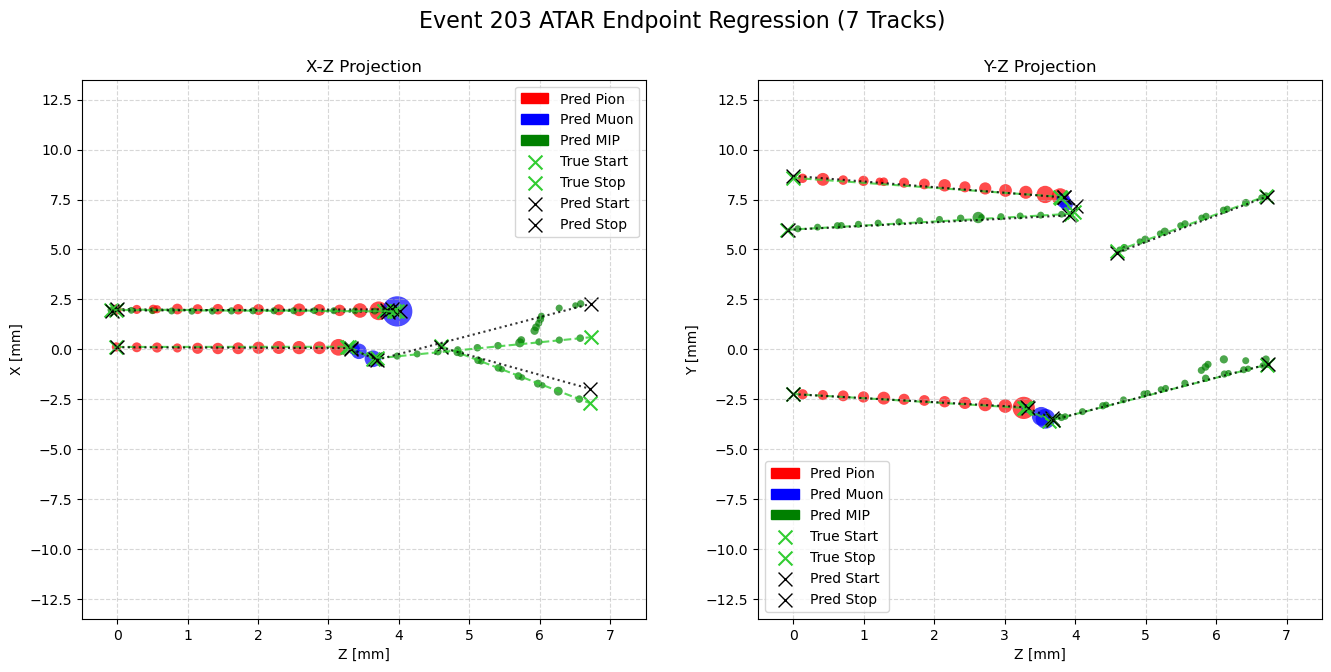

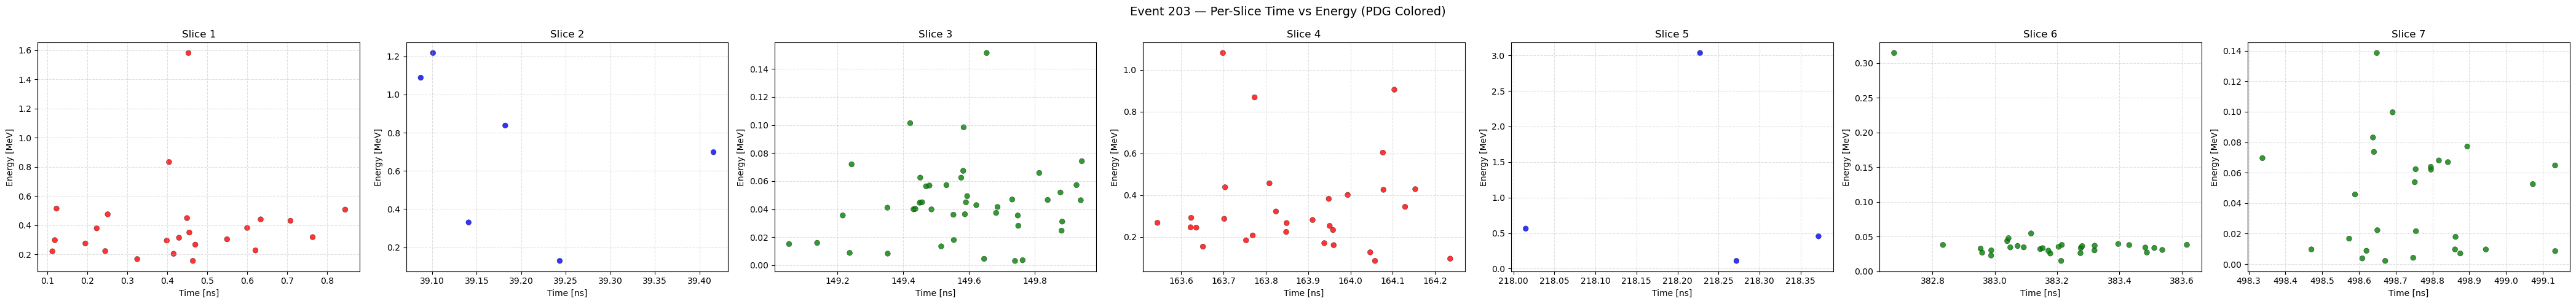

In [ ]:
plot_endpoints_debug(dataset, model, event_idx=203)

Trigger hits  →  pred prob: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
Trigger hits  → mean pred prob: 1.000
Pileup hits   → mean pred prob: 1.000


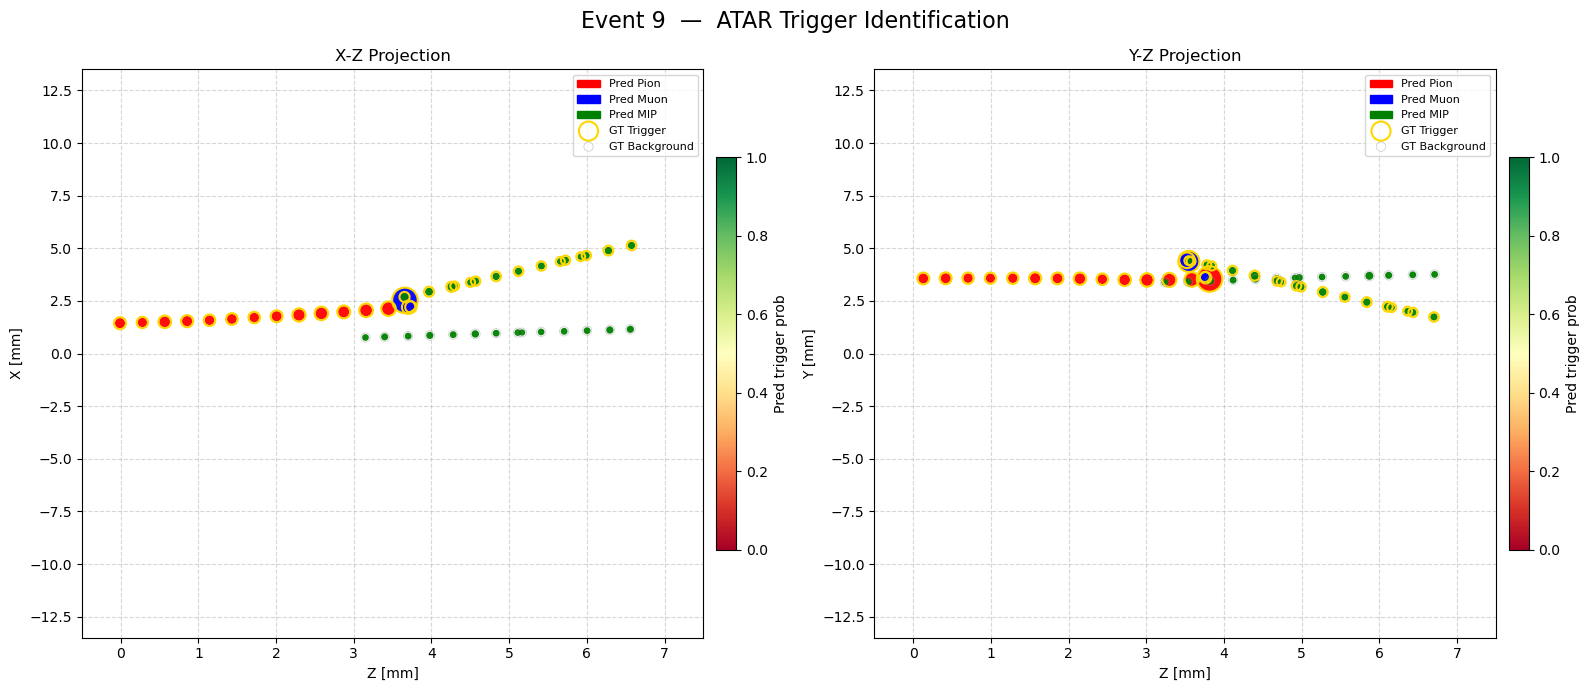

In [ ]:
plot_trigger_debug(dataset, model, event_idx=9)

In [ ]:
def investigate_pdg_at_index(dataset_obj, model_obj, event_idx=0, device='cuda'):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from torch_geometric.data import Batch  # Import Batch to fix the NoneType error
    # 1. Prepare Data as a Batch of 1
    model_obj.eval()
    data = dataset_obj[event_idx]
    batch = Batch.from_data_list([data]).to(device) # This adds the .batch attribute
    
    # 2. Forward Pass
    with torch.no_grad():
        outputs = model_obj(batch.x, batch.batch)
        # Now it's compatible with your standard formatting function
        targets = format_targets_from_batch(batch) 
    # 3. Extract Statistics
    pred_probs = torch.sigmoid(outputs['atar_slice_pdg']).cpu().numpy()
    true_targets = targets['tar_slice_pdg'].cpu().numpy()
    valid_slice_mask = outputs['valid_slice_mask'].cpu().numpy()
    num_slices_max = outputs['num_slices_max']
    
    valid_indices = np.where(valid_slice_mask)[0]
    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(10, 7))
    cmap = plt.get_cmap('tab20')
    
    is_atar = (batch.x[:, 5] > 0.5) | (batch.x[:, 6] > 0.5)
    g_atar_x = batch.x[is_atar, 0].cpu().numpy() * 10
    g_atar_y = batch.x[is_atar, 1].cpu().numpy() * 10
    g_atar_z = batch.x[is_atar, 2].cpu().numpy() * 10
    g_atar_e = batch.x[is_atar, 3].cpu().numpy()
    # 0 = XZ view (col 5), 1 = YZ view (col 6)
    g_atar_view = (batch.x[is_atar, 6] > 0.5).cpu().numpy().astype(int)
    g_atar_slice = batch.x[is_atar, 8].cpu().numpy().astype(int)

    for i, view_name in enumerate(["XZ", "YZ"]):
        ax = axes[i]
        mask_view = (g_atar_view == i)
        ax.scatter(g_atar_z[mask_view], 
                   g_atar_x[mask_view] if i == 0 else g_atar_y[mask_view], 
                   c=g_atar_slice[mask_view], 
                   cmap=cmap, s=g_atar_e[mask_view]*200+20, 
                   alpha=0.8, edgecolors='black', linewidth=0.5)
        
        ax.set_title(f"{view_name} View (Event {event_idx})")
        ax.set_xlim(-0.5, 7.5); ax.set_ylim(-11.5, 11.5)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # 5. Table Output
    print(f"\n--- PDG Target Investigation (Event {event_idx}) ---")
    print(f"{'Slice':<8} | {'Type':<10} | {'True Target':<18} | {'Pred Prob (Pi, Mu, MIP)':<25}")
    print("-" * 75)
    
    class_names = ["Pion", "Muon", "MIP"]
    for local_idx in range(len(valid_indices)):
        t = true_targets[local_idx]
        p = pred_probs[local_idx]
        true_types = [class_names[i] for i, val in enumerate(t) if val > 0.5]
        true_type_str = "+".join(true_types) if true_types else "None"
        
        print(f"{local_idx:<8} | {true_type_str:<10} | {str(t):<18} | ({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")

In [ ]:
wrong_indices = []

model.train()
for event_idx in range(len(dataset)):
    if event_idx > 1000:
        break
    data = dataset[event_idx]
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0})
    
    if 'atar_slice_pdg' not in outputs or outputs['atar_slice_pdg'].shape[0] == 0:
        continue
    
    targets = format_targets_from_batch(batch)
    if 'tar_slice_pdg' not in targets:
        continue

    pred_probs = torch.sigmoid(outputs['atar_slice_pdg'].cpu())  # [N_valid_slices, 3]
    true_targets = targets['tar_slice_pdg'].cpu()                # [N_slices, 3]

    n = min(pred_probs.shape[0], true_targets.shape[0])
    pred_binary = (pred_probs[:n] > 0.5).float()
    true_binary = (true_targets[:n] > 0.5).float()

    # Any slice in this event has at least one bit wrong
    if not torch.all(pred_binary == true_binary):
        wrong_indices.append(event_idx)

print(f"{len(wrong_indices)} / {len(dataset)} events have at least one wrong slice PDG")
print("First 20:", wrong_indices[:20])


40 / 24741 events have at least one wrong slice PDG
First 20: [42, 47, 65, 76, 143, 177, 180, 201, 242, 325, 356, 389, 397, 409, 457, 462, 464, 500, 501, 502]


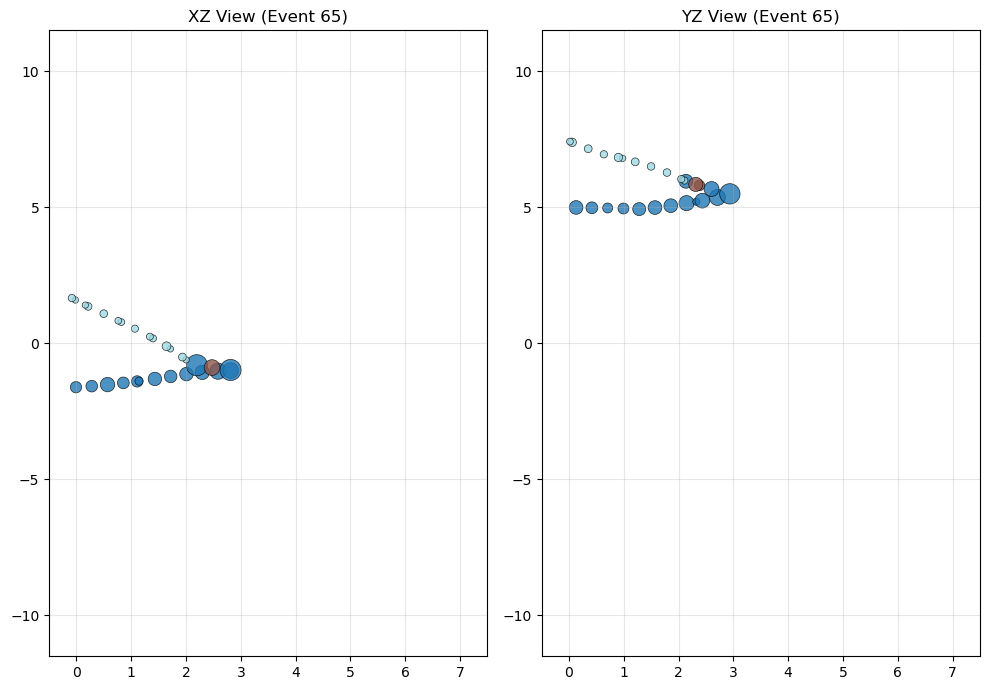


--- PDG Target Investigation (Event 65) ---
Slice    | Type       | True Target        | Pred Prob (Pi, Mu, MIP)  
---------------------------------------------------------------------------
0        | Pion+Muon  | [1. 1. 0.]         | (0.996, 0.355, 0.000)
1        | Muon       | [0. 1. 0.]         | (0.005, 0.696, 0.016)
2        | MIP        | [0. 0. 1.]         | (0.000, 0.000, 1.000)


In [ ]:
investigate_pdg_at_index(dataset, model, event_idx=65)

In [ ]:
def scan_pdg_errors(dataset_obj, model_obj, num_events=5000, device='cuda'):
    import torch
    from torch_geometric.data import Batch
    from tqdm import tqdm
    import numpy as np
    model_obj.train()
    error_indices = []
    
    # Track error counts
    # (True Class -> Pred Class)
    class_names = ["Pion", "Muon", "MIP"]
    confusion_matrix = np.zeros((3, 3), dtype=int)
    
    print(f"Scanning first {num_events} events for PDG classification errors...")
    
    for i in tqdm(range(num_events)):
        data = dataset_obj[i]
        batch = Batch.from_data_list([data]).to(device)
        
        with torch.no_grad():
            outputs = model_obj(batch.x, batch.batch)
            targets = format_targets_from_batch(batch)
            
            # Extract valid slice targets and predictions
            t_pdg = targets['tar_slice_pdg'].cpu().numpy()
            p_logits = outputs['atar_slice_pdg'].cpu()
            p_probs = torch.sigmoid(p_logits).numpy()
            
        # Check every valid slice in this event
        has_error = False
        for local_idx in range(len(t_pdg)):
            true_bits = t_pdg[local_idx]
            pred_bits = p_probs[local_idx]
            
            if np.max(true_bits) < 0.5: continue # Skip slices with no ground truth
            
            t_class = np.argmax(true_bits)
            p_class = np.argmax(pred_bits)
            
            # Simple mismatch check
            if t_class != p_class:
                confusion_matrix[t_class, p_class] += 1
                has_error = True
        
        if has_error:
            error_indices.append(i)
    # Summary
    print("\n--- Diagnostic Results ---")
    print(f"Total Events Scanned: {num_events}")
    print(f"Events with at least 1 PDG error: {len(error_indices)} ({len(error_indices)/num_events*100:.2f}%)")
    
    print("\nConfusion Matrix (True \ Pred):")
    print(f"{'':<10} | {'Pion':<8} | {'Muon':<8} | {'MIP':<8}")
    print("-" * 45)
    for i in range(3):
        print(f"{class_names[i]:<10} | {confusion_matrix[i,0]:<8} | {confusion_matrix[i,1]:<8} | {confusion_matrix[i,2]:<8}")
    # Display some problematic indices for you to visualize
    if error_indices:
        print(f"\nExample Problematic Indices: {error_indices[:15]}...")
    
    return error_indices

In [ ]:
problem_ids = scan_pdg_errors(dataset, model, num_events=5000)

Scanning first 5000 events for PDG classification errors...


100%|██████████| 5000/5000 [03:03<00:00, 27.27it/s]


--- Diagnostic Results ---
Total Events Scanned: 5000
Events with at least 1 PDG error: 29 (0.58%)

Confusion Matrix (True \ Pred):
           | Pion     | Muon     | MIP     
---------------------------------------------
Pion       | 0        | 5        | 1       
Muon       | 4        | 0        | 19      
MIP        | 0        | 0        | 0       

Example Problematic Indices: [122, 346, 491, 941, 1170, 1238, 1262, 1266, 1304, 1484, 1597, 1834, 1974, 2199, 2299]...


In [ ]:
def plot_pion_kinematics_debug(dataset_obj, model_obj, event_idx=0):
    model_obj.train()
    data = dataset_obj[event_idx]
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        # Turn ON Node PDG so we can color the graph
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_pion_kinematics': 0.01, 'w_slice_pdg': 1.0})
    
    # 2. Geometry Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    
    # Scale ATAR energy for point size. Base size is 20, scaling up linearly with E
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    pred_slice_pdg = torch.sigmoid(outputs['atar_slice_pdg'])
    print(pred_slice_pdg)
    
    # 3. True Kinematics
    true_x = row.get('truth_pion_stop_x', 0.0)
    true_y = row.get('truth_pion_stop_y', 0.0)
    true_z = row.get('truth_pion_stop_z', 0.0)
    
    # 4. Predicted Kinematics (Find highest-probability Pion slice)
    if 'atar_slice_pdg' in outputs and len(outputs['atar_slice_pdg']) > 0:
        pion_probs = torch.sigmoid(outputs['atar_slice_pdg'][:, 0])
        best_pion_idx = torch.argmax(pion_probs).item()r_pion_stop_y'][best_pion_idx].item() * 10.0
        pred_z = outputs['atar_pion_stop_z'][best_pion_idx].item() * 10.0
    else:
        print("Model failed to output any slices.")
        return
        
    # 5. Node Splitting Prediction (For Graph Coloring)
    # Target space is [Pion, Muon, MIP]. Argmax returns 0, 1, or 2.
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    
    color_map = {0: 'red', 1: 'blue', 2: 'green'} # Pion=Red, Muon=Blue, MIP=Green
    hit_colors = [color_map[c] for c in pred_node_classes]
    
    # Setup Legend Handles
    handles = [
        mpatches.Patch(color='red', label='Pred Pion'),
        mpatches.Patch(color='blue', label='Pred Muon'),
        mpatches.Patch(color='green', label='Pred MIP')
    ]
    
    # 6. Plot XZ and YZ views
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} Pion Stop Regression', fontsize=16)
    
    # --- XZ Projection ---
    mask_xz = (atar_view == 0)
    colors_xz = [hit_colors[i] for i, m in enumerate(mask_xz) if m]
    sizes_xz = atar_s[mask_xz]
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], c=colors_xz, s=sizes_xz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    ax1.scatter([true_z], [true_x], c='limegreen', marker='x', s=100, label='True Stop')
    ax1.scatter([pred_z], [pred_x], c='black', marker='x', s=100, linewidth=1, label='Pred Stop')
    
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(handles=handles + [ax1.get_legend_handles_labels()[0][1], ax1.get_legend_handles_labels()[0][2]])
    ax1.set_title("X-Z Projection")
    
    # --- YZ Projection ---
    mask_yz = (atar_view == 1)
    colors_yz = [hit_colors[i] for i, m in enumerate(mask_yz) if m]
    sizes_yz = atar_s[mask_yz]
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], c=colors_yz, s=sizes_yz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    ax2.scatter([true_z], [true_y], c='limegreen', marker='x', s=100, label='True Stop')
    ax2.scatter([pred_z], [pred_y], c='black', marker='x', s=100, linewidth=1, label='Pred Stop')
    
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(handles=handles + [ax2.get_legend_handles_labels()[0][1], ax2.get_legend_handles_labels()[0][2]])
    ax2.set_title("Y-Z Projection")
    plt.tight_layout()
    plt.show()
    print([pred_x, pred_y, pred_z])

In [ ]:
plot_pion_kinematics_debug(dataset, model, event_idx=2)

tensor([[9.9999e-01, 1.3303e-04, 1.2476e-04],
        [2.2746e-04, 1.0000e+00, 9.4182e-06]], device='cuda:0')


KeyError: 'atar_pion_stop_x'

In [ ]:
def freeze_for_endpoint_finetuning(model):
    print("Freezing model backbone. Isolating endpoint heads...")
    
    # 1. Freeze absolutely everything in the model
    for param in model.parameters():
        param.requires_grad = False
        
    # 2. Unfreeze ONLY the endpoint heads
    for param in model.atar_endpoint_x.parameters():
        param.requires_grad = True
    for param in model.atar_endpoint_y.parameters():
        param.requires_grad = True
    for param in model.atar_endpoint_z.parameters():
        param.requires_grad = True

    # OPTIONAL: Unfreeze the pooling layers if they have trainable weights 
    # (like AttentionalAggregation) so they can learn to focus on the endpoints
    for param in model.pool_x_gen.parameters():
        param.requires_grad = True
    for param in model.pool_y_gen.parameters():
        param.requires_grad = True

    # 3. Verify the active parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f"Trainable Parameters: {trainable_params}")
    print(f"Frozen Parameters: {frozen_params}")
    
    return model

In [ ]:
# 1. Apply the freeze
model = freeze_for_endpoint_finetuning(model)

# 2. Create a fresh optimizer containing ONLY the unfrozen parameters!
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-5
)

Freezing model backbone. Isolating endpoint heads...
Trainable Parameters: 140820
Frozen Parameters: 1447918


In [ ]:
#torch.save(model.state_dict(), '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_basic_4_12_2026.pth')


In [6]:
#model = PURITYHybridModel()
model.load_state_dict(torch.load('/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_before_calo_match_4_11_2026.pth'), strict=False)
model.to(device)

PURITYHybridModel(
  (atar_feature_proj): Sequential(
    (0): Linear(in_features=3, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_view_embedding): Embedding(2, 150)
  (lyso_encoder): Sequential(
    (0): Linear(in_features=5, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_blocks): ModuleList(
    (0-2): 3 x JointAttentionBlock(
      (ln1): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (conv): TransformerConv(150, 30, heads=5)
      (ln2): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=150, out_features=600, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.05, inplace=False)
       

In [ ]:
#model = PURITYHybridModel()
state_dict = torch.load('/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_before_calo_match_4_9_2026.pth')

# Drop keys whose shapes changed (event builder modules being retrained from scratch)
#keys_to_drop = [k for k in state_dict if k.startswith(('lyso_event_mlp', 'lyso_angular_proj','lyso_beta_head', 'lyso_cluster_coord_head', 'lyso_fraction_head'))]
keys_to_drop = [k for k in state_dict if k.startswith(('lyso_angular_proj',
    'event_transformer',
    'event_classifier',
    'lyso_pool_event_proj',))]
for k in keys_to_drop: state_dict.pop(k)

model.load_state_dict(state_dict, strict=False)
model.to(device)


PURITYHybridModel(
  (atar_feature_proj): Sequential(
    (0): Linear(in_features=3, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_view_embedding): Embedding(2, 150)
  (lyso_encoder): Sequential(
    (0): Linear(in_features=5, out_features=150, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
  )
  (atar_blocks): ModuleList(
    (0-2): 3 x JointAttentionBlock(
      (ln1): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (conv): TransformerConv(150, 30, heads=5)
      (ln2): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=150, out_features=600, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.05, inplace=False)
       

In [ ]:
TRAINABLE_PREFIXES = (
    # --- Object condensation heads (LYSO clustering in latent space) ---
    'lyso_beta_head',
    'lyso_cluster_coord_head',
    'lyso_fraction_head',

    # --- Event builder: LYSO token construction ---
    'lyso_pool_event_proj',
    'lyso_time_proj',
    'lyso_event_mlp',
    #'pool_x_event',          # stereo pools dedicated to event token construction
    #'pool_y_event',

    # --- Event builder: ATAR token enrichment & Phase-9 ATAR-only path ---
    #'atar_event_mlp',
    #'atar_trigger_proj',
    #'atar_token_reproject',
    #'atar_event_self_attn',
    #'atar_event_self_attn_norm',
    #'atar_trigger_classifier',

    # --- Unified event transformer + classifier ---
    'event_transformer',
    'event_classifier',
    'modality_embedding',
    'slice_position_embedding',
)


In [ ]:
def freeze_except(model, trainable_prefixes):
    n_train, n_freeze = 0, 0
    for name, p in model.named_parameters():
        if name.startswith(trainable_prefixes):
            p.requires_grad = True
            n_train += p.numel()
        else:
            p.requires_grad = False
            n_freeze += p.numel()
    print(f"Trainable: {n_train:,} params   Frozen: {n_freeze:,} params")

    # Sanity check: list which top-level modules have any trainable params
    trainable_modules = sorted({
        name.split('.')[0]
        for name, p in model.named_parameters() if p.requires_grad
    })
    print("Trainable top-level modules:", trainable_modules)

freeze_except(model, TRAINABLE_PREFIXES)


Trainable: 1,316,454 params   Frozen: 6,205,277 params
Trainable top-level modules: ['event_classifier', 'event_transformer', 'lyso_beta_head', 'lyso_cluster_coord_head', 'lyso_event_mlp', 'lyso_fraction_head', 'lyso_pool_event_proj', 'lyso_time_proj', 'modality_embedding', 'slice_position_embedding']


In [ ]:
for p in model.parameters():
    p.requires_grad = True